# Config-B GRU-VAE — full pipeline from raw embeddings to forecasting

**End to end, in human-readable blocks.** This notebook:
1. **Generates the appearance-lag from source** — USFM embeddings → GA maturation-clock → per-image lag → merged-timeline lag channels.
2. Defines & trains the **PyTorch GRU-VAE**, validates it.
3. Encodes each fetus as a **path through the 8-D latent** and runs forecasting: future-position (Part A), outcome dynamics-lift (Part B), lag/no-lag contrast, birth-percentile regression.

**Three knobs (§1a):** `PLANES` picks which anatomical planes to use; `PER_PLANE` switches between one pooled lag channel (canonical) and one channel per plane; `USE_LAG` switches whether lag feeds the primary model. Labels (SGA / birth pct) are evaluation-only — never training inputs. No USB / raw images needed.

## 0.  Setup

In [72]:
import numpy as np, pandas as pd, torch, torch.nn as nn
from sklearn.model_selection import GroupKFold, KFold
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import roc_auc_score, r2_score
from scipy.stats import pearsonr

import matplotlib.pyplot as plt, plotly.graph_objects as go
from IPython.display import HTML, display
torch.manual_seed(0); np.random.seed(0); torch.set_num_threads(8)

In [73]:
IMG_DIR    = "/Users/tiago/PythonProject/fgr-geometry/results/img_align"
CITUS_XLSX = "/Users/tiago/Documents/CiTUS/Dataset/Impact_longitudinal_161025_all_merged.xlsx"

HIDDEN_SIZE, LATENT_DIM = 32, 8              # GRU hidden units, latent dimensions
BETA, EPOCHS, LEARNING_RATE = 0.1, 250, 1e-3  # KL weight, training epochs, Adam lr
GA_MIN, GA_MAX, RIDGE_ALPHA = 6.0, 42.0, 50.0  # clock GA window + Ridge regularization

## 1.  Generate the appearance-lag from source

appearance-lag = (GA the image *looks* like, from the clock) − (GA by dates). Built in small steps below.

### 1a.  ▶ KNOBS — planes, pooled-vs-per-plane, and lag on/off

- `PLANES` — which anatomical planes feed the clock.
- `PER_PLANE` — one pooled lag channel (`False`, canonical config-B) or a separate clock + channel per plane (`True`).
- `USE_LAG` — `True`: lag channels feed the **primary** model (the one shown in §5 axis-ID, §7 Part A, §10 3-D); `False`: the primary model is biometry + GA only.

Whatever `USE_LAG` is, the **other** setting is trained as the contrast (§11) and both are compared in §11b / §12 — so the with-vs-without-lag comparison is always shown, correctly labelled. Everything recomputes from these three knobs.

In [74]:
PLANES = ["abdominal", "cerebral", "femur"]   # which planes to include
PER_PLANE = False                             # False = one pooled channel; True = one channel per plane
USE_LAG   = True                              # True = lag channels feed the primary model; False = biometry + GA only

if PER_PLANE:
    lag_channels = {plane: [plane] for plane in PLANES}   # each plane its own clock + channel
else:
    lag_channels = {"pooled": PLANES}                     # all selected planes -> one clock + channel
channel_names = list(lag_channels)
print("lag channels:", channel_names, "| USE_LAG:", USE_LAG)

lag channels: ['pooled'] | USE_LAG: True


**1b.** Dating anchor per fetus — eco-based `FUReco`, else `LMP`.

In [75]:
citus = pd.read_excel(CITUS_XLSX, sheet_name="IMPACT_Final_All_V18")[["Cod","LMP","FUReco"]].copy()
citus["LMP"]    = pd.to_datetime(citus.LMP, errors="coerce")
citus["FUReco"] = pd.to_datetime(citus.FUReco, errors="coerce")
dating_anchor = citus.assign(a=citus.FUReco.fillna(citus.LMP)).set_index("Cod").a.to_dict()
print("dating anchors:", len(dating_anchor))

dating anchors: 1169


**1c.** Load USFM block-6 embeddings + each image's fetus id, study date, and filename.

In [76]:
emb_npz = np.load(f"{IMG_DIR}/emb_usfm_multilayer.npz", allow_pickle=True)
image_fetus_id = pd.to_numeric(pd.Series(emb_npz["fetus_id"]),  errors="coerce").astype("Int64")
study_date_raw = pd.to_numeric(pd.Series(emb_npz["study_date"]), errors="coerce")
study_date  = pd.to_datetime(study_date_raw.astype("Int64").astype("string"), format="%Y%m%d", errors="coerce")
image_filename = pd.Series(emb_npz["new_filename"]).astype(str)
print("images:", len(image_fetus_id), "| embedding dim:", emb_npz["emb_l5"].shape[1])

images: 61804 | embedding dim: 768


**1d.** Attach each image's plane label (from `image_clusters.csv`).

In [77]:
filename_to_plane = pd.read_csv(f"{IMG_DIR}/image_clusters.csv", low_memory=False).set_index("new_filename")["plane_prop"]
image_plane = image_filename.map(filename_to_plane).values
print("plane labels:", pd.Series(image_plane).value_counts().to_dict())

plane labels: {'abdominal': 29293, 'cerebral': 27233, 'femur': 5278}


**1e.** True GA per image = (study date − anchor)/7. Keep 6–42 wk (out-of-range = wrong-pregnancy scans) and selected planes.

In [78]:
image_anchor = pd.to_datetime(pd.Series(image_fetus_id.map(dating_anchor)), errors="coerce")
image_true_ga = ((study_date - image_anchor.values).dt.days / 7.0).values
valid_image = (pd.Series(image_true_ga).between(GA_MIN, GA_MAX).values
               & image_fetus_id.notna().values
               & pd.Series(image_plane).isin(PLANES).values)
print("valid images (selected planes):", int(valid_image.sum()))

valid images (selected planes): 55051


**1f.** One GA maturation-clock per lag channel — Ridge(α=50), 5-fold grouped by fetus. Per-image lag = predicted − true GA.

In [79]:
embeddings = emb_npz["emb_l5"].astype(np.float32)
per_image_lag_frames = []

for channel_name, planes_in_channel in lag_channels.items():
    keep = valid_image & np.isin(image_plane, planes_in_channel)
    emb_k, true_ga_k = embeddings[keep], image_true_ga[keep]
    fetus_k = image_fetus_id.values[keep].astype(int)

    predicted_ga = np.zeros(len(true_ga_k))
    for train, test in GroupKFold(5).split(emb_k, true_ga_k, fetus_k):
        predicted_ga[test] = Ridge(alpha=RIDGE_ALPHA).fit(emb_k[train], true_ga_k[train]).predict(emb_k[test])
    print(f"  {channel_name:10s}: n={len(true_ga_k)}  clock r={pearsonr(true_ga_k, predicted_ga)[0]:.3f}")

    per_image_lag_frames.append(pd.DataFrame({"channel": channel_name, "fetus": fetus_k,
        "ga_week": np.round(true_ga_k).astype(int), "lag": predicted_ga - true_ga_k}))

  pooled    : n=55051  clock r=0.848


**1g.** Mean lag per (fetus, GA-week) within each channel.

In [80]:
per_image_lag = pd.concat(per_image_lag_frames, ignore_index=True)
lag_bin_mean = {name: per_image_lag[per_image_lag.channel == name].groupby(["fetus","ga_week"]).lag.mean()
                for name in channel_names}
print("per-image lags:", len(per_image_lag), "| channels:", channel_names)

per-image lags: 55051 | channels: ['pooled']


**1h.** Map each channel's binned lag onto the 12-slot merged timeline (±1 wk match). Shape = (fetuses, slots, channels).

In [81]:
merged = np.load(f"{IMG_DIR}/_merged_seq.npz", allow_pickle=True)
merged_seq, merged_len, fetus_ids = merged["X"], merged["L"], merged["fids"]
N_BIOM, N_IMG_EMB = int(merged["F"]), int(merged["K"])
n_fetus, n_slots, n_channels = merged_seq.shape[0], merged_seq.shape[1], len(channel_names)

lag_grid      = np.zeros((n_fetus, n_slots, n_channels), np.float32)
lag_grid_mask = np.zeros((n_fetus, n_slots, n_channels), np.float32)

In [82]:
def lookup_lag(channel_name, fetus, slot_ga):
    for candidate in (slot_ga, slot_ga - 1, slot_ga + 1):
        if (fetus, candidate) in lag_bin_mean[channel_name].index:
            return lag_bin_mean[channel_name].loc[(fetus, candidate)]
    return None

In [83]:
for i, fetus in enumerate(fetus_ids):
    for slot in range(int(merged_len[i])):
        slot_ga = int(round(merged_seq[i, slot, -1] * 36.0 + 6.0))

        for ci, channel_name in enumerate(channel_names):
            value = lookup_lag(channel_name, int(fetus), slot_ga)
            if value is not None:
                lag_grid[i, slot, ci] = value; lag_grid_mask[i, slot, ci] = 1.0

print("lag grid:", lag_grid.shape,
      "| slots/channel:", {n: int(lag_grid_mask[:,:,c].sum()) for c, n in enumerate(channel_names)})

lag grid: (908, 12, 1) | slots/channel: {'pooled': 3123}


## 2.  Assemble the GRU-VAE input

Per slot: `[5 biometry-z | 5 biometry-mask | (lag, lag-mask) × channels | GA_norm]`. Corrupt biometry (`z < −10`, an impossible missing sentinel) is zeroed with its mask bit cleared.

In [84]:
merged_clean = merged_seq.astype(np.float32).copy()
corrupt = merged_clean[:, :, :N_BIOM] < -10
for j in range(N_BIOM):
    corrupt_col = corrupt[:, :, j]
    merged_clean[:, :, j][corrupt_col] = 0.0
    merged_clean[:, :, N_BIOM + j][corrupt_col] = 0.0
print("corrupt biometry cells masked:", int(corrupt.sum()))

corrupt biometry cells masked: 25


In [85]:
biom_block = merged_clean[:, :, :2 * N_BIOM]
ga_channel = merged_clean[:, :, -1:]
ga_norm    = merged_clean[:, :, -1]
lag_block  = np.concatenate([np.concatenate([lag_grid[:, :, c:c+1], lag_grid_mask[:, :, c:c+1]], -1)
                             for c in range(n_channels)], -1)

X_with_lag = np.concatenate([biom_block, lag_block, ga_channel], -1).astype(np.float32)
X_no_lag   = np.concatenate([biom_block, ga_channel], -1).astype(np.float32)
input_dim  = X_with_lag.shape[2]
seq_len    = np.clip(merged_len, 1, n_slots)
print(f"with-lag input {X_with_lag.shape} (dim {input_dim}) | no-lag {X_no_lag.shape}")

with-lag input (908, 12, 13) (dim 13) | no-lag (908, 12, 11)


In [86]:
# USE_LAG picks the primary model input; the other setting becomes the contrast (§11, §12).
if USE_LAG:
    X_primary, primary_name = X_with_lag, "with-lag"
    X_contrast, contrast_name = X_no_lag, "no-lag"
else:
    X_primary, primary_name = X_no_lag, "no-lag"
    X_contrast, contrast_name = X_with_lag, "with-lag"

primary_dim, contrast_dim = X_primary.shape[2], X_contrast.shape[2]
print(f"primary = {primary_name} (dim {primary_dim}) | contrast = {contrast_name} (dim {contrast_dim})")

primary = with-lag (dim 13) | contrast = no-lag (dim 11)


In [87]:
label_npz = np.load(f"{IMG_DIR}/_merged_labels.npz", allow_pickle=True)
birth_pct = pd.Series(label_npz["birth"], index=label_npz["fids"]).reindex(pd.Index(fetus_ids)).values.astype(float)

fetus_lag_by_channel = np.full((n_fetus, n_channels), np.nan)
for i in range(n_fetus):
    for c in range(n_channels):
        values = lag_grid[i, :seq_len[i], c][lag_grid_mask[i, :seq_len[i], c] > 0]
        if len(values):
            fetus_lag_by_channel[i, c] = values.mean()

fetus_mean_lag = np.full(n_fetus, np.nan)                     # overall lag per fetus (for 3D / axis ID)
has_any_lag = np.isfinite(fetus_lag_by_channel).any(1)
fetus_mean_lag[has_any_lag] = np.nanmean(fetus_lag_by_channel[has_any_lag], 1)
print("fetuses with birth pct:", int(np.isfinite(birth_pct).sum()),
      "| with any lag:", int(np.isfinite(fetus_mean_lag).sum()))

fetuses with birth pct: 906 | with any lag: 886


## 3.  The PyTorch GRU-VAE

A GRU encodes the visit sequence; the final hidden state gives the endpoint code (`encode`), the per-slot states give the trajectory (`encode_sequence`). A symmetric MLP decodes back to the visit vector.

In [ ]:
class SeqVAE(nn.Module):
    def __init__(self, input_dim, hidden=32, latent=8):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden, batch_first=True)
        self.to_mean = nn.Linear(hidden, latent)
        self.to_logvar = nn.Linear(hidden, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(), nn.Linear(hidden, input_dim))

    def encode(self, x):                       # endpoint: final hidden state
        _, hidden_state = self.gru(x)
        return self.to_mean(hidden_state[-1]), self.to_logvar(hidden_state[-1])

    def encode_sequence(self, x):              # trajectory: latent at every slot
        slot_states, _ = self.gru(x)
        return self.to_mean(slot_states)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = mean + torch.randn_like(logvar) * (0.5 * logvar).exp()
        return self.decoder(z), mean, logvar

In [ ]:
def elbo_loss(recon, target, mean, logvar, beta=BETA):
    reconstruction = ((recon - target) ** 2).mean()
    kl = (-0.5 * (1 + logvar - mean ** 2 - logvar.exp()).sum(1)).mean()
    return reconstruction + beta * kl, reconstruction, kl

In [ ]:
def visit_mean_target(sequences, lengths):     # unsupervised target = each fetus's visit-mean
    return torch.stack([sequences[i, :lengths[i]].mean(0) for i in range(len(sequences))])

## 4.  Train + validate

`train_gruvae` fits on given fetuses (target = each fetus's visit-mean). Validation = GroupKFold(5) by fetus → out-of-fold endpoint latents + reconstruction MSE.

In [ ]:
def train_gruvae(X, lengths, in_dim, seed=0, verbose=False):
    torch.manual_seed(seed)
    model = SeqVAE(in_dim, HIDDEN_SIZE, LATENT_DIM)
    optimizer = torch.optim.Adam(model.parameters(), LEARNING_RATE)
    sequences = torch.tensor(X); target = visit_mean_target(sequences, lengths)

    for epoch in range(EPOCHS):
        model.train(); optimizer.zero_grad()
        recon, mean, logvar = model(sequences)
        loss, recon_err, _ = elbo_loss(recon, target, mean, logvar)
        loss.backward(); optimizer.step()

        if verbose and (epoch + 1) % 50 == 0:
            print(f"    epoch {epoch+1}: loss {loss.item():.4f}  recon {recon_err.item():.4f}")
    return model

In [ ]:
latent_oof = np.zeros((n_fetus, LATENT_DIM))
recon_mse = []

for k, (train, test) in enumerate(GroupKFold(5).split(X_primary, groups=fetus_ids)):
    model = train_gruvae(X_primary[train], seq_len[train], primary_dim, seed=0, verbose=(k == 0))
    model.eval()

    with torch.no_grad():
        latent_oof[test] = model.encode(torch.tensor(X_primary[test]))[0].numpy()
        recon = model(torch.tensor(X_primary[test]))[0]
        target = visit_mean_target(torch.tensor(X_primary[test]), seq_len[test])
        recon_mse.append(float(((recon - target) ** 2).mean()))

print(f"[{primary_name}] OOF reconstruction MSE = {np.mean(recon_mse):.4f}")

    epoch 50: loss 0.4168  recon 0.4055
    epoch 100: loss 0.3604  recon 0.3561
    epoch 150: loss 0.3373  recon 0.3232
    epoch 200: loss 0.3292  recon 0.3018
    epoch 250: loss 0.3229  recon 0.2903
[with-lag] OOF reconstruction MSE = 0.2980


**4b.** Trajectory model — one fit on all fetuses → per-slot latent path + endpoint for every fetus.

In [ ]:
full_model = train_gruvae(X_primary, seq_len, primary_dim, seed=0)
full_model.eval()
with torch.no_grad():
    latent_traj = full_model.encode_sequence(torch.tensor(X_primary)).numpy()
latent_end = np.array([latent_traj[i, seq_len[i] - 1] for i in range(n_fetus)])

In [ ]:
def effective_dim(matrix):
    centered = matrix - matrix.mean(0)
    variances = np.linalg.svd(centered, compute_uv=False) ** 2
    return float((variances.sum() ** 2) / (variances ** 2).sum())

print("trajectory:", latent_traj.shape, "| endpoint effective dim:", round(effective_dim(latent_end), 2))

trajectory: (908, 12, 8) | endpoint effective dim: 1.37


## 5.  Identify the lag & size axes (data-driven)

A VAE numbers its slots arbitrarily each fit, so we find which dimension carries each channel's lag (and which carries size) by correlation — robust to renumbering across retrains. (If `USE_LAG=False` the primary latent has no lag input, so the "lag axis" is just its best-correlated dimension — weak by construction; §11 quantifies that.)

In [ ]:
has_lag_and_birth = np.isfinite(fetus_mean_lag) & np.isfinite(birth_pct)
channel_lag_axis = {}

for c, channel_name in enumerate(channel_names):
    has_channel = np.isfinite(fetus_lag_by_channel[:, c])
    correlations = [abs(pearsonr(latent_end[has_channel, d], fetus_lag_by_channel[has_channel, c])[0])
                    for d in range(LATENT_DIM)]
    axis = int(np.argmax(correlations))
    channel_lag_axis[channel_name] = axis
    print(f"  {channel_name:10s} lag axis = z{axis}  |r| = {correlations[axis]:.3f}")

  pooled     lag axis = z0  |r| = 0.807


In [ ]:
lag_axis = channel_lag_axis[channel_names[0]]          # representative channel for the 3-D view
size_correlations = [abs(pearsonr(latent_end[has_lag_and_birth, d], birth_pct[has_lag_and_birth])[0])
                     for d in range(LATENT_DIM)]
size_axis = int(np.argmax(size_correlations))
print(f"size axis = z{size_axis}  r with birth pct = {pearsonr(latent_end[has_lag_and_birth, size_axis], birth_pct[has_lag_and_birth])[0]:+.3f}")

size axis = z1  r with birth pct = +0.403


## 6.  Trajectory features (symmetric across all dims)

For every latent dimension, using only slots at/before a cutoff GA: velocity (slope vs GA), net change, range. Plus the current 8-D position at the cutoff. Same features are used for every dimension — no asymmetry between lag and size.

In [ ]:
def slot_ga_weeks(i):
    return ga_norm[i, :seq_len[i]] * 36 + 6

def trajectory_features(traj, i, cutoff):
    weeks = slot_ga_weeks(i)
    keep = weeks <= cutoff
    if keep.sum() < 2:
        return None

    path, weeks_kept = traj[i, :seq_len[i], :][keep], weeks[keep]
    feats = []
    for d in range(LATENT_DIM):
        series = path[:, d]
        feats += [np.polyfit(weeks_kept, series, 1)[0], series[-1] - series[0], series.max() - series.min()]
    return np.array(feats), path[-1]

## 7.  Part A — forecast the future (term) 8-D position

For fetuses with ≥2 slots at/before the cutoff and ≥1 after, predict each term latent dim (5-fold grouped Ridge). Mean R² across dims, from current position vs trajectory features.

In [ ]:
def collect_partA(traj, cutoff):
    term = np.array([traj[i, seq_len[i] - 1] for i in range(n_fetus)])
    feat_list, current_list, target_list, group_list = [], [], [], []

    for i in range(n_fetus):
        weeks = slot_ga_weeks(i)
        has_before = (weeks <= cutoff).sum() >= 2
        has_after  = (weeks > cutoff).sum() >= 1
        if not (has_before and has_after):
            continue

        result = trajectory_features(traj, i, cutoff)
        if result is None:
            continue
        feat_list.append(result[0]); current_list.append(result[1])
        target_list.append(term[i]); group_list.append(fetus_ids[i])

    return map(np.array, (feat_list, current_list, target_list, group_list))

In [ ]:
def fit_partA(features, current, target, groups):
    r2_current, r2_trajectory = [], []

    for d in range(LATENT_DIM):
        pred_current = np.zeros(len(target)); pred_traj = np.zeros(len(target))
        for train, test in GroupKFold(5).split(features, groups=groups):
            pred_current[test] = Ridge(1.0).fit(current[train], target[train, d]).predict(current[test])
            pred_traj[test]    = Ridge(1.0).fit(features[train], target[train, d]).predict(features[test])
        r2_current.append(r2_score(target[:, d], pred_current))
        r2_trajectory.append(r2_score(target[:, d], pred_traj))

    return dict(n=len(target), r2_current=float(np.mean(r2_current)), r2_trajectory=float(np.mean(r2_trajectory)))

In [ ]:
partA = {}
for cutoff in [24, 28, 32, 36]:
    features, current, target, groups = collect_partA(latent_traj, cutoff)
    partA[cutoff] = fit_partA(features, current, target, groups)

print("Future TERM 8-D position (mean OOF R²):")
for cutoff in [24, 28, 32, 36]:
    r = partA[cutoff]
    print(f"  <={cutoff}wk (n={r['n']}): current-pos={r['r2_current']:.3f}  trajectory={r['r2_trajectory']:.3f}")

Future TERM 8-D position (mean OOF R²):
  <=24wk (n=386): current-pos=0.606  trajectory=0.522
  <=28wk (n=591): current-pos=0.676  trajectory=0.582
  <=32wk (n=683): current-pos=0.728  trajectory=0.632
  <=36wk (n=184): current-pos=0.829  trajectory=0.774


## 8.  Part B — do latent DYNAMICS add outcome discrimination?

Baseline = current 8-D position. Test = current 8-D + per-dim dynamics (same features, all dims — symmetric). 5-fold grouped AUC + 2000× bootstrap on ΔAUC. Outcomes are evaluation-only.

In [ ]:
outcome_xls = pd.read_excel(CITUS_XLSX, sheet_name="IMPACT_Final_All_V18")
outcome_xls["Cod"] = pd.to_numeric(outcome_xls["Cod"], errors="coerce")
outcome_xls = outcome_xls.dropna(subset=["Cod"]).drop_duplicates("Cod").set_index("Cod")

def binary_outcome(column):
    mapped = outcome_xls[column].reindex(pd.Index(fetus_ids)).astype(str).str.strip().str.lower()
    return mapped.map({"yes": 1, "no": 0, "si": 1, "1": 1, "0": 0}).astype(float).values

In [ ]:
pe_columns = np.column_stack([binary_outcome(c) for c in ["PE_SGA","PEwithSGA","PEwithoutSGA"] if c in outcome_xls.columns])
outcomes = {
    "SGA confirmed": binary_outcome("SGA_prenCONFIRMED"),
    "SGA <p10":      binary_outcome("SGA_birth (<p10)"),
    "severe SGA":    binary_outcome("severeSGA (<p3)"),
    "PE (any)":      np.where(np.all(np.isnan(pe_columns), 1), np.nan, np.nanmax(pe_columns, 1)),
    "LGA (>p90)":    np.where(np.isfinite(birth_pct), (birth_pct > 90).astype(float), np.nan)}
print("outcome positives:", {k: int(np.nansum(v)) for k, v in outcomes.items()})

outcome positives: {'SGA confirmed': 60, 'SGA <p10': 156, 'severe SGA': 53, 'PE (any)': 63, 'LGA (>p90)': 73}


In [ ]:
def collect_current_and_trajectory(traj, cutoff):
    current_list, feature_list, index_list = [], [], []

    for i in range(n_fetus):
        result = trajectory_features(traj, i, cutoff)
        if result is None:
            continue
        feature_list.append(result[0]); current_list.append(result[1]); index_list.append(i)

    return np.array(current_list), np.array(feature_list), np.array(index_list)

In [ ]:
def grouped_oof_proba(features_base, features_full, y, groups):
    proba_base = np.zeros(len(y)); proba_full = np.zeros(len(y))
    for train, test in GroupKFold(5).split(features_base, y, groups):
        proba_base[test] = LogisticRegression(max_iter=1000).fit(features_base[train], y[train]).predict_proba(features_base[test])[:, 1]
        proba_full[test] = LogisticRegression(max_iter=1000).fit(features_full[train], y[train]).predict_proba(features_full[test])[:, 1]
    return proba_base, proba_full

In [ ]:
def bootstrap_auc_delta(proba_base, proba_full, y, n_boot):
    rng = np.random.RandomState(0); deltas = []

    for _ in range(n_boot):
        idx = rng.randint(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2:
            continue
        deltas.append(roc_auc_score(y[idx], proba_full[idx]) - roc_auc_score(y[idx], proba_base[idx]))
    deltas = np.array(deltas)

    return dict(base=float(roc_auc_score(y, proba_base)), full=float(roc_auc_score(y, proba_full)),
                delta=float(deltas.mean()), lo=float(np.percentile(deltas, 2.5)),
                hi=float(np.percentile(deltas, 97.5)), P=float(np.mean(deltas > 0)))

In [ ]:
def auc_delta(traj, y, cutoff, n_boot=2000):
    current, features, index = collect_current_and_trajectory(traj, cutoff)
    labels = y[index]; groups = fetus_ids[index]; valid = np.isfinite(labels)
    current, features, labels, groups = current[valid], features[valid], labels[valid].astype(int), groups[valid]

    if len(labels) < 40 or labels.sum() < 8 or (len(labels) - labels.sum()) < 8:
        return None
    proba_base, proba_full = grouped_oof_proba(current, np.column_stack([current, features]), labels, groups)
    return bootstrap_auc_delta(proba_base, proba_full, labels, n_boot)

In [ ]:
CUTOFFS = [24, 28, 32, 36, 42]
partB = {name: [auc_delta(latent_traj, y, c) for c in CUTOFFS] for name, y in outcomes.items()}

for name in outcomes:
    row = " ".join(f"{(r['delta'] if r else np.nan):+.3f}{'*' if (r and r['P']>=0.975) else ' '}" for r in partB[name])
    print(f"  {name:14s} dAUC: {row}")
print("\ncutoffs [<=24 <=28 <=32 <=36 term];  * = bootstrap P>0.975")

  SGA confirmed  dAUC: +0.003  +0.044* +0.033* +0.047* +0.041*
  SGA <p10       dAUC: +0.012  +0.029* +0.025* +0.027* +0.019*
  severe SGA     dAUC: +0.018  +0.008  +0.031* +0.038* +0.024*
  PE (any)       dAUC: +0.028  +0.022  +0.058* -0.001  -0.000 
  LGA (>p90)     dAUC: -0.013  +0.002  +0.008  -0.007  -0.004 

cutoffs [<=24 <=28 <=32 <=36 term];  * = bootstrap P>0.975


## 9.  Figure — position forecasting (A) + dynamics lift (B)

This figure shows the **primary** model only (with-lag when `USE_LAG=True`, no-lag when `USE_LAG=False`). For the **both-models** version — with-lag and no-lag side by side — see §12c, which reuses the same two panels once the contrast model (§11) has been trained.

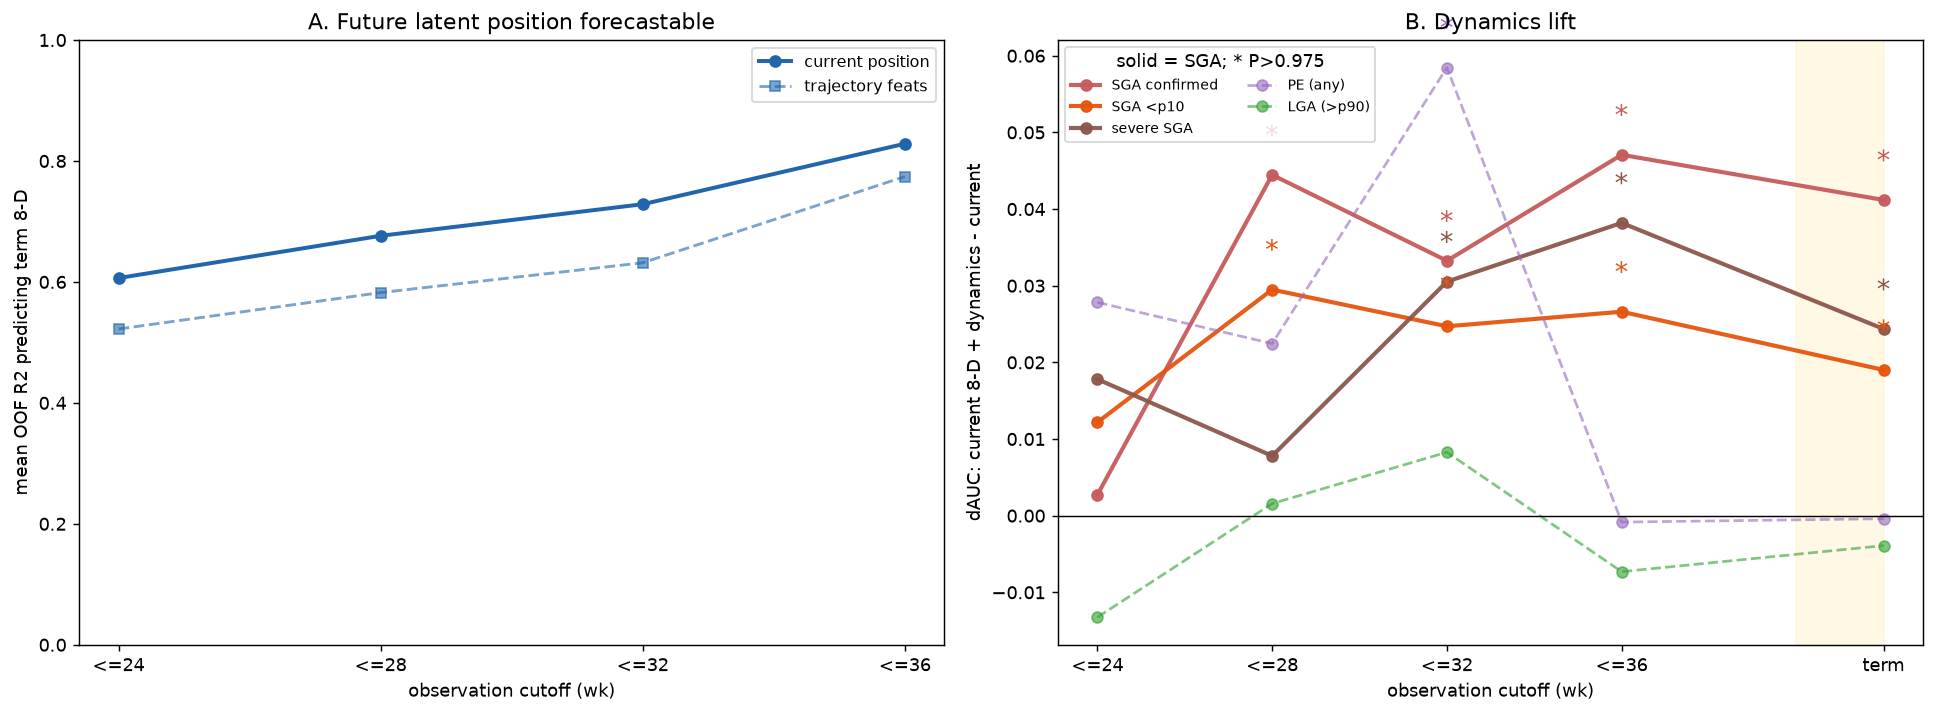

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
cutoffs_A = [24, 28, 32, 36]

axes[0].plot(cutoffs_A, [partA[c]["r2_current"] for c in cutoffs_A], marker="o", lw=2.2, color="#2166ac", label="current position")
axes[0].plot(cutoffs_A, [partA[c]["r2_trajectory"] for c in cutoffs_A], marker="s", ls="--", lw=1.6, color="#2166ac", alpha=.6, label="trajectory feats")
axes[0].set_xticks(cutoffs_A); axes[0].set_xticklabels([f"<={c}" for c in cutoffs_A]); axes[0].set_ylim(0, 1)
axes[0].set_xlabel("observation cutoff (wk)"); axes[0].set_ylabel("mean OOF R2 predicting term 8-D")
axes[0].legend(fontsize=9); axes[0].set_title("A. Future latent position forecastable")

outcome_colors = {"SGA confirmed": "#c65b5b", "SGA <p10": "#e6550d", "severe SGA": "#8c564b", "PE (any)": "#9467bd", "LGA (>p90)": "#2ca02c"}
sga_outcomes = {"SGA confirmed", "SGA <p10", "severe SGA"}

for name, color in outcome_colors.items():
    deltas = [(r["delta"] if r else np.nan) for r in partB[name]]
    p_values = [(r["P"] if r else 0) for r in partB[name]]
    axes[1].plot(CUTOFFS, deltas, marker="o", ls="-" if name in sga_outcomes else "--",
                 lw=2.3 if name in sga_outcomes else 1.5, color=color, label=name,
                 alpha=0.95 if name in sga_outcomes else 0.6)
    for x, y, p in zip(CUTOFFS, deltas, p_values):
        if p >= 0.975:
            axes[1].annotate("*", (x, y), (x, y + 0.004), ha="center", fontsize=15, color=color)

axes[1].axhline(0, color="k", lw=.8); axes[1].axvspan(40, 42, color="#fff2cc", alpha=.5, zorder=0)
axes[1].set_xticks(CUTOFFS); axes[1].set_xticklabels(["<=24","<=28","<=32","<=36","term"])
axes[1].set_xlabel("observation cutoff (wk)"); axes[1].set_ylabel("dAUC: current 8-D + dynamics - current")
axes[1].legend(fontsize=8, ncol=2, title="solid = SGA; * P>0.975"); axes[1].set_title("B. Dynamics lift")
fig.tight_layout(); plt.show()

## 10.  Interactive 3-D latent trajectory

Each fetus is a path through **GA × lag-axis × size-axis**; bold = group-mean path, ◆ = term endpoint. This shows the **primary** model only — for the **both-models** version (with-lag and no-lag side by side, each on its own best axes) see §12d.

In [ ]:
is_low_birth = np.isfinite(birth_pct) & (birth_pct < 10)
is_confirmed = np.isfinite(outcomes["SGA confirmed"]) & (outcomes["SGA confirmed"] == 1)
is_normal    = np.isfinite(birth_pct) & (birth_pct >= 10)

groups_3d = [("SGA (birth pct <10)", is_low_birth, "#e6550d"),
             ("confirmed-SGA (prenatal)", is_confirmed, "#c65b5b"),
             ("normal (>=p10)", is_normal, "#9e9e9e")]
ga_grid = np.arange(20, 39, 1.0)
fig3d = go.Figure()

In [ ]:
def add_group_paths(fig, mask, color, label):
    members = np.where(mask)[0]
    shown = members if label != "normal (>=p10)" else members[::6]
    lag_interp, size_interp = [], []

    for i in members:
        if seq_len[i] < 2:
            continue
        weeks = slot_ga_weeks(i)
        lag_path = latent_traj[i, :seq_len[i], lag_axis]
        size_path = latent_traj[i, :seq_len[i], size_axis]

        lag_interp.append(np.interp(ga_grid, weeks, lag_path, np.nan, np.nan))
        size_interp.append(np.interp(ga_grid, weeks, size_path, np.nan, np.nan))
        if i in shown:
            fig.add_trace(go.Scatter3d(x=weeks, y=lag_path, z=size_path, mode="lines",
                          line=dict(color=color, width=1.5), opacity=.15, showlegend=False, hoverinfo="skip"))

    return np.nanmean(lag_interp, 0), np.nanmean(size_interp, 0), len(members)

In [ ]:
def add_mean_path(fig, mean_lag_path, mean_size_path, color, name):
    fig.add_trace(go.Scatter3d(x=ga_grid, y=mean_lag_path, z=mean_size_path, mode="lines+markers",
                  line=dict(color=color, width=8), marker=dict(size=4, color=color), name=name))
    fig.add_trace(go.Scatter3d(x=[ga_grid[-1]], y=[mean_lag_path[-1]], z=[mean_size_path[-1]], mode="markers",
                  marker=dict(size=8, color=color, symbol="diamond", line=dict(color="black", width=2)),
                  showlegend=False, hoverinfo="skip"))

In [ ]:
for label, mask, color in groups_3d:
    mean_lag_path, mean_size_path, count = add_group_paths(fig3d, mask, color, label)
    add_mean_path(fig3d, mean_lag_path, mean_size_path, color, f"{label} (n={count})")

fig3d.update_layout(title=f"Latent trajectories: GA x lag-axis (z{lag_axis}) x size-axis (z{size_axis})",
    scene=dict(xaxis_title="gestational age (wk)", yaxis_title="lag axis", zaxis_title="size axis"),
    width=950, height=720)
fig3d.write_html(f"{IMG_DIR}/lag_latent_trajectory_3d.html", include_plotlyjs="cdn")
display(HTML(fig3d.to_html(include_plotlyjs="cdn", full_html=False)))

## 11.  Contrast model — retrain with the *other* lag setting

Retrains the identical GRU-VAE on the contrast input (if the primary uses lag, this is biometry + GA only, and vice-versa). Tests whether the lag axis needs the lag input, and whether the forecasting signal survives without it.

In [ ]:
contrast_model = train_gruvae(X_contrast, seq_len, contrast_dim, seed=0)
contrast_model.eval()
with torch.no_grad():
    contrast_traj = contrast_model.encode_sequence(torch.tensor(X_contrast)).numpy()
contrast_end = np.array([contrast_traj[i, seq_len[i] - 1] for i in range(n_fetus)])

In [ ]:
best_contrast_corr = max(abs(pearsonr(contrast_end[has_lag_and_birth, d], fetus_mean_lag[has_lag_and_birth])[0])
                         for d in range(LATENT_DIM))
primary_lag_corr = abs(pearsonr(latent_end[has_lag_and_birth, lag_axis], fetus_mean_lag[has_lag_and_birth])[0])
print(f"eff dim: {primary_name} {effective_dim(latent_end):.2f} | {contrast_name} {effective_dim(contrast_end):.2f}")
print(f"lag-axis |r| with mean lag: {primary_name} {primary_lag_corr:.3f} | best {contrast_name} dim {best_contrast_corr:.3f}")

eff dim: with-lag 1.37 | no-lag 1.25
lag-axis |r| with mean lag: with-lag 0.807 | best no-lag dim 0.200


**11b.** Part B on the no-lag latent — does the SGA dynamics lift survive without lag?

In [ ]:
partB_contrast = {name: [auc_delta(contrast_traj, y, c) for c in CUTOFFS] for name, y in outcomes.items()}

for name in outcomes:
    row = " ".join(f"{(r['delta'] if r else np.nan):+.3f}{'*' if (r and r['P']>=0.975) else ' '}" for r in partB_contrast[name])
    print(f"  {name:14s} dAUC: {row}")

  SGA confirmed  dAUC: +0.055  +0.032  +0.017  +0.026* +0.028*
  SGA <p10       dAUC: +0.021  +0.014  +0.019* +0.018* +0.020*
  severe SGA     dAUC: -0.010  +0.030* +0.025* +0.030* +0.031*
  PE (any)       dAUC: -0.001  +0.010  +0.032  +0.038  +0.034 
  LGA (>p90)     dAUC: +0.086* +0.007  +0.013* +0.010  +0.012 


## 12.  Birth-percentile regression — dynamics lift, with vs without lag

Continuous target (birth percentile). Current 8-D vs current + dynamics, 5-fold grouped Ridge, 2000× bootstrap on ΔR². Birth pct is evaluation-only.

In [ ]:
def birthpct_delta(traj, cutoff, n_boot=2000):
    current, features, index = collect_current_and_trajectory(traj, cutoff)
    target = birth_pct[index]; groups = fetus_ids[index]; valid = np.isfinite(target)
    current, features, target, groups = current[valid], features[valid], target[valid], groups[valid]

    pred_current = np.zeros(len(target)); pred_full = np.zeros(len(target))
    full_features = np.column_stack([current, features])
    for train, test in GroupKFold(5).split(current, groups=groups):
        pred_current[test] = Ridge(1.0).fit(current[train], target[train]).predict(current[test])
        pred_full[test]    = Ridge(1.0).fit(full_features[train], target[train]).predict(full_features[test])
    return bootstrap_r2_delta(pred_current, pred_full, target, n_boot)

In [ ]:
def bootstrap_r2_delta(pred_current, pred_full, target, n_boot):
    rng = np.random.RandomState(0); deltas = []

    for _ in range(n_boot):
        idx = rng.randint(0, len(target), len(target))
        deltas.append(r2_score(target[idx], pred_full[idx]) - r2_score(target[idx], pred_current[idx]))
    deltas = np.array(deltas)

    return dict(r2_current=float(r2_score(target, pred_current)), r2_full=float(r2_score(target, pred_full)),
                delta=float(deltas.mean()), lo=float(np.percentile(deltas, 2.5)),
                hi=float(np.percentile(deltas, 97.5)), P=float(np.mean(deltas > 0)))

In [ ]:
traj_by_lag = {primary_name: latent_traj, contrast_name: contrast_traj}   # map "with-lag"/"no-lag" to its trajectory
birthpct = {name: {c: birthpct_delta(traj, c) for c in CUTOFFS} for name, traj in traj_by_lag.items()}

for name in ["with-lag", "no-lag"]:
    print(f"birth-pct ({name}):")
    for c in CUTOFFS:
        r = birthpct[name][c]
        print(f"  <={c}wk: R2cur={r['r2_current']:.3f} +dyn={r['r2_full']:.3f}  dR2={r['delta']:+.3f} CI[{r['lo']:+.3f},{r['hi']:+.3f}] P={r['P']:.2f}")

birth-pct (with-lag):
  <=24wk: R2cur=0.010 +dyn=0.019  dR2=+0.009 CI[-0.024,+0.039] P=0.72
  <=28wk: R2cur=0.075 +dyn=0.091  dR2=+0.016 CI[-0.008,+0.039] P=0.91
  <=32wk: R2cur=0.167 +dyn=0.188  dR2=+0.021 CI[-0.007,+0.046] P=0.93
  <=36wk: R2cur=0.257 +dyn=0.269  dR2=+0.012 CI[-0.006,+0.030] P=0.91
  <=42wk: R2cur=0.231 +dyn=0.246  dR2=+0.015 CI[-0.002,+0.031] P=0.96
birth-pct (no-lag):
  <=24wk: R2cur=0.013 +dyn=0.008  dR2=-0.004 CI[-0.042,+0.028] P=0.44
  <=28wk: R2cur=0.118 +dyn=0.134  dR2=+0.015 CI[-0.007,+0.036] P=0.91
  <=32wk: R2cur=0.268 +dyn=0.281  dR2=+0.013 CI[-0.004,+0.030] P=0.93
  <=36wk: R2cur=0.315 +dyn=0.355  dR2=+0.041 CI[+0.024,+0.057] P=1.00
  <=42wk: R2cur=0.295 +dyn=0.352  dR2=+0.057 CI[+0.039,+0.076] P=1.00


**12b.** Birth-pct dynamics-lift figure, with vs no lag (built in one cell).

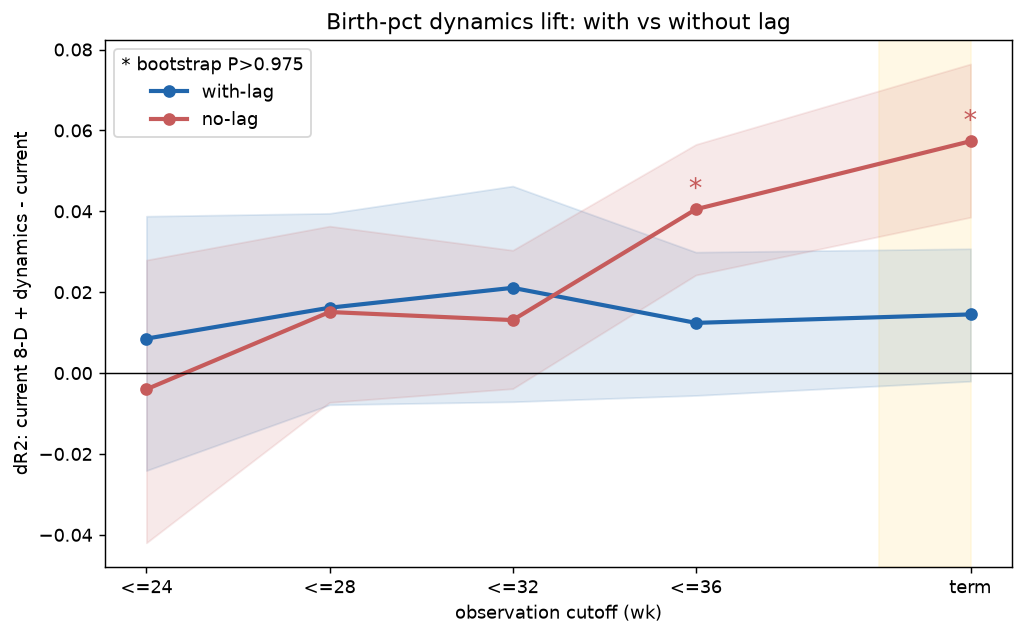

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, color in [("with-lag", "#2166ac"), ("no-lag", "#c65b5b")]:
    deltas = [birthpct[name][c]["delta"] for c in CUTOFFS]
    lo = [birthpct[name][c]["lo"] for c in CUTOFFS]; hi = [birthpct[name][c]["hi"] for c in CUTOFFS]
    p_values = [birthpct[name][c]["P"] for c in CUTOFFS]
    ax.plot(CUTOFFS, deltas, marker="o", lw=2.3, color=color, label=name)
    ax.fill_between(CUTOFFS, lo, hi, color=color, alpha=.13)
    for x, y, p in zip(CUTOFFS, deltas, p_values):
        if p >= 0.975:
            ax.annotate("*", (x, y), (x, y + 0.003), ha="center", fontsize=15, color=color)

ax.axhline(0, color="k", lw=.8); ax.axvspan(40, 42, color="#fff2cc", alpha=.5, zorder=0)
ax.set_xticks(CUTOFFS); ax.set_xticklabels(["<=24","<=28","<=32","<=36","term"])
ax.set_xlabel("observation cutoff (wk)"); ax.set_ylabel("dR2: current 8-D + dynamics - current")
ax.legend(title="* bootstrap P>0.975"); ax.set_title("Birth-pct dynamics lift: with vs without lag")
fig.tight_layout(); plt.show()

## 12c.  Position forecasting (A) + dynamics lift (B) — with-lag vs no-lag

The §9 figure shows the **primary** model only (with-lag by default). Here the same two panels are computed for **both** models — with-lag (top row) and no-lag (bottom row) — so the forecasting and dynamics-lift behaviour can be compared side by side.

**12c-1.** Build Part A (position forecastability) and Part B (dynamics lift) for each model.

In [ ]:
def build_partA(traj):
    return {cutoff: fit_partA(*collect_partA(traj, cutoff)) for cutoff in [24, 28, 32, 36]}

partA_by_lag = {name: build_partA(traj) for name, traj in traj_by_lag.items()}
partB_by_lag = {name: {o: [auc_delta(traj, y, c) for c in CUTOFFS] for o, y in outcomes.items()}
                for name, traj in traj_by_lag.items()}
print("built partA/partB for:", list(traj_by_lag))

built partA/partB for: ['with-lag', 'no-lag']


**12c-2.** The both-models figure (built in one cell).

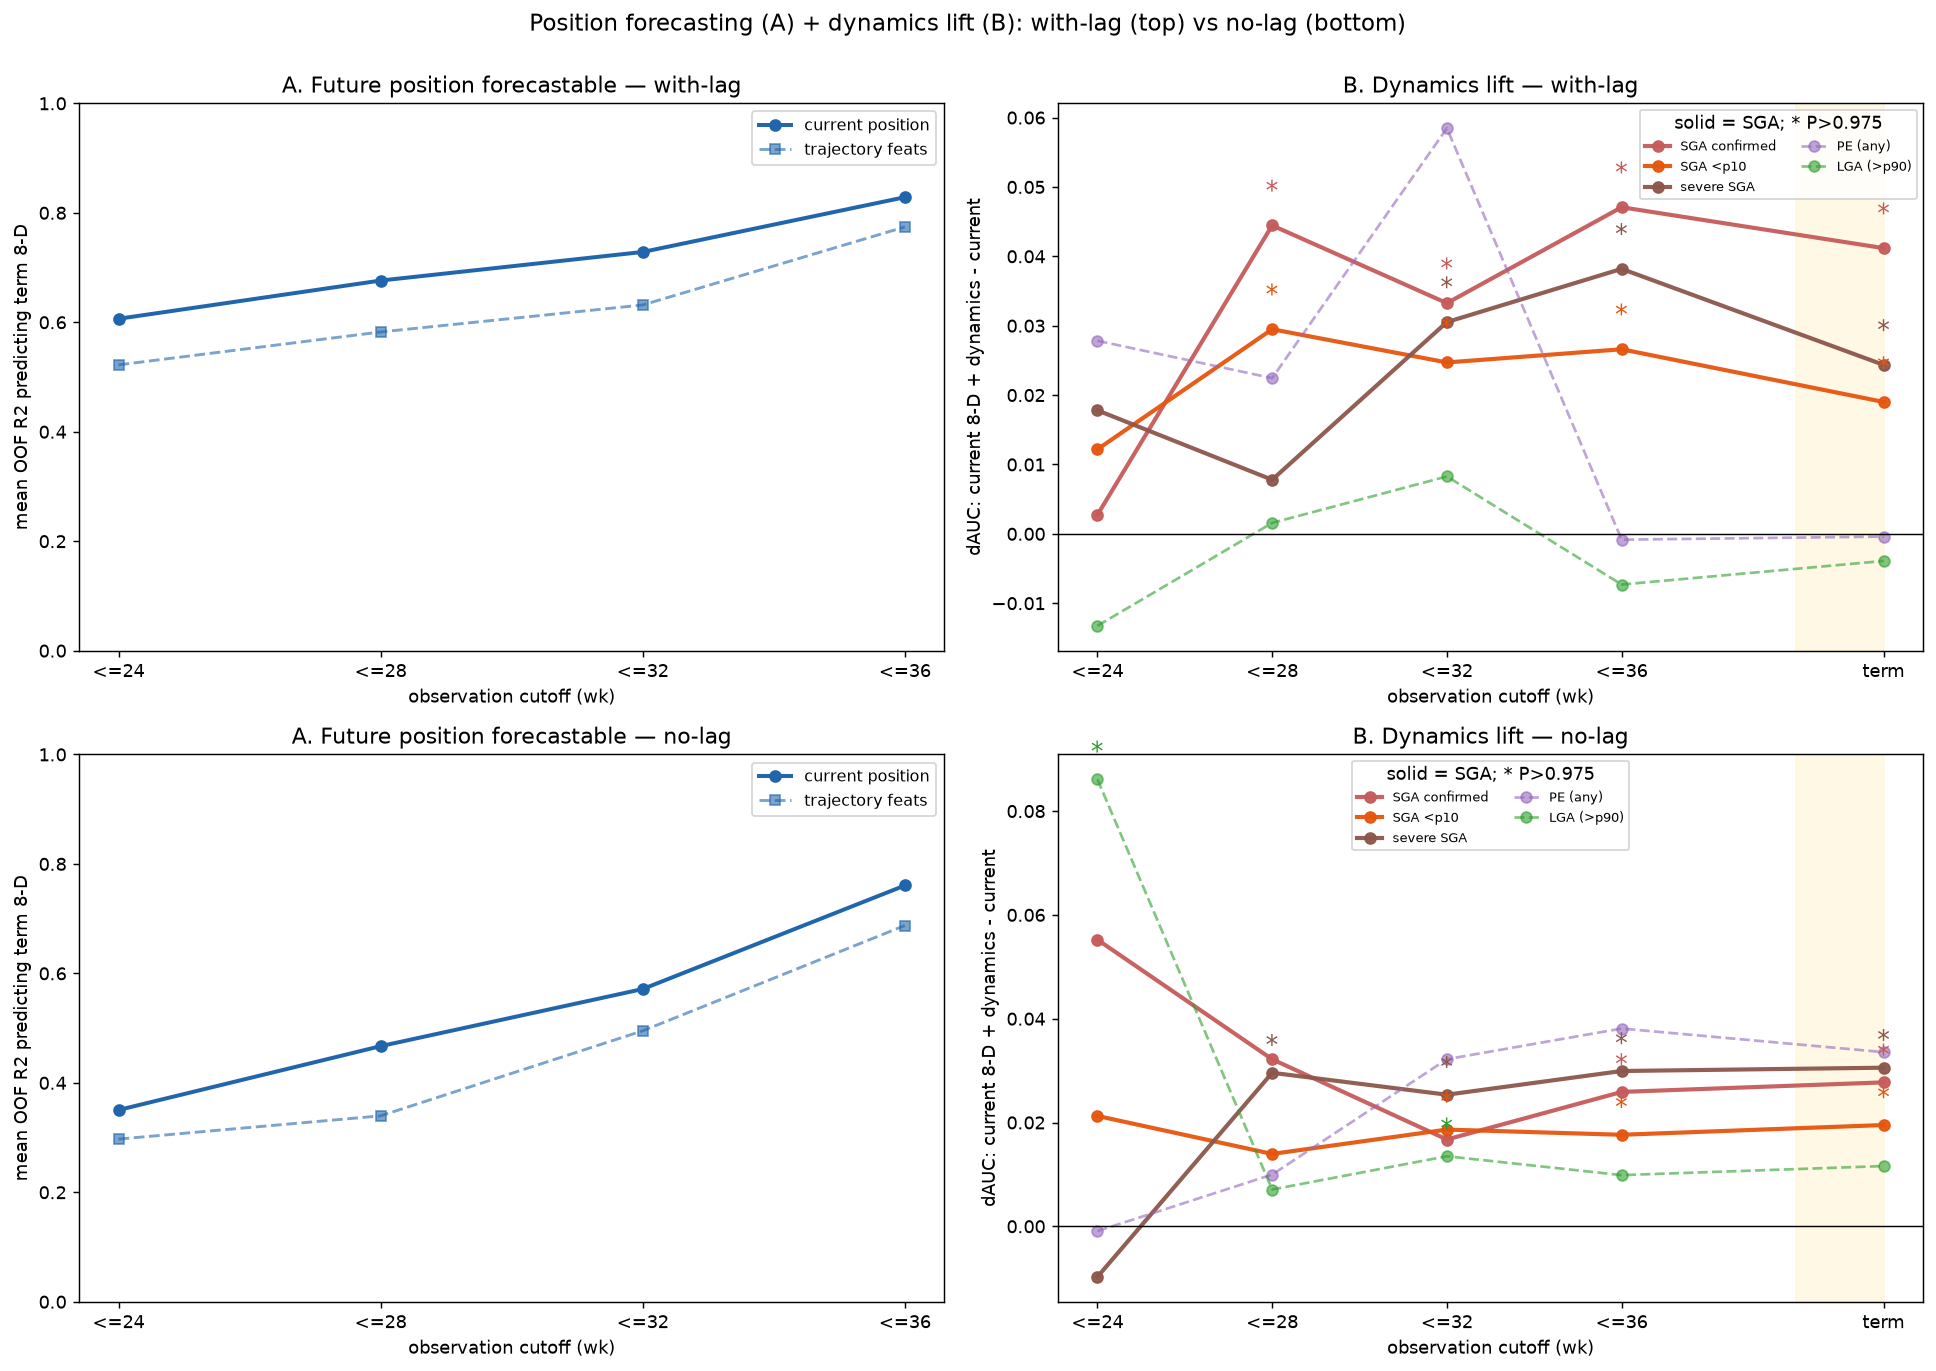

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10.5))
cutoffs_A = [24, 28, 32, 36]
outcome_colors = {"SGA confirmed": "#c65b5b", "SGA <p10": "#e6550d", "severe SGA": "#8c564b", "PE (any)": "#9467bd", "LGA (>p90)": "#2ca02c"}
sga_outcomes = {"SGA confirmed", "SGA <p10", "severe SGA"}

for row, model_name in enumerate(["with-lag", "no-lag"]):
    part_a, part_b = partA_by_lag[model_name], partB_by_lag[model_name]
    ax_a, ax_b = axes[row, 0], axes[row, 1]

    ax_a.plot(cutoffs_A, [part_a[c]["r2_current"] for c in cutoffs_A], marker="o", lw=2.2, color="#2166ac", label="current position")
    ax_a.plot(cutoffs_A, [part_a[c]["r2_trajectory"] for c in cutoffs_A], marker="s", ls="--", lw=1.6, color="#2166ac", alpha=.6, label="trajectory feats")
    ax_a.set_xticks(cutoffs_A); ax_a.set_xticklabels([f"<={c}" for c in cutoffs_A]); ax_a.set_ylim(0, 1)
    ax_a.set_xlabel("observation cutoff (wk)"); ax_a.set_ylabel("mean OOF R2 predicting term 8-D")
    ax_a.legend(fontsize=9); ax_a.set_title(f"A. Future position forecastable — {model_name}")

    for name, color in outcome_colors.items():
        deltas = [(r["delta"] if r else np.nan) for r in part_b[name]]
        stars = [x for x, r in zip(CUTOFFS, part_b[name]) if r and r["P"] >= 0.975]
        ax_b.plot(CUTOFFS, deltas, marker="o", ls="-" if name in sga_outcomes else "--",
                  lw=2.3 if name in sga_outcomes else 1.5, color=color, label=name, alpha=0.95 if name in sga_outcomes else 0.6)
        for x in stars:
            ax_b.annotate("*", (x, deltas[CUTOFFS.index(x)] + 0.004), ha="center", fontsize=14, color=color)

    ax_b.axhline(0, color="k", lw=.8); ax_b.axvspan(40, 42, color="#fff2cc", alpha=.5, zorder=0)
    ax_b.set_xticks(CUTOFFS); ax_b.set_xticklabels(["<=24","<=28","<=32","<=36","term"])
    ax_b.set_xlabel("observation cutoff (wk)"); ax_b.set_ylabel("dAUC: current 8-D + dynamics - current")
    ax_b.legend(fontsize=7, ncol=2, title="solid = SGA; * P>0.975"); ax_b.set_title(f"B. Dynamics lift — {model_name}")

fig.suptitle("Position forecasting (A) + dynamics lift (B): with-lag (top) vs no-lag (bottom)", y=1.00, fontsize=13)
fig.tight_layout(); plt.savefig(f"{IMG_DIR}/forecast_with_without_lag.png", dpi=130, bbox_inches="tight"); plt.show()

## 12d.  Interactive 3-D latent trajectory — with-lag vs no-lag

The §10 interactive plot shows the **primary** model only. Here both models appear as two 3-D scenes side by side — with-lag (left) and no-lag (right) — each on its *own* best lag-axis and size-axis (the no-lag model has no true lag axis, so its "lag axis" is just the closest-correlated dimension). Bold = group-mean path, ◆ = term endpoint.

**12d-1.** Pick each model's own best lag-axis / size-axis from its endpoint latent.

In [ ]:
def pick_axes(traj):
    end = np.array([traj[i, seq_len[i] - 1] for i in range(n_fetus)])
    ok = has_lag_and_birth
    lag_r  = [abs(pearsonr(end[ok, d], fetus_mean_lag[ok])[0]) for d in range(LATENT_DIM)]
    size_r = [abs(pearsonr(end[ok, d], birth_pct[ok])[0]) for d in range(LATENT_DIM)]
    return int(np.argmax(lag_r)), int(np.argmax(size_r))

axes_by_lag = {name: pick_axes(traj) for name, traj in traj_by_lag.items()}
print("best (lag-axis, size-axis) per model:", axes_by_lag)

best (lag-axis, size-axis) per model: {'with-lag': (0, 1), 'no-lag': (7, 4)}


**12d-2.** Path helper — parameterized on a model's trajectory and its two axes.

In [ ]:
def interp_one(traj, lag_ax, size_ax, i):
    weeks = slot_ga_weeks(i)
    lag_path, size_path = traj[i, :seq_len[i], lag_ax], traj[i, :seq_len[i], size_ax]
    lag_on_grid = np.interp(ga_grid, weeks, lag_path, np.nan, np.nan)
    size_on_grid = np.interp(ga_grid, weeks, size_path, np.nan, np.nan)
    return weeks, lag_path, size_path, lag_on_grid, size_on_grid

In [ ]:
def group_paths(traj, lag_ax, size_ax, mask, shown):
    lag_interp, size_interp, path_traces = [], [], []

    for i in [m for m in np.where(mask)[0] if seq_len[m] >= 2]:
        weeks, lag_path, size_path, lag_g, size_g = interp_one(traj, lag_ax, size_ax, i)
        lag_interp.append(lag_g); size_interp.append(size_g)
        if i in shown:
            path_traces.append((weeks, lag_path, size_path))

    return np.nanmean(lag_interp, 0), np.nanmean(size_interp, 0), path_traces

**12d-3.** Build the two-scene interactive figure and write the HTML.

In [ ]:
from plotly.subplots import make_subplots
fig_both = make_subplots(rows=1, cols=2, specs=[[{"type": "scene"}, {"type": "scene"}]],
                         subplot_titles=[f"with-lag (lag z{axes_by_lag['with-lag'][0]})",
                                         f"no-lag (best dim z{axes_by_lag['no-lag'][0]})"])

for col, model_name in enumerate(["with-lag", "no-lag"], start=1):
    traj = traj_by_lag[model_name]; lag_ax, size_ax = axes_by_lag[model_name]
    scene = "scene" if col == 1 else "scene2"
    for label, mask, color in groups_3d:
        members = np.where(mask)[0]
        shown = members if label != "normal (>=p10)" else members[::6]
        mean_lag, mean_size, path_traces = group_paths(traj, lag_ax, size_ax, mask, set(shown))
        for weeks, lag_path, size_path in path_traces:
            fig_both.add_trace(go.Scatter3d(x=weeks, y=lag_path, z=size_path, mode="lines",
                line=dict(color=color, width=1.5), opacity=.13, showlegend=False, hoverinfo="skip"), row=1, col=col)
        fig_both.add_trace(go.Scatter3d(x=ga_grid, y=mean_lag, z=mean_size, mode="lines+markers",
            line=dict(color=color, width=8), marker=dict(size=3, color=color),
            name=f"{label}" if col == 1 else None, showlegend=(col == 1), legendgroup=label), row=1, col=col)
        fig_both.add_trace(go.Scatter3d(x=[ga_grid[-1]], y=[mean_lag[-1]], z=[mean_size[-1]], mode="markers",
            marker=dict(size=7, color=color, symbol="diamond", line=dict(color="black", width=2)),
            showlegend=False, hoverinfo="skip"), row=1, col=col)

axis_titles = dict(xaxis_title="GA (wk)", yaxis_title="lag axis", zaxis_title="size axis")
fig_both.update_layout(title="Latent trajectories: with-lag (left) vs no-lag (right)",
    scene=axis_titles, scene2=axis_titles, width=1300, height=650)
fig_both.write_html(f"{IMG_DIR}/lag_latent_trajectory_3d_both.html", include_plotlyjs="cdn")
display(HTML(fig_both.to_html(include_plotlyjs="cdn", full_html=False)))

## 13.  Head-to-head study — four lag configurations

A single, explicit comparison of how the appearance-lag enters the model. Four configurations, all trained the same way, all scored on the same held-out metrics:

| configuration | lag input |
|---|---|
| **no-lag** | biometry + GA only (no lag channel) |
| **pooled-mean** | one lag channel, all planes → one clock, **mean** per (fetus, GA-week) — canonical |
| **pooled-median** | one lag channel, all planes → one clock, **median** per (fetus, GA-week) |
| **per-plane** | three lag channels, one clock + channel per plane |

This section is self-contained: it recomputes the clocks, builds each input, trains a GRU-VAE, and scores all four — then plots them side by side and writes the table to CSV.

**13a.** One GA maturation-clock per set of planes → per-image lag (predicted − true GA).

In [ ]:
def per_image_lag_for(planes_used):
    keep = valid_image & np.isin(image_plane, planes_used)
    emb_k, true_ga_k = embeddings[keep], image_true_ga[keep]
    fetus_k = image_fetus_id.values[keep].astype(int)

    predicted_ga = np.zeros(len(true_ga_k))
    for train, test in GroupKFold(5).split(emb_k, true_ga_k, fetus_k):
        predicted_ga[test] = Ridge(alpha=RIDGE_ALPHA).fit(emb_k[train], true_ga_k[train]).predict(emb_k[test])
    return pd.DataFrame({"fetus": fetus_k, "ga_week": np.round(true_ga_k).astype(int), "lag": predicted_ga - true_ga_k})

**13b.** Compute the pooled clock (all planes) and the three per-plane clocks once.

In [ ]:
pooled_lags = per_image_lag_for(PLANES)
per_plane_lags = {plane: per_image_lag_for([plane]) for plane in PLANES}
print("pooled clock r =",
      round(pearsonr(pooled_lags.ga_week, pooled_lags.ga_week + pooled_lags.lag)[0], 3),
      "| per-plane fetuses:", {p: df.fetus.nunique() for p, df in per_plane_lags.items()})

pooled clock r = 0.847 | per-plane fetuses: {'abdominal': 945, 'cerebral': 947, 'femur': 889}


**13c.** Aggregate per-image lag to a (fetus, GA-week) series — mean or median — per channel.

In [ ]:
def binned(per_image_frame, aggregate):
    return per_image_frame.groupby(["fetus", "ga_week"]).lag.agg(aggregate)

lag_bins = {
    "pooled-mean":   [binned(pooled_lags, "mean")],
    "pooled-median": [binned(pooled_lags, "median")],
    "per-plane":     [binned(per_plane_lags[p], "mean") for p in PLANES]}
print("channels per config:", {name: len(bins) for name, bins in lag_bins.items()})

channels per config: {'pooled-mean': 1, 'pooled-median': 1, 'per-plane': 3}


**13d.** Map binned lag onto the 12-slot merged timeline (±1 wk match) → lag grid per config.

In [ ]:
def lookup_binned(series, fetus, slot_ga):
    for candidate in (slot_ga, slot_ga - 1, slot_ga + 1):
        if (fetus, candidate) in series.index:
            return series.loc[(fetus, candidate)]
    return None

In [ ]:
def grid_from_bins(bin_series_list):
    n_ch = len(bin_series_list)
    grid = np.zeros((n_fetus, n_slots, n_ch), np.float32)
    mask = np.zeros((n_fetus, n_slots, n_ch), np.float32)

    for i, fetus in enumerate(fetus_ids):
        for slot in range(int(merged_len[i])):
            slot_ga = int(round(merged_seq[i, slot, -1] * 36 + 6))
            for ci, series in enumerate(bin_series_list):
                value = lookup_binned(series, int(fetus), slot_ga)
                if value is not None:
                    grid[i, slot, ci] = value; mask[i, slot, ci] = 1.0

    return grid, mask

**13e.** Assemble the GRU-VAE input for a lag grid: `[biometry | (lag,mask)×channels | GA]`.

In [ ]:
def assemble_input(grid, mask):
    n_ch = grid.shape[2]
    lag_block = np.concatenate([np.concatenate([grid[:, :, c:c+1], mask[:, :, c:c+1]], -1)
                                for c in range(n_ch)], -1)
    return np.concatenate([biom_block, lag_block, ga_channel], -1).astype(np.float32)

**13f.** Reference per-fetus lag (pooled mean) — the yardstick for 'is a lag axis present?'.

In [ ]:
reference_frame = pooled_lags.groupby("fetus").lag.mean()
reference_mean_lag = np.array([reference_frame.get(int(f), np.nan) for f in fetus_ids])
has_reference = np.isfinite(reference_mean_lag)
print("fetuses with reference lag:", int(has_reference.sum()))

fetuses with reference lag: 890


**13g.** Train one GRU-VAE per configuration and score it on the shared held-out metrics.

In [ ]:
def train_and_encode(X, in_dim):
    model = train_gruvae(X, seq_len, in_dim, seed=0)
    model.eval()
    with torch.no_grad():
        traj = model.encode_sequence(torch.tensor(X)).numpy()
    end = np.array([traj[i, seq_len[i] - 1] for i in range(n_fetus)])
    return traj, end

In [ ]:
def score_config(traj, end, in_dim):
    lag_axis_r = max(abs(pearsonr(end[has_reference, d], reference_mean_lag[has_reference])[0])
                     for d in range(LATENT_DIM))
    partA_r2 = fit_partA(*collect_partA(traj, 32))["r2_current"]

    sga_curves = {name: [auc_delta(traj, outcomes[name], c) for c in CUTOFFS]
                  for name in ["SGA confirmed", "SGA <p10", "severe SGA"]}
    birth = birthpct_delta(traj, 42)

    result = dict(input_dim=in_dim, eff_dim=round(effective_dim(end), 2), lag_axis_r=round(lag_axis_r, 3),
                  partA_r2_le32=round(partA_r2, 3), sga_curves=sga_curves,
                  birthpct_dr2_term=round(birth["delta"], 3), birthpct_P=round(birth["P"], 2))
    for key, curve in sga_curves.items():
        result[f"{key} dauc_term"] = round(curve[-1]["delta"], 3)
        result[f"{key} P"] = round(curve[-1]["P"], 2)
    return result

In [ ]:
config_inputs = {"no-lag": X_no_lag}
for name, bins in lag_bins.items():
    grid, mask = grid_from_bins(bins)
    config_inputs[name] = assemble_input(grid, mask)

config_scores, config_traj, config_end = {}, {}, {}
for name, X in config_inputs.items():
    traj, end = train_and_encode(X, X.shape[2])
    config_traj[name], config_end[name] = traj, end
    config_scores[name] = score_config(traj, end, X.shape[2])
    print(f"  {name:14s} scored (dim {X.shape[2]})")

  no-lag         scored (dim 11)
  pooled-mean    scored (dim 13)
  pooled-median  scored (dim 13)
  per-plane      scored (dim 17)


**13h.** Comparison table → CSV.

In [ ]:
CONFIG_ORDER = ["no-lag", "pooled-mean", "pooled-median", "per-plane"]
scalar_cols = ["input_dim", "eff_dim", "lag_axis_r", "partA_r2_le32",
               "SGA confirmed dauc_term", "SGA confirmed P", "SGA <p10 dauc_term", "SGA <p10 P",
               "severe SGA dauc_term", "severe SGA P", "birthpct_dr2_term", "birthpct_P"]
comparison = pd.DataFrame([dict(config=name, **{k: config_scores[name][k] for k in scalar_cols}) for name in CONFIG_ORDER])

comparison.to_csv(f"{IMG_DIR}/lag_config_comparison.csv", index=False)
print(comparison.to_string(index=False))

       config  input_dim  eff_dim  lag_axis_r  partA_r2_le32  SGA confirmed dauc_term  SGA confirmed P  SGA <p10 dauc_term  SGA <p10 P  severe SGA dauc_term  severe SGA P  birthpct_dr2_term  birthpct_P
       no-lag         11     1.25       0.212          0.571                    0.028             0.99               0.020        0.99                 0.031          1.00              0.057        1.00
  pooled-mean         13     1.37       0.619          0.728                    0.041             1.00               0.019        0.98                 0.024          1.00              0.015        0.96
pooled-median         13     1.39       0.615          0.707                    0.039             1.00               0.018        0.98                 0.023          1.00              0.019        0.99
    per-plane         17     1.46       0.695          0.706                    0.049             1.00               0.008        0.83                 0.032          0.97             -0.001   

**13i.** Comparison figure — the four configurations side by side (built in one cell).

In [ ]:
sga_rows = []                                          # SGA dAUC at every cutoff, all three definitions, per config
for name in CONFIG_ORDER:
    for definition, curve in config_scores[name]["sga_curves"].items():
        for cutoff, r in zip(CUTOFFS, curve):
            d = (r["delta"], r["P"]) if r else (np.nan, np.nan)
            sga_rows.append(dict(config=name, definition=definition, cutoff_wk=cutoff, sga_dauc=round(d[0], 3), sga_P=round(d[1], 2)))

sga_curve_table = pd.DataFrame(sga_rows)
sga_curve_table.to_csv(f"{IMG_DIR}/lag_config_sga_curve.csv", index=False)
print(sga_curve_table.pivot_table(index=["definition","cutoff_wk"], columns="config", values="sga_dauc").to_string())

config                   no-lag  per-plane  pooled-mean  pooled-median
definition    cutoff_wk                                               
SGA <p10      24          0.021      0.004        0.012          0.011
              28          0.014     -0.002        0.029          0.025
              32          0.019      0.000        0.025          0.021
              36          0.018      0.003        0.027          0.025
              42          0.020      0.008        0.019          0.018
SGA confirmed 24          0.055      0.044        0.003         -0.003
              28          0.032      0.008        0.044          0.036
              32          0.017     -0.011        0.033          0.025
              36          0.026      0.028        0.047          0.047
              42          0.028      0.049        0.041          0.039
severe SGA    24         -0.010     -0.020        0.018          0.003
              28          0.030     -0.003        0.008          0.003
      

In [ ]:
def star_significant(ax, bars, p_key):
    for name, bar in zip(CONFIG_ORDER, bars):
        if p_key is not None and config_scores[name][p_key] >= 0.975:
            ax.annotate("*", (bar.get_x() + bar.get_width()/2, bar.get_height()), ha="center", va="bottom", fontsize=16)

def draw_metric_panel(ax, metric, p_key, title, ylabel):
    values = [config_scores[name][metric] for name in CONFIG_ORDER]
    bars = ax.bar(CONFIG_ORDER, values, color=bar_colors, edgecolor="black", linewidth=.6)
    star_significant(ax, bars, p_key)
    ax.axhline(0, color="k", lw=.7); ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=11); ax.tick_params(axis="x", rotation=20)

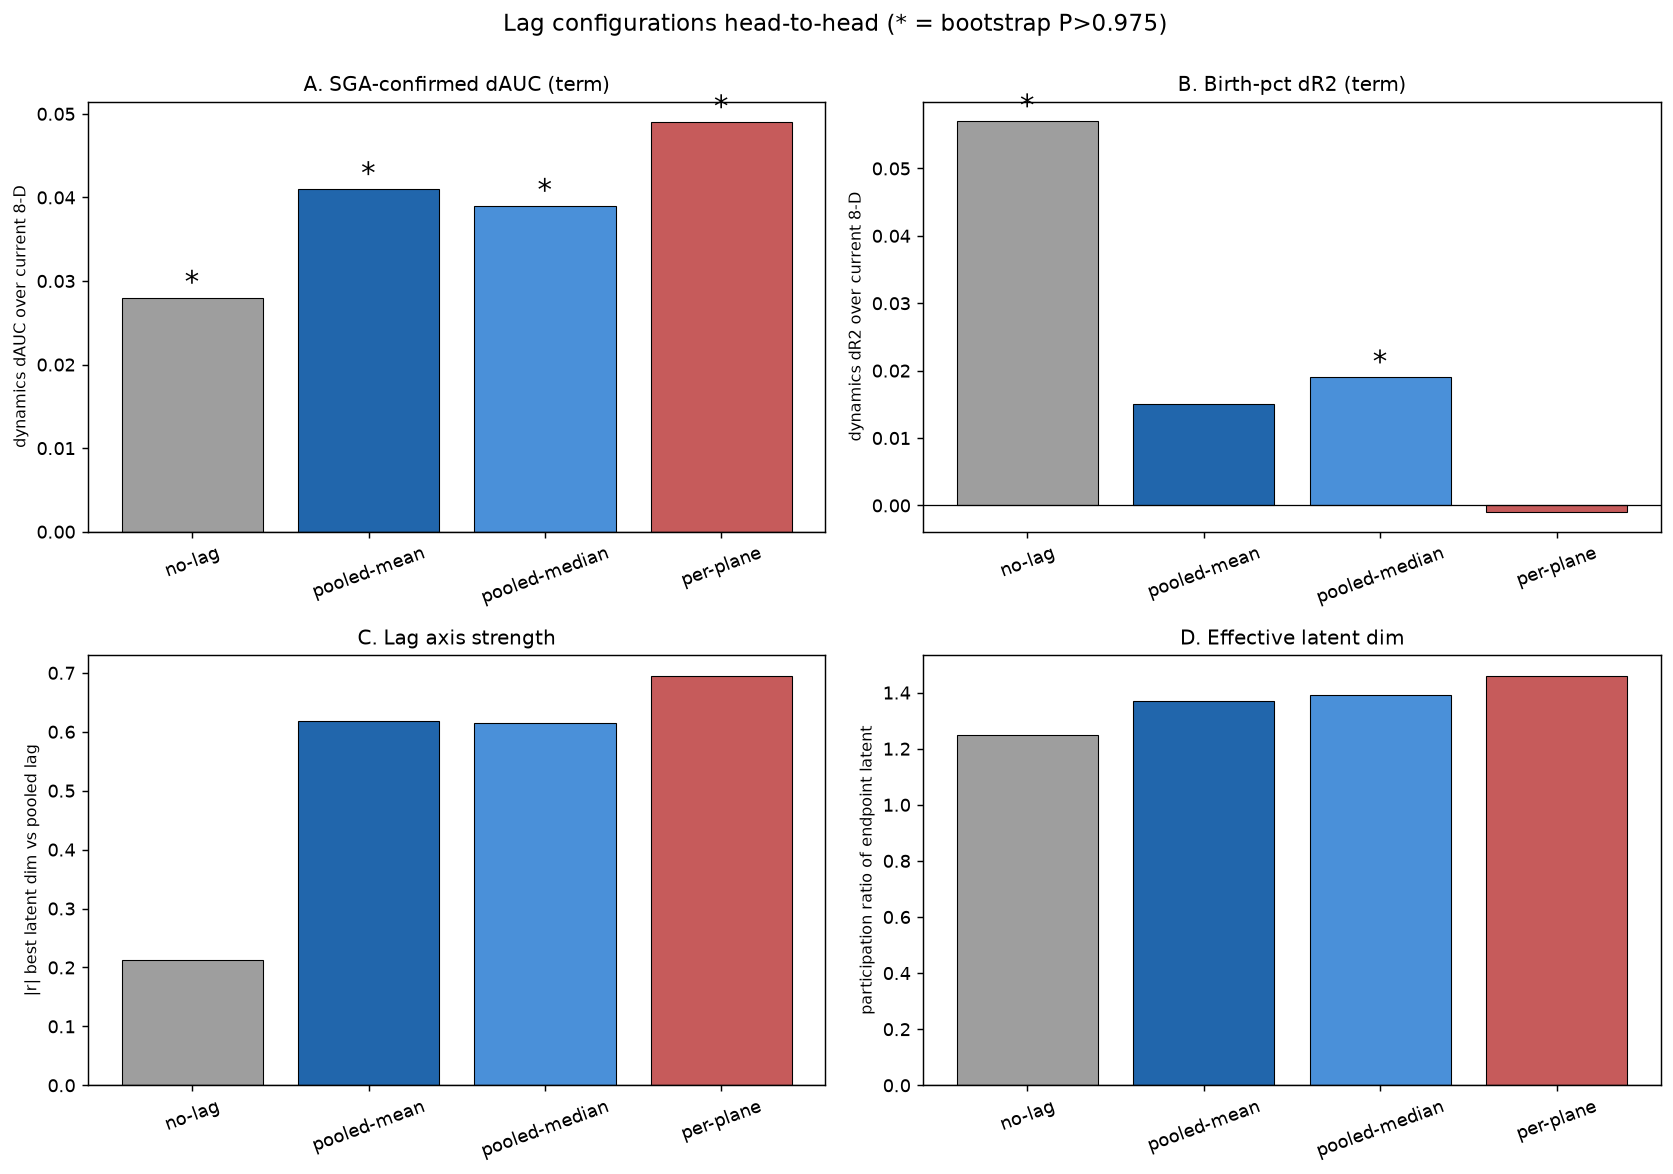

In [ ]:
colors = {"no-lag": "#9e9e9e", "pooled-mean": "#2166ac", "pooled-median": "#4a90d9", "per-plane": "#c65b5b"}
bar_colors = [colors[name] for name in CONFIG_ORDER]
panels = [("SGA confirmed dauc_term", "SGA confirmed P", "A. SGA-confirmed dAUC (term)", "dynamics dAUC over current 8-D"),
          ("birthpct_dr2_term", "birthpct_P", "B. Birth-pct dR2 (term)", "dynamics dR2 over current 8-D"),
          ("lag_axis_r", None, "C. Lag axis strength", "|r| best latent dim vs pooled lag"),
          ("eff_dim", None, "D. Effective latent dim", "participation ratio of endpoint latent")]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, panel in zip(axes.ravel(), panels):
    draw_metric_panel(ax, *panel)

fig.suptitle("Lag configurations head-to-head (* = bootstrap P>0.975)", fontsize=13, y=1.00)
fig.tight_layout(); plt.savefig(f"{IMG_DIR}/lag_config_comparison.png", dpi=130, bbox_inches="tight"); plt.show()

**13i-2.** SGA ΔAUC across **all visit cutoffs**, per configuration — one figure for each SGA definition (confirmed, <p10, severe). Each shows how the dynamics-lift grows as more of the pregnancy is observed (* = bootstrap P>0.975).

In [ ]:
config_colors = {"no-lag": "#9e9e9e", "pooled-mean": "#2166ac", "pooled-median": "#4a90d9", "per-plane": "#c65b5b"}

def sga_series(name, definition):
    curve = config_scores[name]["sga_curves"][definition]
    deltas = [(r["delta"] if r else np.nan) for r in curve]
    stars = [x for x, r in zip(CUTOFFS, curve) if r and r["P"] >= 0.975]
    return deltas, stars

In [ ]:
def plot_sga_curve(definition, filename):
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    for name in CONFIG_ORDER:
        deltas, stars = sga_series(name, definition)
        ax.plot(CUTOFFS, deltas, marker="o", lw=2.3, color=config_colors[name], label=name)
        for xv in stars:
            ax.annotate("*", (xv, deltas[CUTOFFS.index(xv)] + 0.003), ha="center", fontsize=15, color=config_colors[name])

    ax.axhline(0, color="k", lw=.8); ax.axvspan(40, 42, color="#fff2cc", alpha=.5, zorder=0)
    ax.set_xticks(CUTOFFS); ax.set_xticklabels(["<=24", "<=28", "<=32", "<=36", "term"])
    ax.set_xlabel("observation cutoff (wk)"); ax.set_ylabel(f"{definition} dAUC (dynamics over current 8-D)")
    ax.legend(title="* bootstrap P>0.975"); ax.set_title(f"{definition}: dynamics-lift vs observation cutoff")
    fig.tight_layout(); plt.savefig(f"{IMG_DIR}/{filename}", dpi=130, bbox_inches="tight"); plt.show()

**13i-2a.** SGA confirmed (prenatally adjudicated).

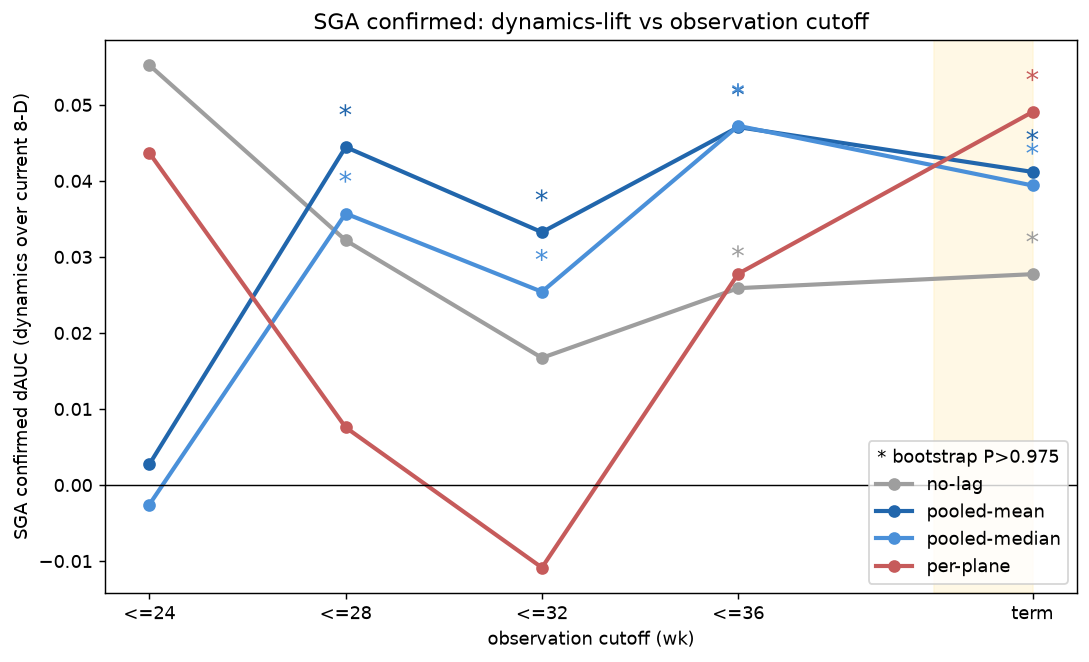

In [ ]:
plot_sga_curve("SGA confirmed", "lag_config_sga_curve_confirmed.png")

**13i-2b.** SGA <p10 (general, birth-percentile definition).

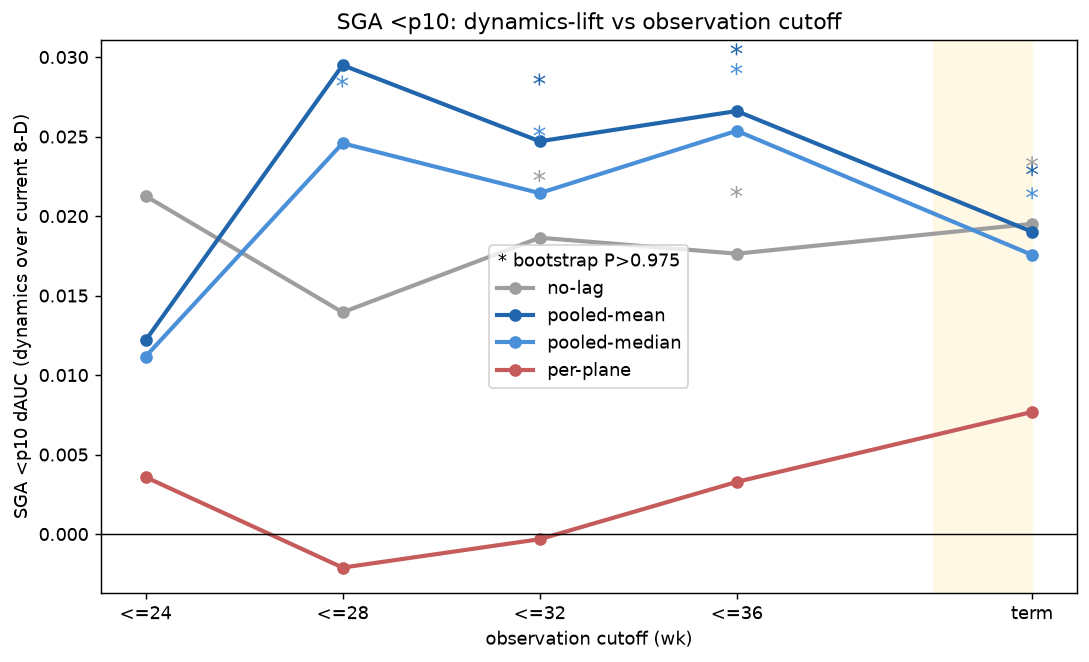

In [ ]:
plot_sga_curve("SGA <p10", "lag_config_sga_curve_p10.png")

**13i-2c.** Severe SGA (<p3).

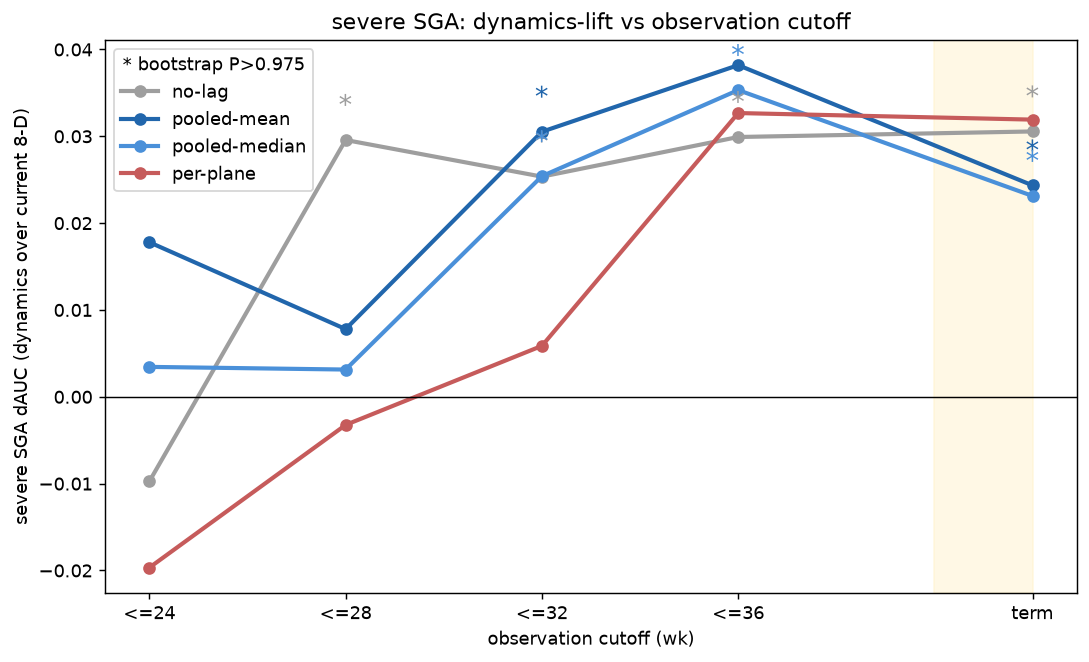

In [ ]:
plot_sga_curve("severe SGA", "lag_config_sga_curve_severe.png")

## 13k.  Does lag structure the latent space?

Three views of the **endpoint latent** per configuration, showing whether the appearance-lag actually organizes the space (or not, for no-lag).

**13k-1.** Per-config axis loadings — for every latent dimension, its correlation with the reference lag and with birth percentile. A tall lag bar = a dimension the model devotes to lag.

In [ ]:
def axis_loadings(end):
    lag_r = [pearsonr(end[has_reference, d], reference_mean_lag[has_reference])[0] for d in range(LATENT_DIM)]
    birth_ok = np.isfinite(birth_pct)
    birth_r = [pearsonr(end[birth_ok, d], birth_pct[birth_ok])[0] for d in range(LATENT_DIM)]
    return np.array(lag_r), np.array(birth_r)

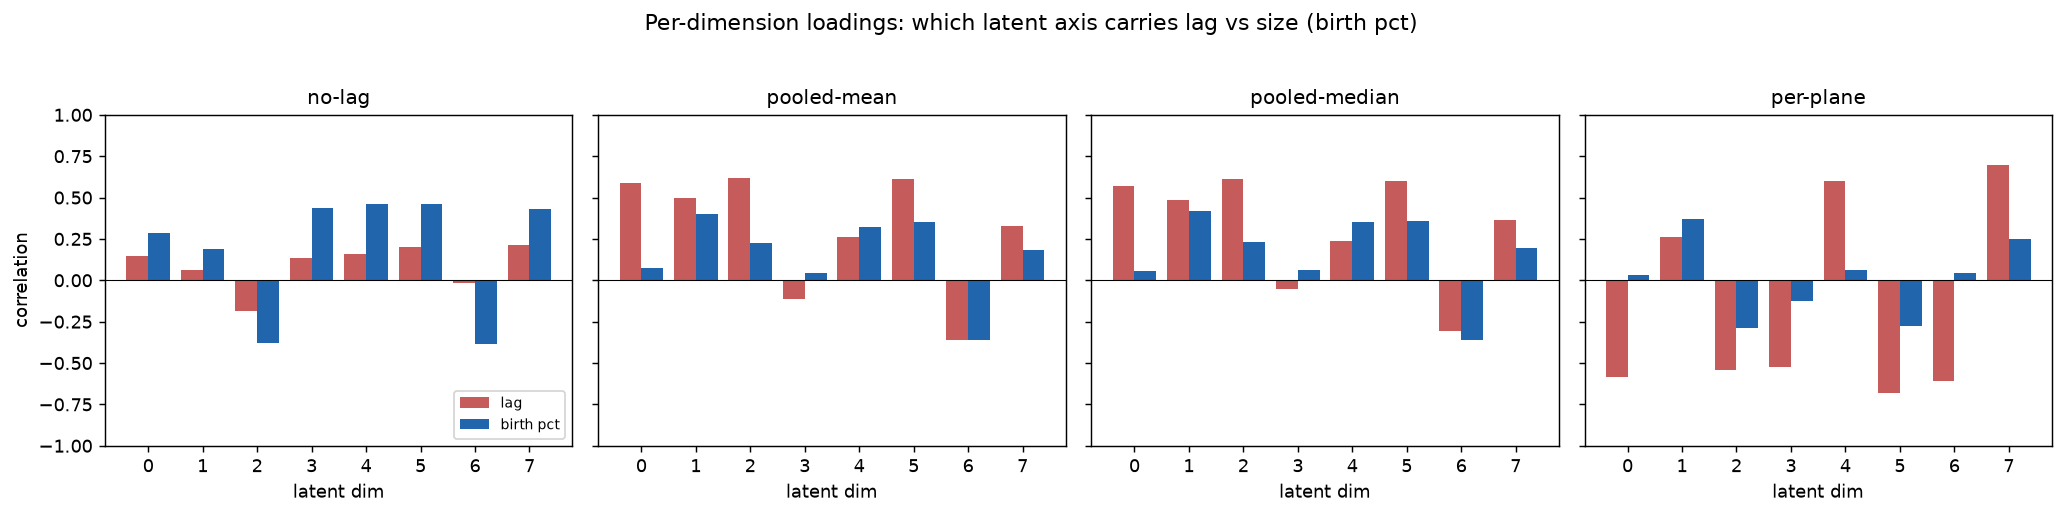

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
dims = np.arange(LATENT_DIM); width = 0.4

for ax, name in zip(axes, CONFIG_ORDER):
    lag_r, birth_r = axis_loadings(config_end[name])
    ax.bar(dims - width/2, lag_r, width, color="#c65b5b", label="lag")
    ax.bar(dims + width/2, birth_r, width, color="#2166ac", label="birth pct")
    ax.axhline(0, color="k", lw=.6); ax.set_xticks(dims); ax.set_xlabel("latent dim")
    ax.set_title(name, fontsize=11); ax.set_ylim(-1, 1)

axes[0].set_ylabel("correlation"); axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("Per-dimension loadings: which latent axis carries lag vs size (birth pct)", y=1.03)
fig.tight_layout(); plt.savefig(f"{IMG_DIR}/lag_config_loadings.png", dpi=130, bbox_inches="tight"); plt.show()

## 13k-2.  Endpoint latent on each config's best lag-SEPARATING axis

Each config gets its **own** best lag-separating direction — the cross-validated logistic-regression discriminant between high- and low-lag fetuses, fit on that config's full latent. This is the fair comparison you asked for: no config is plotted against a borrowed "lag axis". The x-axis title shows that config's separability AUC (§13k-3). y is the analogous best size-separating axis; color = reference lag. If a config can separate lag, the colors split left→right along x.

In [ ]:
def best_axes(end):
    lag_r = [abs(pearsonr(end[has_reference, d], reference_mean_lag[has_reference])[0]) for d in range(LATENT_DIM)]
    birth_ok = np.isfinite(birth_pct)
    birth_r = [abs(pearsonr(end[birth_ok, d], birth_pct[birth_ok])[0]) for d in range(LATENT_DIM)]
    return int(np.argmax(lag_r)), int(np.argmax(birth_r))

In [ ]:
scatter_mask = has_reference & np.isfinite(birth_pct)     # common set of fetuses for both axes

def separating_score(end, target_binary):
    X = end[scatter_mask]; y = target_binary[scatter_mask].astype(int)
    score = np.zeros(len(y))
    for tr, te in KFold(5, shuffle=True, random_state=0).split(X):
        fit = LogisticRegression(max_iter=500).fit(X[tr], y[tr])
        score[te] = fit.decision_function(X[te])
    return score

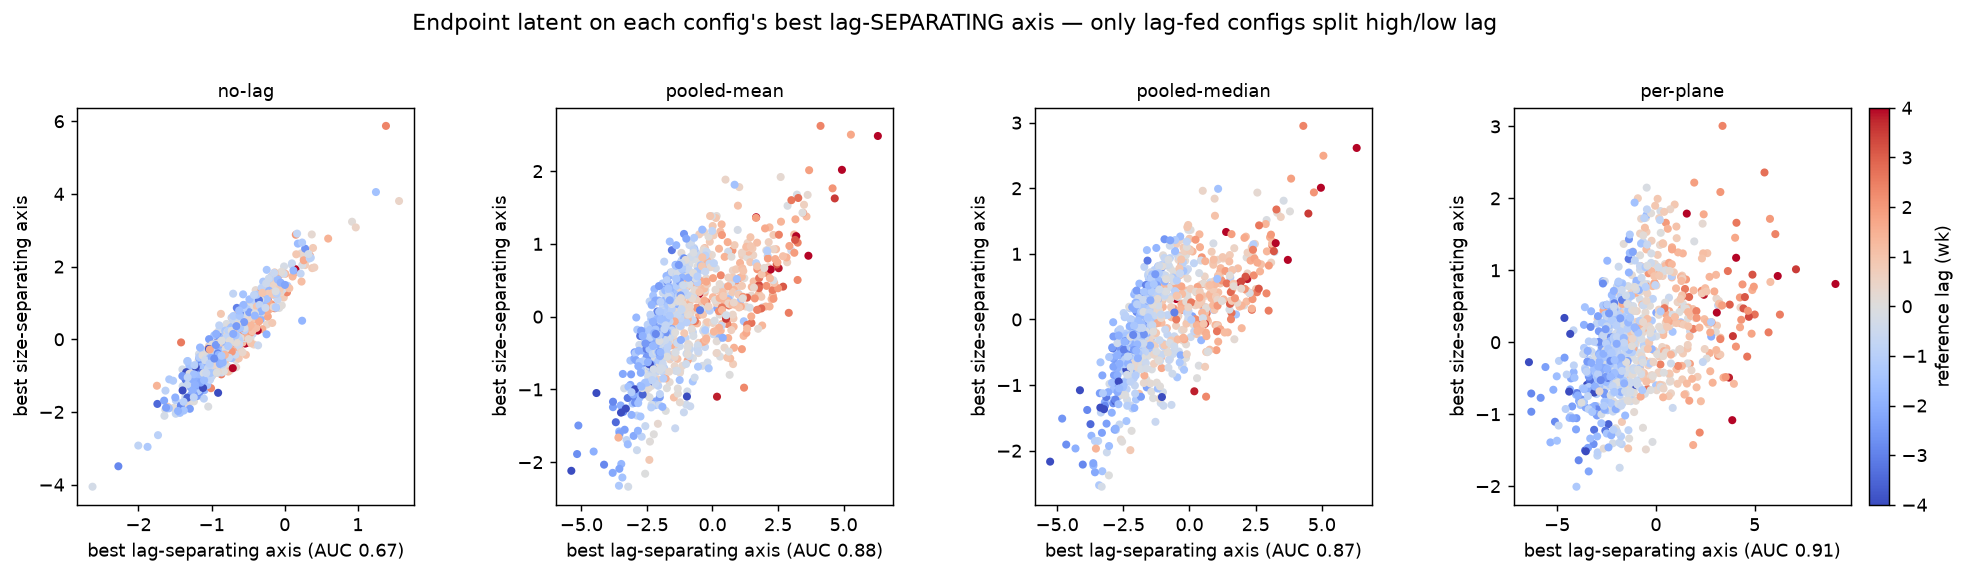

In [ ]:
is_high_lag = (reference_mean_lag >= np.nanpercentile(reference_mean_lag[has_reference], 66.7)).astype(float)
is_big = (birth_pct >= np.nanmedian(birth_pct[np.isfinite(birth_pct)])).astype(float)
lag_color = reference_mean_lag[scatter_mask]; lag_hi = is_high_lag[scatter_mask].astype(int)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.3)); fig.subplots_adjust(wspace=0.42, top=0.82)
for ax, name in zip(axes, CONFIG_ORDER):
    x_lag = separating_score(config_end[name], is_high_lag); y_size = separating_score(config_end[name], is_big)
    sc = ax.scatter(x_lag, y_size, c=lag_color, cmap="coolwarm", s=12, vmin=-4, vmax=4)
    ax.set_xlabel(f"best lag-separating axis (AUC {roc_auc_score(lag_hi, x_lag):.2f})"); ax.set_ylabel("best size-separating axis")
    ax.set_title(name, fontsize=10)

fig.colorbar(sc, ax=axes, fraction=0.012, pad=0.01, label="reference lag (wk)")
fig.suptitle("Endpoint latent on each config's best lag-SEPARATING axis — only lag-fed configs split high/low lag", y=0.99, fontsize=12)
plt.savefig(f"{IMG_DIR}/lag_config_latent_scatter.png", dpi=130, bbox_inches="tight"); plt.show()

## 13k-3.  Can the latent SEPARATE lag groups — as well as per-plane?

Not "recover the lag value" (regression) but **separability**: can the latent split high-lag from low-lag fetuses? We label the top and bottom lag tertiles (looks-older vs looks-younger) and measure how cleanly each config's latent tells them apart — using (i) its single best dimension and (ii) the full latent — as cross-validated discrimination AUC. This is the fair per-config test: each config gets its own best separating direction, so no-lag is not forced onto a borrowed "lag axis".

**13k-3a.** Define high- vs low-lag groups (outer tertiles of reference lag).

In [ ]:
lag_ref = reference_mean_lag[has_reference]
low_cut, high_cut = np.percentile(lag_ref, [33.3, 66.7])
lag_group = np.where(reference_mean_lag >= high_cut, 1, np.where(reference_mean_lag <= low_cut, 0, np.nan))
group_mask = has_reference & np.isfinite(lag_group)
print(f"high-lag n={int((lag_group[group_mask]==1).sum())}  low-lag n={int((lag_group[group_mask]==0).sum())}  (cuts {low_cut:.2f}/{high_cut:.2f} wk)")

high-lag n=297  low-lag n=297  (cuts -0.93/0.21 wk)


**13k-3b.** Separability = cross-validated AUC, best single dim vs full latent.

In [ ]:
def separability_full(end, group, mask):                 # AUC from the whole latent (5-fold OOF)
    X, y = end[mask], group[mask].astype(int)
    p = np.zeros(len(y))
    for tr, te in KFold(5, shuffle=True, random_state=0).split(X):
        p[te] = LogisticRegression(max_iter=500).fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    return roc_auc_score(y, p)

def separability_single(end, group, mask):               # AUC from the single best dimension
    y = group[mask].astype(int)
    per_dim = [roc_auc_score(y, end[mask, d]) for d in range(LATENT_DIM)]
    return max(max(per_dim), 1 - min(per_dim))

In [ ]:
separ = {name: dict(best_single=round(separability_single(config_end[name], lag_group, group_mask), 3),
                    full_latent=round(separability_full(config_end[name], lag_group, group_mask), 3))
         for name in CONFIG_ORDER}
for name in CONFIG_ORDER:
    print(f"  {name:14s} best single dim AUC={separ[name]['best_single']:.3f}  full-latent AUC={separ[name]['full_latent']:.3f}")

**13k-3c.** Separability figure — how well each config splits high- vs low-lag.

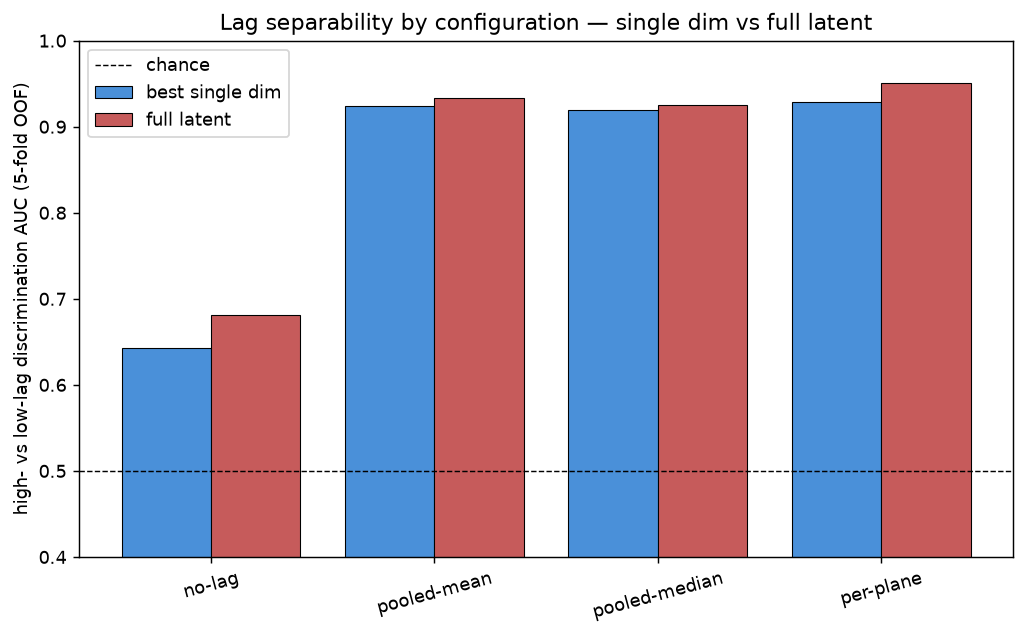

In [ ]:
x = np.arange(len(CONFIG_ORDER))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.2, [separ[n]["best_single"] for n in CONFIG_ORDER], 0.4, label="best single dim", color="#4a90d9", edgecolor="black", lw=.6)
ax.bar(x + 0.2, [separ[n]["full_latent"] for n in CONFIG_ORDER], 0.4, label="full latent", color="#c65b5b", edgecolor="black", lw=.6)
ax.axhline(0.5, color="k", ls="--", lw=.8, label="chance")

ax.set_xticks(x); ax.set_xticklabels(CONFIG_ORDER, rotation=15); ax.set_ylim(0.4, 1.0)
ax.set_ylabel("high- vs low-lag discrimination AUC (5-fold OOF)")
ax.set_title("Lag separability by configuration — single dim vs full latent"); ax.legend()
fig.tight_layout(); plt.savefig(f"{IMG_DIR}/lag_config_separability.png", dpi=130, bbox_inches="tight"); plt.show()

## 13k-3d.  Clinical separability — SGA status and birth percentile

The same separability test, now for **clinical groups**: how cleanly does each config's latent split SGA-confirmed vs not, and high vs low birth percentile? This asks whether the latent organizes the fetuses by outcome, not just by lag. Groups: SGA-confirmed (label vs rest) and birth-percentile outer tertiles (top vs bottom third). Metric is the same full-latent 5-fold OOF discrimination AUC.

**13k-3d-1.** Define the clinical groups (SGA-confirmed; birth-pct outer tertiles).

In [ ]:
sga_group = outcomes["SGA confirmed"]                    # 1 = SGA-confirmed, 0 = rest
sga_mask = np.isfinite(sga_group)

bp = birth_pct.copy()
bp_lo, bp_hi = np.nanpercentile(bp, [33.3, 66.7])
bp_group = np.where(bp >= bp_hi, 1, np.where(bp <= bp_lo, 0, np.nan))
bp_mask = np.isfinite(bp_group)
print(f"SGA-confirmed n={int(np.nansum(sga_group))}/{int(sga_mask.sum())} | "
      f"birth-pct high n={int((bp_group[bp_mask]==1).sum())} low n={int((bp_group[bp_mask]==0).sum())}")

**13k-3d-2.** Full-latent separability AUC for each target x configuration.

In [ ]:
separ_targets = {"appearance-lag": (lag_group, group_mask),
                 "SGA-confirmed": (sga_group, sga_mask),
                 "birth-pct (tertiles)": (bp_group, bp_mask)}

clinical_sep = {target: {name: round(separability_full(config_end[name], grp, msk), 3) for name in CONFIG_ORDER}
                for target, (grp, msk) in separ_targets.items()}
for target, row in clinical_sep.items():
    print(f"  {target:22s}", "  ".join(f"{name} {row[name]:.2f}" for name in CONFIG_ORDER))

**13k-3d-3.** Clinical-separability figure — one bar group per target.

In [ ]:
target_names = list(separ_targets)
x = np.arange(len(CONFIG_ORDER)); width = 0.26
target_colors = {"appearance-lag": "#4a90d9", "SGA-confirmed": "#c65b5b", "birth-pct (tertiles)": "#6aa84f"}

fig, ax = plt.subplots(figsize=(9, 5))
for k, target in enumerate(target_names):
    ax.bar(x + (k - 1) * width, [clinical_sep[target][n] for n in CONFIG_ORDER], width, label=target, color=target_colors[target], edgecolor="black", lw=.6)

ax.axhline(0.5, color="k", ls="--", lw=.8, label="chance"); ax.set_xticks(x); ax.set_xticklabels(CONFIG_ORDER, rotation=15)
ax.set_ylabel("full-latent discrimination AUC (5-fold OOF)"); ax.set_ylim(0.4, 1.0)
ax.set_title("Separability by target and configuration — lag vs clinical status"); ax.legend(fontsize=8)
fig.tight_layout(); plt.savefig(f"{IMG_DIR}/lag_config_clinical_separability.png", dpi=130, bbox_inches="tight"); plt.show()

## 13k-4.  Lag separation across gestation — not only term

The endpoint scatter (§13k-2) uses the final scan only. Here the *per-slot* latent is binned by GA window, so each row is a stage of pregnancy and each column a configuration. This shows whether the lag gradient is present throughout gestation or only appears at term. Color = reference lag; the per-panel |r| is lag-axis strength at that GA window.

**13k-4a.** For a GA window, gather each fetus's latent at its nearest in-window slot.

In [ ]:
GA_WINDOWS = [(20, 24), (24, 28), (28, 32), (32, 36), (36, 41)]
axes_for_scatter = {name: best_axes(config_end[name]) for name in CONFIG_ORDER}

def slot_ga(i, slot):
    return merged_seq[i, slot, -1] * 36 + 6

def latent_in_window(traj, lo, hi):
    rows = np.full((n_fetus, LATENT_DIM), np.nan)
    for i in range(n_fetus):
        in_win = [s for s in range(int(seq_len[i])) if lo <= slot_ga(i, s) < hi]
        if in_win:
            rows[i] = traj[i, in_win[-1]]
    return rows

**13k-4b.** The GA-window x configuration scatter grid (built in one cell).

In [ ]:
def window_points(name, lo, hi):
    lag_ax, size_ax = axes_for_scatter[name]
    rows = latent_in_window(config_traj[name], lo, hi)
    present = np.isfinite(rows[:, 0]) & has_reference
    panel_r = abs(pearsonr(rows[present, lag_ax], reference_mean_lag[present])[0]) if present.sum() > 5 else np.nan
    return rows[present, lag_ax], rows[present, size_ax], reference_mean_lag[present], panel_r, int(present.sum())

def draw_ga_panel(ax, name, lo, hi, top_row, left_col):
    xs, ys, colors, panel_r, n = window_points(name, lo, hi)
    sc = ax.scatter(xs, ys, c=colors, cmap="coolwarm", s=10, vmin=-4, vmax=4)
    if top_row: ax.set_title(name, fontsize=10)
    if left_col: ax.set_ylabel(f"GA {lo}-{hi} wk\nsize dim", fontsize=9)
    ax.set_xlabel(f"lag dim (|r|={panel_r:.2f}, n={n})", fontsize=8)
    return sc

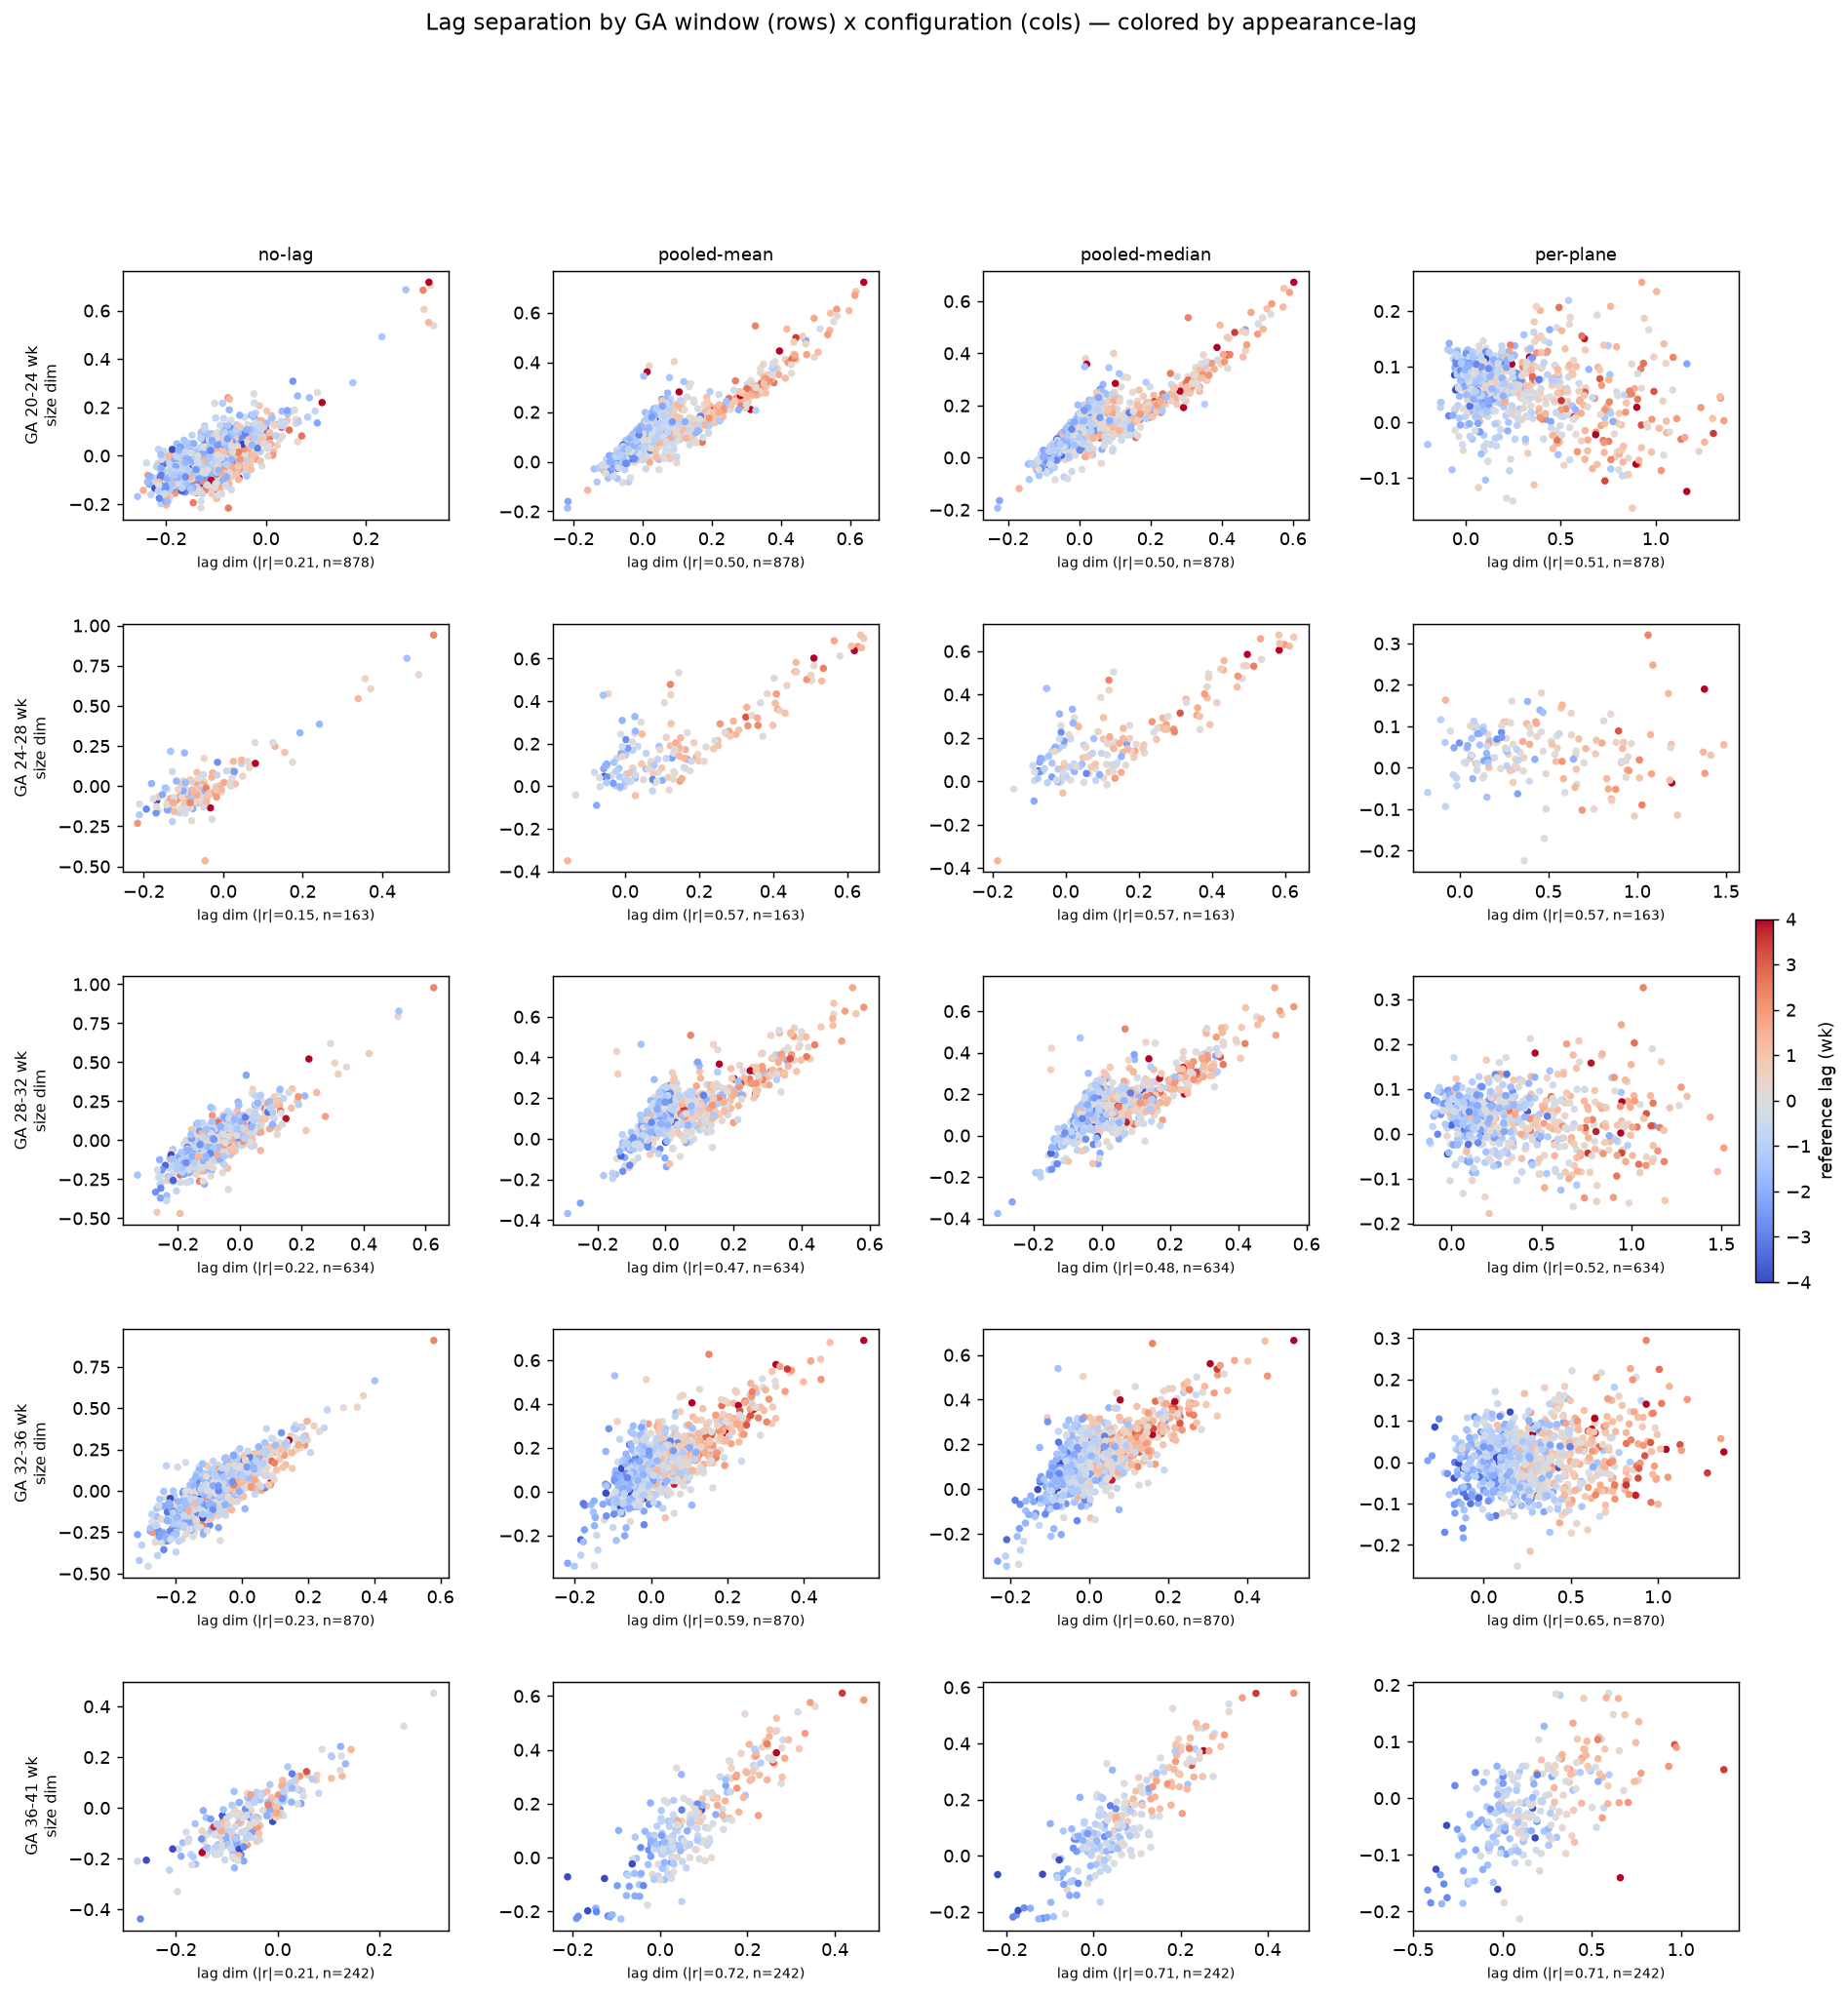

In [ ]:
fig, axes = plt.subplots(len(GA_WINDOWS), len(CONFIG_ORDER), figsize=(4.2 * len(CONFIG_ORDER), 3.4 * len(GA_WINDOWS)))
fig.subplots_adjust(wspace=0.32, hspace=0.42)

for r, (lo, hi) in enumerate(GA_WINDOWS):
    for c, name in enumerate(CONFIG_ORDER):
        sc = draw_ga_panel(axes[r, c], name, lo, hi, top_row=(r == 0), left_col=(c == 0))

fig.colorbar(sc, ax=axes, fraction=0.011, pad=0.01, label="reference lag (wk)")
fig.suptitle("Lag separation by GA window (rows) x configuration (cols) — colored by appearance-lag", y=1.00, fontsize=13)
plt.savefig(f"{IMG_DIR}/lag_config_scatter_by_ga.png", dpi=120, bbox_inches="tight"); plt.show()

**13k-4c.** The same GA-window x configuration grid, now **colored by birth percentile** (blue = low percentile / small, red = high). Same latent axes as the lag-colored grid above; the per-panel |r| is still lag-axis strength. Comparing the two grids shows whether the latent regions that separate by *lag* also separate by *birth-percentile*.

In [ ]:
def window_points_birthpct(name, lo, hi):
    lag_ax, size_ax = axes_for_scatter[name]
    rows = latent_in_window(config_traj[name], lo, hi)
    present = np.isfinite(rows[:, 0]) & np.isfinite(birth_pct)
    panel_r = abs(pearsonr(rows[present, lag_ax], reference_mean_lag[present])[0]) if present.sum() > 5 else np.nan
    return rows[present, lag_ax], rows[present, size_ax], birth_pct[present], panel_r, int(present.sum())

def draw_ga_panel_birthpct(ax, name, lo, hi, top_row, left_col):
    xs, ys, colors, panel_r, n = window_points_birthpct(name, lo, hi)
    sc = ax.scatter(xs, ys, c=colors, cmap="RdBu_r", s=10, vmin=0, vmax=100)
    if top_row: ax.set_title(name, fontsize=10)
    if left_col: ax.set_ylabel(f"GA {lo}-{hi} wk\nsize dim", fontsize=9)
    ax.set_xlabel(f"lag dim (|r|={panel_r:.2f}, n={n})", fontsize=8)
    return sc

In [ ]:
fig, axes = plt.subplots(len(GA_WINDOWS), len(CONFIG_ORDER), figsize=(4.2 * len(CONFIG_ORDER), 3.4 * len(GA_WINDOWS)))
fig.subplots_adjust(wspace=0.32, hspace=0.42)

for r, (lo, hi) in enumerate(GA_WINDOWS):
    for c, name in enumerate(CONFIG_ORDER):
        sc = draw_ga_panel_birthpct(axes[r, c], name, lo, hi, top_row=(r == 0), left_col=(c == 0))

fig.colorbar(sc, ax=axes, fraction=0.011, pad=0.01, label="birth percentile")
fig.suptitle("Latent by GA window (rows) x configuration (cols) — colored by birth percentile", y=1.00, fontsize=13)
plt.savefig(f"{IMG_DIR}/lag_config_scatter_by_ga_birthpct.png", dpi=120, bbox_inches="tight"); plt.show()

**13l.** Reading the study.

- **With-lag vs no-lag** — panel C (§13i) and the loadings/scatter plots (§13k): only the with-lag configs put a real lag axis in the latent (|r| ≈ 0.62–0.70) and show a clear lag gradient in the scatter; no-lag has no such dimension (|r| ≈ 0.21) and no gradient. The lag axis genuinely requires the lag input.
- **The outcome lift diverges by target.** SGA (§13i-2a/b/c, one figure per definition): the dynamics-lift is present for all three SGA definitions, strongest and most cutoff-dependent for **SGA-confirmed**, smaller and flatter for **SGA <p10** and **severe SGA** where the pooled-lag advantage over no-lag largely washes out. All SGA configs are positive and (mostly) significant at term, so the lift generalizes across definitions. Birth-percentile (panel B): **no-lag is markedly higher** (dR² +0.057, P=1.00) than every lag config, so lag adds no birth-pct predictive signal — the lift there is carried by biometry-trajectory dynamics, and lag's role is representational (it defines an axis), not predictive.
- **Pooled vs per-plane** — pooled concentrates lag into one strong axis; per-plane gives the strongest lag axis (|r| 0.70) and best SGA-confirmed dAUC but splits birth-pct signal across three sparser channels, collapsing it to ≈ 0.
- **Mean vs median pooling** — a small robustness choice; median trims per-visit outliers, mean keeps them. Compare the two pooled curves directly.
- **Lag vs clinical separability (§13k-3d)** — separability of *lag groups* is high for lag-fed configs (a direct consequence of the lag input); separability of *SGA / birth-percentile* groups tests whether the latent also organizes by outcome. Compare the three bar groups: if clinical separability is much lower than lag separability, the latent encodes the appearance-lag axis more cleanly than it separates growth outcomes.

## 15.  Multitask image VAE — architecture (train it yourself)

An **additive experiment** (canonical config-B untouched): a `MultiTaskSeqVAE` over sequential USFM *image* features, with a **per-slot GA head** and a **learnable α over layers**. Rationale: IG-21 biometry z-scores have GA normalised out, so a GA head is only meaningful on *image* features (images are the sole maturation clock). GA is the **target**, never an input — no leakage.

Three stages: (A) attention-pool the 196 patch tokens → one vector per image; (B) median-aggregate images → one vector per GA-week slot; (C) GRU-VAE over the slot sequence with recon + β·KL + λ·GA. This cell block **defines** everything with logging; the RUN-ME cell at the end is left commented so you train it yourself.

**15a.** Architecture — patch attention pool, and the multitask sequence VAE (learnable α over layers).

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F

class PatchAttentionPool(nn.Module):
    """Learned attention over the 196 USFM patch tokens -> one vector per image."""
    def __init__(self, dim=768, attn_hidden=128):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(dim, attn_hidden), nn.Tanh(), nn.Linear(attn_hidden, 1))

    def forward(self, patches):                       # patches: (batch, 196, dim)
        weights = torch.softmax(self.score(patches).squeeze(-1), dim=1)
        pooled = (weights.unsqueeze(-1) * patches).sum(1)
        return pooled, weights

In [2]:
class MultiTaskSeqVAE(nn.Module):
    """GRU-VAE over per-slot image features + per-slot GA head. GA is the target, never an input.
       n_layers>1 adds a learnable softmax alpha that fuses stacked layers (l0,l5,l11) per slot."""
    def __init__(self, input_dim, hidden=32, latent=8, n_layers=1, alpha_init=None):
        super().__init__()

        # alpha_init seeds raw_alpha = log(prior) so softmax(raw_alpha)=prior (e.g. Shapley layer weights
        # [l0,l5,l11]=[0.21,0.40,0.40]); default zeros -> uniform. Only active when n_layers>1.
        seed = (torch.log(torch.tensor(alpha_init, dtype=torch.float32))
                if (alpha_init is not None and n_layers > 1) else torch.zeros(max(n_layers, 1)))
        self.raw_alpha = nn.Parameter(seed) if n_layers > 1 else None
        self.gru = nn.GRU(input_dim, hidden, batch_first=True)

        self.to_mean, self.to_logvar = nn.Linear(hidden, latent), nn.Linear(hidden, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(), nn.Linear(hidden, input_dim))
        self.ga_head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Linear(hidden // 2, 1))

    def fuse_layers(self, x):                          # x: (b, seq, n_layers, dim) -> (b, seq, dim)
        alpha = torch.softmax(self.raw_alpha, dim=0)
        return (alpha.view(1, 1, -1, 1) * x).sum(2), alpha

    def reparameterize(self, mean, logvar):
        return mean + torch.randn_like(logvar) * (0.5 * logvar).exp()

    def forward(self, x):                              # x: (b, seq, dim) or (b, seq, n_layers, dim)
        alpha = None
        if x.dim() == 4:
            x, alpha = self.fuse_layers(x)

        slot_states, hidden_state = self.gru(x)
        mean, logvar = self.to_mean(hidden_state[-1]), self.to_logvar(hidden_state[-1])
        z = self.reparameterize(mean, logvar)
        return self.decoder(z), self.ga_head(slot_states).squeeze(-1), mean, logvar, alpha

#### Seeding the learnable α with the Shapley layer prior

The exact-Shapley attribution of the GA clock across USFM layers (§ layer-attribution, `layer_shapley.json`) gives
`{l0: 0.21, l5: 0.40, l11: 0.40}`. Passing it as `alpha_init` starts the model's learnable α at that prior
(`softmax(raw_alpha) = prior`) instead of uniform, so training refines a data-grounded weighting rather than
discovering it from scratch. After training, compare the learned α to this prior as a sanity check.

In [ ]:
# instantiate the multilayer model with the Shapley layer prior (l0, l5, l11)
SHAPLEY_ALPHA = [0.206, 0.397, 0.397]   # from layer_shapley.json (exact Shapley of GA-clock R^2)
model = MultiTaskSeqVAE(input_dim=768, hidden=64, latent=8, n_layers=3, alpha_init=SHAPLEY_ALPHA)

import torch
print("initial alpha (softmax of seeded raw_alpha):",
      torch.softmax(model.raw_alpha, 0).detach().numpy().round(3))

In [3]:
demo = MultiTaskSeqVAE(input_dim=768, hidden=32, latent=8, n_layers=3)
n_params = sum(p.numel() for p in demo.parameters())
print(f"MultiTaskSeqVAE(input_dim=768, hidden=32, latent=8, n_layers=3): {n_params:,} params")
print("  heads: decoder(recon) + ga_head(per-slot GA) + to_mean/to_logvar(latent); alpha over 3 layers")
print(f"  PatchAttentionPool(768): {sum(p.numel() for p in PatchAttentionPool().parameters()):,} params")

MultiTaskSeqVAE(input_dim=768, hidden=32, latent=8, n_layers=3): 103,700 params
  heads: decoder(recon) + ga_head(per-slot GA) + to_mean/to_logvar(latent); alpha over 3 layers
  PatchAttentionPool(768): 98,561 params


**15b.** Multitask loss — reconstruction + β·KL + λ·(per-slot GA MSE, masked to real slots).

**Scale note:** GA is in weeks (target ~6–42), so the raw GA-MSE is ~10²–10³× the feature reconstruction (features are normalised, recon ≈ 0.2–0.3). With `lam=1.0` the GA head dominates the loss. Either normalise the GA target (e.g. `(ga-6)/36`, matching `GA_norm` elsewhere) or use a small `lam` (≈1e-3–1e-2) so recon/KL still shape the latent. Start by watching the three printed loss terms and tune `lam` until they are comparable.

In [4]:
def multitask_loss(recon, target_recon, pred_ga, target_ga, ga_mask, mean, logvar, beta=0.1, lam=1.0):
    recon_loss = F.mse_loss(recon, target_recon)
    kl = -0.5 * torch.mean(1 + logvar - mean.pow(2) - logvar.exp())
    ga_err = (pred_ga - target_ga)[ga_mask]                       # only real (non-padded) slots
    ga_loss = (ga_err ** 2).mean() if ga_err.numel() else torch.zeros((), device=recon.device)
    total = recon_loss + beta * kl + lam * ga_loss
    return total, dict(recon=recon_loss.item(), kl=kl.item(), ga=float(ga_loss))

**15c.** Data prep — stream the USB patch grids (one shard at a time, logged), pool to per-image vectors, then median-aggregate to per-GA-week slots. `pooler` is any callable `(batch,196,768)->(batch,768)`: `mean_pooler` for the baseline, or a trained `PatchAttentionPool` (wrap as `lambda g: attn(g)[0]`).

In [22]:
USB_GRIDS = "/Users/tiago/usb/patchgrids"
LAYER_FILES = {"l0": "b0", "l5": "b5", "l11": "b11"}
N_SHARDS = 31
mean_pooler = lambda patches: patches.mean(1)                     # baseline pooler over 196 patches

def load_shard(prefix, s, in_cohort_only=True):
    z = np.load(f"{USB_GRIDS}/{prefix}_grid_{s:04d}.npz", allow_pickle=True)
    keep = z["in_cohort"].astype(bool) if in_cohort_only else np.ones(len(z["grid"]), bool)
    grid = torch.from_numpy(z["grid"][keep].astype("float32"))
    return grid, (z["new_filename"][keep], z["fetus_id"][keep], z["ga_weeks_recovered"][keep])

In [6]:
def stream_layer_pooled(layer_key, pooler, in_cohort_only=True, log_every=1):
    prefix = LAYER_FILES[layer_key]
    feats, names, fids, gas = [], [], [], []

    for s in range(N_SHARDS):
        grid, (nm, fi, ga) = load_shard(prefix, s, in_cohort_only)
        with torch.no_grad():
            pooled = pooler(grid).cpu().numpy()
        feats.append(pooled); names.append(nm); fids.append(fi); gas.append(ga)
        if s % log_every == 0: print(f"  {layer_key} shard {s+1}/{N_SHARDS}  images so far={sum(map(len, feats))}")

    print(f"  {layer_key} done: {sum(map(len, feats))} images pooled")
    return np.concatenate(feats), np.concatenate(names), np.concatenate(fids), np.concatenate(gas)

In [7]:
def fill_fetus(frame, features, fid, max_t, dim):
    weeks = sorted(frame[frame.fid == fid].gaw.unique())[:max_t]
    row_seq = np.zeros((max_t, dim), np.float32)
    row_ga, row_mask = np.zeros(max_t, np.float32), np.zeros(max_t, bool)

    for t, w in enumerate(weeks):
        rows = frame[(frame.fid == fid) & (frame.gaw == w)].row.values
        row_seq[t] = np.median(features[rows], 0); row_ga[t] = w; row_mask[t] = True
    return row_seq, row_ga, row_mask

In [8]:
def build_image_sequences(features, fids, gas, max_t=12):
    gaw = np.round(np.asarray(gas, float)).astype(int)
    valid = (gaw >= GA_MIN) & (gaw <= GA_MAX)
    frame = pd.DataFrame(dict(fid=np.asarray(fids)[valid], gaw=gaw[valid], row=np.arange(len(features))[valid]))
    fetus_ids = sorted(frame.fid.unique())
    dim = features.shape[1]

    seq = np.zeros((len(fetus_ids), max_t, dim), np.float32)
    ga = np.zeros((len(fetus_ids), max_t), np.float32)
    mask = np.zeros((len(fetus_ids), max_t), bool)
    for i, fid in enumerate(fetus_ids):
        seq[i], ga[i], mask[i] = fill_fetus(frame, features, fid, max_t, dim)
    print(f"built sequences: {seq.shape}  fetuses={len(fetus_ids)}  mean real slots/fetus={mask.sum(1).mean():.1f}")
    return seq, ga, mask, fetus_ids

**15d.** Training loop — logs recon / KL / GA loss each few epochs and held-out GA correlation.

In [9]:
def recon_target(seq_t, mask_t):
    x = seq_t.mean(2) if seq_t.dim() == 4 else seq_t              # mean over layers if stacked
    m = mask_t.unsqueeze(-1).float()
    return (x * m).sum(1) / m.sum(1).clamp(min=1)                 # reconstruct the masked seq-mean

def val_ga_r(model, seq_t, ga_t, mask_t, val):
    model.eval()
    with torch.no_grad():
        _, pred_ga, _, _, _ = model(seq_t[val])
    m = mask_t[val]
    return pearsonr(pred_ga[m].numpy(), ga_t[val][m].numpy())[0]

In [10]:
def epoch_step(model, opt, seq_t, ga_t, mask_t, tr, beta, lam):
    model.train(); opt.zero_grad()
    recon, pred_ga, mean, logvar, alpha = model(seq_t[tr])
    total, parts = multitask_loss(recon, recon_target(seq_t[tr], mask_t[tr]),
                                  pred_ga, ga_t[tr], mask_t[tr], mean, logvar, beta, lam)
    total.backward(); opt.step()
    return parts, alpha

In [11]:
def train_multitask(model, seq, ga, mask, epochs=100, lr=1e-3, beta=0.1, lam=1.0, val_frac=0.2, seed=0):
    rng = np.random.default_rng(seed); idx = rng.permutation(len(seq))
    n_val = int(len(seq) * val_frac); val, tr = idx[:n_val], idx[n_val:]
    seq_t, ga_t = torch.tensor(seq), torch.tensor(ga)
    mask_t = torch.tensor(mask).bool()
    opt = torch.optim.Adam(model.parameters(), lr=lr); log = []
    print(f"train n={len(tr)}  val n={len(val)}  epochs={epochs}  beta={beta}  lam={lam}")

    for ep in range(epochs):
        parts, alpha = epoch_step(model, opt, seq_t, ga_t, mask_t, tr, beta, lam)

        if ep % 10 == 0 or ep == epochs - 1:
            r = val_ga_r(model, seq_t, ga_t, mask_t, val)
            a = None if alpha is None else np.round(alpha.detach().numpy(), 3).tolist()
            print(f"epoch {ep:3d}  recon={parts['recon']:.4f}  kl={parts['kl']:.4f}  ga={parts['ga']:.3f}  valGAr={r:.3f}  alpha={a}")
            log.append(dict(epoch=ep, **parts, val_ga_r=r, alpha=a))
    return log

**15e.** RUN ME (train yourself). Uncomment to run — stage 1 streams the USB patch grids (~17 GB per layer, one shard at a time). Swap `mean_pooler` for a trained `PatchAttentionPool` to use learned patch attention; pass `n_layers=3` with a stacked (b,seq,3,768) sequence to learn α over layers.

In [23]:
# ---- stage 1: pool patches -> per-image features (mean pooler; streams USB) ----
feats_l5, names, fids_img, gas_img = stream_layer_pooled("l5", mean_pooler)

# ---- stage 2: per-image -> per-GA-week slot sequences ----
img_seq, img_ga, img_mask, seq_fids = build_image_sequences(feats_l5, fids_img, gas_img)

# ---- stage 3: instantiate + train the multitask VAE ----
model = MultiTaskSeqVAE(input_dim=img_seq.shape[-1], hidden=32, latent=8, n_layers=1)
history = train_multitask(model, img_seq, img_ga, img_mask, epochs=1000, beta=0.1, lam=1.0)

print("Architecture, loss, data-prep, and training loop defined. Uncomment the stages above to train.")

  l5 shard 1/31  images so far=2048
  l5 shard 2/31  images so far=4096
  l5 shard 3/31  images so far=6144
  l5 shard 4/31  images so far=8192
  l5 shard 5/31  images so far=10240
  l5 shard 6/31  images so far=12288
  l5 shard 7/31  images so far=14336
  l5 shard 8/31  images so far=16384
  l5 shard 9/31  images so far=18432
  l5 shard 10/31  images so far=20480
  l5 shard 11/31  images so far=22528
  l5 shard 12/31  images so far=24576
  l5 shard 13/31  images so far=26624
  l5 shard 14/31  images so far=28672
  l5 shard 15/31  images so far=30720
  l5 shard 16/31  images so far=32768
  l5 shard 17/31  images so far=34816
  l5 shard 18/31  images so far=36864
  l5 shard 19/31  images so far=38912
  l5 shard 20/31  images so far=40960
  l5 shard 21/31  images so far=43008
  l5 shard 22/31  images so far=45056
  l5 shard 23/31  images so far=47104
  l5 shard 24/31  images so far=49152
  l5 shard 25/31  images so far=51200
  l5 shard 26/31  images so far=53248
  l5 shard 27/31  images 

/var/folders/55/c2951swj511fc1pgg7p8typh0000gn/T/ipykernel_15753/740011816.py:2: RuntimeWarning: invalid value encountered in cast
  gaw = np.round(np.asarray(gas, float)).astype(int)


built sequences: (908, 12, 768)  fetuses=908  mean real slots/fetus=3.2
train n=727  val n=181  epochs=100  beta=0.1  lam=1.0
epoch   0  recon=3.6132  kl=0.0156  ga=803.076  valGAr=0.559  alpha=None
epoch  10  recon=3.4066  kl=0.0151  ga=758.433  valGAr=0.476  alpha=None
epoch  20  recon=3.2058  kl=0.0198  ga=730.402  valGAr=0.420  alpha=None
epoch  30  recon=2.9775  kl=0.0334  ga=701.668  valGAr=0.189  alpha=None
epoch  40  recon=2.7189  kl=0.0735  ga=671.992  valGAr=0.168  alpha=None
epoch  50  recon=2.3798  kl=0.2205  ga=639.896  valGAr=0.156  alpha=None
epoch  60  recon=2.0279  kl=0.7127  ga=605.576  valGAr=0.151  alpha=None
epoch  70  recon=1.7634  kl=0.7282  ga=569.274  valGAr=0.145  alpha=None
epoch  80  recon=1.4836  kl=1.0585  ga=531.011  valGAr=0.131  alpha=None
epoch  90  recon=1.1792  kl=1.4071  ga=484.207  valGAr=0.142  alpha=None
epoch  99  recon=0.9264  kl=1.8799  ga=442.201  valGAr=0.130  alpha=None
Architecture, loss, data-prep, and training loop defined. Uncomment the

In [24]:
model = MultiTaskSeqVAE(input_dim=img_seq.shape[-1], hidden=64, latent=8, n_layers=4)
history = train_multitask(model, img_seq, img_ga, img_mask, epochs=1000, beta=0.1, lam=1.0)

train n=727  val n=181  epochs=1000  beta=0.1  lam=1.0
epoch   0  recon=3.6615  kl=0.0072  ga=814.077  valGAr=0.643  alpha=None
epoch  10  recon=3.2881  kl=0.0074  ga=737.290  valGAr=0.414  alpha=None
epoch  20  recon=2.9462  kl=0.0125  ga=674.036  valGAr=0.412  alpha=None
epoch  30  recon=2.5637  kl=0.0505  ga=600.645  valGAr=0.239  alpha=None
epoch  40  recon=2.0957  kl=0.4606  ga=514.166  valGAr=0.384  alpha=None
epoch  50  recon=1.7557  kl=0.5981  ga=415.562  valGAr=0.217  alpha=None
epoch  60  recon=1.4060  kl=1.1139  ga=320.676  valGAr=0.197  alpha=None
epoch  70  recon=1.1046  kl=1.4873  ga=231.619  valGAr=0.223  alpha=None
epoch  80  recon=0.7857  kl=2.1916  ga=158.440  valGAr=0.192  alpha=None
epoch  90  recon=0.5398  kl=2.6053  ga=106.560  valGAr=0.146  alpha=None
epoch 100  recon=0.3804  kl=2.6256  ga=76.640  valGAr=0.157  alpha=None
epoch 110  recon=0.2878  kl=2.4510  ga=63.305  valGAr=0.247  alpha=None
epoch 120  recon=0.2227  kl=2.3239  ga=56.849  valGAr=0.639  alpha=None

In [25]:
from scipy.stats import pearsonr

def latent_endpoint(model, seq):
    model.eval()
    with torch.no_grad():
        _, hidden_state = model.gru(torch.tensor(seq))
        return model.to_mean(hidden_state[-1]).numpy()

def latent_trajectory(model, seq):
    model.eval()
    with torch.no_grad():
        slot_states, _ = model.gru(torch.tensor(seq))
        return model.to_mean(slot_states).numpy()

In [26]:
end_latent = latent_endpoint(model, img_seq)          # (n_fetus, 8)  endpoint code
traj_latent = latent_trajectory(model, img_seq)        # (n_fetus, 12, 8)  per-slot path
with torch.no_grad():
    _, pred_ga_all, _, _, _ = model(torch.tensor(img_seq))
pred_ga_all = pred_ga_all.numpy()                       # (n_fetus, 12)  learned clock
print(f"endpoint {end_latent.shape}  trajectory {traj_latent.shape}  clock {pred_ga_all.shape}")

endpoint (908, 8)  trajectory (908, 12, 8)  clock (908, 12)


In [33]:
# birth_pct aligned to seq_fids — normalize BOTH ids through int (patchgrid ids are '1198.0', Cod is '1198')
def norm_id(x):
    try: return str(int(float(x)))
    except: return str(x)

outc = pd.read_csv("/Users/tiago/PythonProject/fetal_growth_mechanism/data/impact_outcomes.csv")
bp_map = dict(zip(outc.Cod.map(norm_id), outc.percentil_birth))
birth_pct = np.array([bp_map.get(norm_id(f), np.nan) for f in seq_fids], float)
print(f"birth pct matched: {np.isfinite(birth_pct).sum()}/{len(birth_pct)}")

birth pct matched: 906/908


In [34]:
def endpoint_clock(pred_ga, mask):                     # clock reading at each fetus's last real slot
    last = np.array([np.where(m)[0][-1] if m.any() else 0 for m in mask])
    return pred_ga[np.arange(len(pred_ga)), last]

def pick_axis(latent, target):                         # latent dim most correlated with target
    ok = np.isfinite(target)
    rs = [abs(pearsonr(latent[ok, d], target[ok])[0]) for d in range(latent.shape[1])]
    return int(np.argmax(rs)), float(max(rs))

In [35]:
clock_end = endpoint_clock(pred_ga_all, img_mask)
mat_ax, mat_r = pick_axis(end_latent, clock_end)       # maturation axis (tracks the learned GA clock)
bp_ax, bp_r = pick_axis(end_latent, birth_pct)         # birth-pct axis
rem = [d for d in range(end_latent.shape[1]) if d not in (mat_ax, bp_ax)]
third = rem[int(np.argmax([end_latent[:, d].std() for d in rem]))]
print(f"maturation axis z{mat_ax} (|r|={mat_r:.2f})  birth-pct axis z{bp_ax} (|r|={bp_r:.2f})  third z{third}")

maturation axis z3 (|r|=0.50)  birth-pct axis z0 (|r|=0.07)  third z6


In [36]:
GA_GRID = list(range(20, 40, 2))

def decile_paths(traj, img_ga, mask, birth_pct, axes, grid=GA_GRID):
    deciles = np.clip((birth_pct // 10).astype(int), 0, 9)
    out = {}
    for dcl in range(10):
        idx = np.where((deciles == dcl) & np.isfinite(birth_pct))[0]
        xs, ys, zs = [], [], []
        for g in grid:
            rows = [traj[i, np.where(mask[i])[0][np.argmin(np.abs(img_ga[i][mask[i]] - g))]]
                    for i in idx if mask[i].any()
                    and abs(img_ga[i][mask[i]][np.argmin(np.abs(img_ga[i][mask[i]] - g))] - g) <= 1]

            if rows:
                m = np.mean(rows, 0); xs.append(m[axes[0]]); ys.append(m[axes[1]]); zs.append(m[axes[2]])
        out[dcl] = (xs, ys, zs)
    return out

In [37]:
import plotly.graph_objects as go

axes = (mat_ax, bp_ax, third)
paths = decile_paths(traj_latent, img_ga, img_mask, birth_pct, axes)
fig = go.Figure()
for dcl, (xs, ys, zs) in paths.items():
    if xs:
        col = f"rgb({int(255*(1-dcl/9))},{int(80+dcl*10)},{int(255*dcl/9)})"
        fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode="lines+markers",
                                   line=dict(width=6, color=col), marker=dict(size=3),
                                   name=f"decile {dcl*10}-{dcl*10+10}"))

/var/folders/55/c2951swj511fc1pgg7p8typh0000gn/T/ipykernel_15753/3231635729.py:4: RuntimeWarning: invalid value encountered in cast
  deciles = np.clip((birth_pct // 10).astype(int), 0, 9)


In [38]:
fig.update_layout(title="Multitask image VAE — decile mean paths (birth pct)",
                  scene=dict(xaxis_title=f"maturation z{mat_ax}",
                             yaxis_title=f"birth-pct z{bp_ax}", zaxis_title=f"z{third}"),
                  width=950, height=720)
fig.write_html(f"{IMG_DIR}/multitask_image_vae_meanpaths.html")
fig.show()

In [41]:
class MaturationSeqVAE(nn.Module):
    """Sequence VAE specialised for maturation. Over MultiTaskSeqVAE it adds:
       (1) a temporal position embedding from each slot's GA (the model sees visit gaps),
       (2) an optional monotonic Delta-GA head (softplus increments -> cumsum) that enforces
       a strictly non-decreasing clock and smooths single-visit drops from poor frames."""
    def __init__(self, input_dim, hidden=32, latent=8, n_layers=1, delta_ga=False):
        super().__init__()

        self.delta_ga = delta_ga
        self.raw_alpha = nn.Parameter(torch.zeros(n_layers)) if n_layers > 1 else None
        self.time_embed = nn.Sequential(nn.Linear(1, input_dim), nn.Tanh())
        self.gru = nn.GRU(input_dim, hidden, batch_first=True)

        self.to_mean, self.to_logvar = nn.Linear(hidden, latent), nn.Linear(hidden, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(), nn.Linear(hidden, input_dim))
        self.ga_head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Linear(hidden // 2, 1))

    def fuse_layers(self, x):                          # (b, seq, n_layers, dim) -> (b, seq, dim)
        alpha = torch.softmax(self.raw_alpha, dim=0)
        return (alpha.view(1, 1, -1, 1) * x).sum(2), alpha

    def add_time(self, x, ga_norm):                    # ga_norm (b,seq) in [0,1]: add a position offset
        return x + self.time_embed(ga_norm.unsqueeze(-1))

    def reparameterize(self, mean, logvar):
        return mean + torch.randn_like(logvar) * (0.5 * logvar).exp()

    def read_ga(self, slot_states, ga0):               # absolute, or monotonic cumulative from deltas
        raw = self.ga_head(slot_states).squeeze(-1)
        if not self.delta_ga:
            return raw
        deltas = F.softplus(raw)                        # non-negative increments -> non-decreasing GA
        return ga0.unsqueeze(1) + torch.cumsum(deltas, dim=1) - deltas[:, :1]

    def forward(self, x, ga_norm=None, ga0=None):
        alpha = torch.softmax(self.raw_alpha, dim=0) if self.raw_alpha is not None else None
        if x.dim() == 4: x, alpha = self.fuse_layers(x)
        if ga_norm is not None: x = self.add_time(x, ga_norm)

        slot_states, hidden_state = self.gru(x)
        mean, logvar = self.to_mean(hidden_state[-1]), self.to_logvar(hidden_state[-1])
        z = self.reparameterize(mean, logvar)
        pred_ga = self.read_ga(slot_states, ga0 if ga0 is not None else torch.zeros(len(x)))
        return self.decoder(z), pred_ga, mean, logvar, alpha

    @torch.no_grad()
    def encode_maturation(self, x, ga_norm=None):      # endpoint latent (per-fetus summary)
        self.eval()
        if x.dim() == 4: x, _ = self.fuse_layers(x)
        if ga_norm is not None: x = self.add_time(x, ga_norm)
        _, h = self.gru(x); return self.to_mean(h[-1]).cpu().numpy()

    @torch.no_grad()
    def encode_trajectory(self, x, ga_norm=None):      # latent at every slot (the path)
        self.eval()
        if x.dim() == 4: x, _ = self.fuse_layers(x)
        if ga_norm is not None: x = self.add_time(x, ga_norm)
        s, _ = self.gru(x); return self.to_mean(s).cpu().numpy()

In [42]:
def maturation_targets(img_ga, img_mask):
    ga_norm = (img_ga - GA_MIN) / (GA_MAX - GA_MIN)              # [0,1] target scale
    ga0 = np.array([img_ga[i][img_mask[i]][0] if img_mask[i].any() else GA_MIN
                    for i in range(len(img_ga))], np.float32)     # first real GA per fetus
    return ga_norm.astype(np.float32), ga0

In [44]:
def train_maturation(model, seq, ga, mask, epochs=1000, lr=1e-3, beta=0.1, lam=1e-2,
                     val_frac=0.2, seed=0):
    ga_norm, ga0 = maturation_targets(ga, mask)
    rng = np.random.default_rng(seed); idx = rng.permutation(len(seq))
    n_val = int(len(seq) * val_frac); val, tr = idx[:n_val], idx[n_val:]
    seq_t, gan_t, ga0_t = torch.tensor(seq), torch.tensor(ga_norm), torch.tensor(ga0)
    ga_t, mask_t = torch.tensor(ga), torch.tensor(mask).bool()

    opt = torch.optim.Adam(model.parameters(), lr=lr); log = []
    print(f"train n={len(tr)}  val n={len(val)}  epochs={epochs}  lam={lam}  delta_ga={model.delta_ga}")
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        recon, pred_ga, mean, logvar, alpha = model(seq_t[tr], gan_t[tr], ga0_t[tr])
        tgt_ga = ga_t[tr] if model.delta_ga else gan_t[tr]         # delta head reads weeks; else normed
        total, parts = multitask_loss(recon, recon_target(seq_t[tr], mask_t[tr]),
                                      pred_ga, tgt_ga, mask_t[tr], mean, logvar, beta, lam)

        total.backward(); opt.step()

        if ep % 10 == 0 or ep == epochs - 1:
            model.eval()
            with torch.no_grad():
                _, pg, _, _, _ = model(seq_t[val], gan_t[val], ga0_t[val])
            pg_weeks = pg if model.delta_ga else pg * (GA_MAX - GA_MIN) + GA_MIN
            m = mask_t[val]; r = pearsonr(pg_weeks[m].numpy(), ga_t[val][m].numpy())[0]
            a = None if alpha is None else np.round(alpha.detach().numpy(), 3).tolist()

            print(f"epoch {ep:4d}  recon={parts['recon']:.4f}  kl={parts['kl']:.4f}  ga={parts['ga']:.3f}  valGAr={r:.3f}  alpha={a}")
            log.append(dict(epoch=ep, **parts, val_ga_r=r, alpha=a))
    return log

In [66]:
# stages 1-2 as before: feats_l5 -> img_seq, img_ga, img_mask, seq_fids
mat_model = MaturationSeqVAE(input_dim=img_seq.shape[-1], hidden=64, latent=32, n_layers=1, delta_ga=True)
mat_history = train_maturation(mat_model, img_seq, img_ga, img_mask, epochs=1000, lam=1e-2)
print("MaturationSeqVAE + training loop defined. Uncomment to train the monotonic maturation clock.")

train n=727  val n=181  epochs=1000  lam=0.01  delta_ga=True
epoch    0  recon=3.5949  kl=0.1409  ga=110.224  valGAr=0.506  alpha=None
epoch   10  recon=2.9632  kl=0.3724  ga=75.150  valGAr=0.632  alpha=None
epoch   20  recon=2.0715  kl=0.9612  ga=50.211  valGAr=0.720  alpha=None
epoch   30  recon=1.4597  kl=1.1316  ga=31.986  valGAr=0.757  alpha=None
epoch   40  recon=1.0447  kl=1.4822  ga=32.070  valGAr=0.753  alpha=None
epoch   50  recon=0.6626  kl=1.7841  ga=30.899  valGAr=0.757  alpha=None
epoch   60  recon=0.3440  kl=2.1407  ga=30.819  valGAr=0.761  alpha=None
epoch   70  recon=0.1933  kl=2.1379  ga=30.447  valGAr=0.761  alpha=None
epoch   80  recon=0.1441  kl=1.8001  ga=30.185  valGAr=0.762  alpha=None
epoch   90  recon=0.1162  kl=1.5789  ga=29.821  valGAr=0.766  alpha=None
epoch  100  recon=0.0998  kl=1.4211  ga=29.168  valGAr=0.771  alpha=None
epoch  110  recon=0.0964  kl=1.2734  ga=28.262  valGAr=0.776  alpha=None
epoch  120  recon=0.0897  kl=1.1805  ga=26.993  valGAr=0.784  

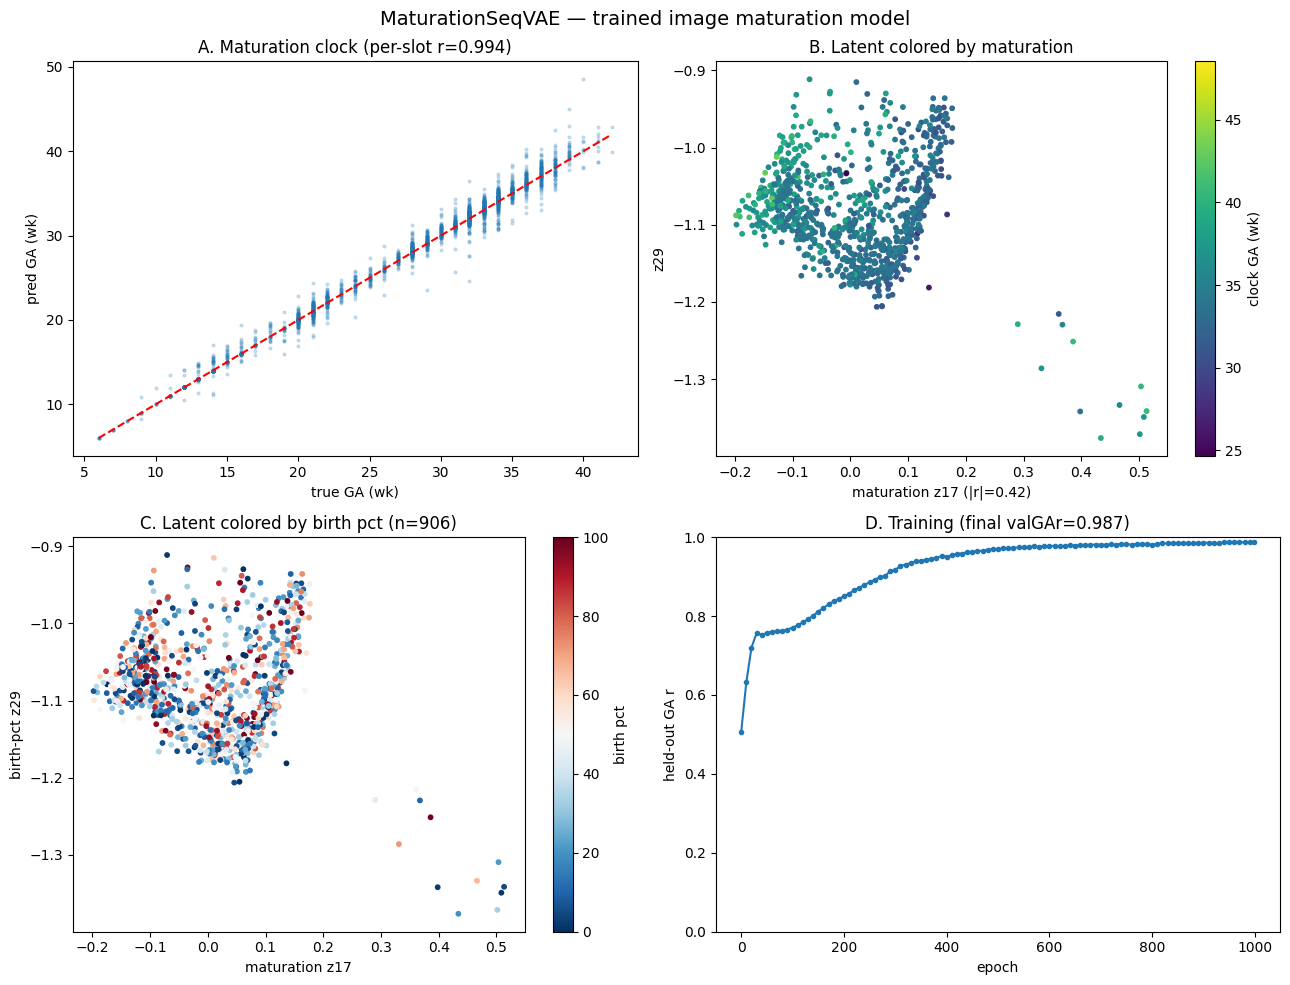

maturation axis z17 |r|=0.42 | birth-pct axis z29 |r|=0.07 | per-slot clock r=0.994


In [67]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def norm_id(x):
    try: return str(int(float(x)))
    except: return str(x)

# --- extract latent, trajectory, and the learned clock (pass tensors) ---
ga_norm = ((img_ga - GA_MIN) / (GA_MAX - GA_MIN)).astype("float32")
end = mat_model.encode_maturation(torch.tensor(img_seq), torch.tensor(ga_norm))
with torch.no_grad():
    ga0 = torch.tensor([img_ga[i][img_mask[i]][0] if img_mask[i].any() else GA_MIN
                        for i in range(len(img_ga))])
    _, pred_ga, _, _, _ = mat_model(torch.tensor(img_seq), torch.tensor(ga_norm), ga0)

    pred_ga = pred_ga.numpy()

# --- birth pct (normalized id join) + axis picks + endpoint readouts ---
outc = pd.read_csv("/Users/tiago/PythonProject/fetal_growth_mechanism/data/impact_outcomes.csv")
bp_map = dict(zip(outc.Cod.map(norm_id), outc.percentil_birth))
birth_pct = np.array([bp_map.get(norm_id(f), np.nan) for f in seq_fids], float)

def endpoint_val(a, m):
    last = np.array([np.where(x)[0][-1] if x.any() else 0 for x in m])
    return a[np.arange(len(a)), last]

def pick(latent, tgt):
    ok = np.isfinite(tgt); rs = [abs(pearsonr(latent[ok, d], tgt[ok])[0]) for d in range(latent.shape[1])]
    return int(np.argmax(rs)), float(max(rs))

clock_end = endpoint_val(pred_ga, img_mask)
mat_ax, mat_r = pick(end, clock_end); bp_ax, bp_r = pick(end, birth_pct)
# --- 4-panel figure: clock calibration, latent by maturation, latent by birth pct, training curve ---
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
allm = img_mask.flatten()
r_all = pearsonr(img_ga.flatten()[allm], pred_ga.flatten()[allm])[0]
ax[0,0].scatter(img_ga.flatten()[allm], pred_ga.flatten()[allm], s=4, alpha=0.2)

ax[0,0].plot([GA_MIN, GA_MAX], [GA_MIN, GA_MAX], "r--")
ax[0,0].set(xlabel="true GA (wk)", ylabel="pred GA (wk)", title=f"A. Maturation clock (per-slot r={r_all:.3f})")
sc = ax[0,1].scatter(end[:, mat_ax], end[:, bp_ax], c=clock_end, cmap="viridis", s=10)
plt.colorbar(sc, ax=ax[0,1], label="clock GA (wk)")
ax[0,1].set(xlabel=f"maturation z{mat_ax} (|r|={mat_r:.2f})", ylabel=f"z{bp_ax}", title="B. Latent colored by maturation")

ok = np.isfinite(birth_pct)
sc2 = ax[1,0].scatter(end[ok, mat_ax], end[ok, bp_ax], c=birth_pct[ok], cmap="RdBu_r", s=10, vmin=0, vmax=100)
plt.colorbar(sc2, ax=ax[1,0], label="birth pct")
ax[1,0].set(xlabel=f"maturation z{mat_ax}", ylabel=f"birth-pct z{bp_ax}", title=f"C. Latent colored by birth pct (n={ok.sum()})")
vr = [h["val_ga_r"] for h in mat_history]
ax[1,1].plot([h["epoch"] for h in mat_history], vr, "-o", ms=3)
ax[1,1].set(xlabel="epoch", ylabel="held-out GA r", title=f"D. Training (final valGAr={vr[-1]:.3f})", ylim=(0, 1))

fig.suptitle("MaturationSeqVAE — trained image maturation model", fontsize=14)
fig.tight_layout(); plt.show()
print(f"maturation axis z{mat_ax} |r|={mat_r:.2f} | birth-pct axis z{bp_ax} |r|={bp_r:.2f} | per-slot clock r={r_all:.3f}")

In [50]:
class FusionSeqVAE(nn.Module):
    """Third model: fuses per-slot BIOMETRY (tabular z + masks) with pooled IMAGE features.
       Images are projected down so they don't swamp the biometry. GA head routed through the
       LATENT (latent_ga=True) so maturation is forced into z; delta_ga=True -> monotonic clock."""
    def __init__(self, biom_dim, img_dim, img_proj=32, hidden=32, latent=8,
                 delta_ga=False, latent_ga=True):
        super().__init__()

        self.delta_ga, self.latent_ga = delta_ga, latent_ga
        self.img_encoder = nn.Sequential(nn.Linear(img_dim, img_proj), nn.ReLU())
        fused_dim = biom_dim + img_proj
        self.time_embed = nn.Sequential(nn.Linear(1, fused_dim), nn.Tanh())
        self.gru = nn.GRU(fused_dim, hidden, batch_first=True)

        self.to_mean, self.to_logvar = nn.Linear(hidden, latent), nn.Linear(hidden, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(), nn.Linear(hidden, fused_dim))
        ga_in = latent if latent_ga else hidden
        self.ga_head = nn.Sequential(nn.Linear(ga_in, ga_in // 2 or 1), nn.ReLU(), nn.Linear(ga_in // 2 or 1, 1))
    def fuse_inputs(self, biom, img, ga_norm=None):        # (b,s,Fb)+(b,s,Di) -> (b,s,fused)
        x = torch.cat([biom, self.img_encoder(img)], dim=-1)
        return x + self.time_embed(ga_norm.unsqueeze(-1)) if ga_norm is not None else x

    def reparameterize(self, mean, logvar):
        return mean + torch.randn_like(logvar) * (0.5 * logvar).exp()

    def read_ga(self, source, ga0):
        raw = self.ga_head(source).squeeze(-1)
        if not self.delta_ga: return raw
        d = F.softplus(raw); return ga0.unsqueeze(1) + torch.cumsum(d, dim=1) - d[:, :1]
    def forward(self, biom, img, ga_norm=None, ga0=None):
        x = self.fuse_inputs(biom, img, ga_norm)
        slot_states, hidden_state = self.gru(x)

        mean, logvar = self.to_mean(hidden_state[-1]), self.to_logvar(hidden_state[-1])
        z = self.reparameterize(mean, logvar)
        ga_source = self.to_mean(slot_states) if self.latent_ga else slot_states
        pred_ga = self.read_ga(ga_source, ga0 if ga0 is not None else torch.zeros(len(x)))
        return self.decoder(z), pred_ga, mean, logvar, x
    @torch.no_grad()
    def encode_fused(self, biom, img, ga_norm=None):
        self.eval()

        x = self.fuse_inputs(torch.as_tensor(biom), torch.as_tensor(img),
                             None if ga_norm is None else torch.as_tensor(ga_norm))
        _, h = self.gru(x); return self.to_mean(h[-1]).cpu().numpy()

In [56]:
visits = pd.read_csv("/Users/tiago/PythonProject/fetal_growth_mechanism/data/visits_long_z.csv")
BIOM = ["ac_z_ig21", "hc_z_ig21", "bpd_z_ig21", "fl_z_ig21", "efw_z_ig21"]
visits = visits[np.isfinite(visits.ga_days)].copy()          # drop rows with missing GA
visits["gaw"] = np.round(visits.ga_days / 7).astype(int)
vg = visits.groupby(["fetus_id", "gaw"])[BIOM].mean()

In [57]:
def build_biom_slots(seq_fids, img_ga, img_mask, vg, biom_cols):
    Fb = len(biom_cols)
    biom_seq = np.zeros((len(seq_fids), img_ga.shape[1], Fb), np.float32)
    biom_msk = np.zeros_like(img_mask)
    for i, f in enumerate(seq_fids):
        for t in np.where(img_mask[i])[0]:
            key = (type(vg.index[0][0])(float(f)) if False else norm_id(f), int(img_ga[i, t]))

            try: row = vg.loc[(int(float(f)), int(img_ga[i, t]))].values
            except KeyError: continue
            biom_seq[i, t] = np.nan_to_num(row); biom_msk[i, t] = True
    return biom_seq, biom_msk

In [58]:
biom_seq, biom_msk = build_biom_slots(seq_fids, img_ga, img_mask, vg, BIOM)
biom_full = np.concatenate([biom_seq, biom_msk[..., None].repeat(len(BIOM), -1).astype("float32")], -1)
print(f"biometry slots filled: {biom_msk.sum()} / {img_mask.sum()} image slots  (Fb={biom_full.shape[-1]})")

biometry slots filled: 1549 / 2863 image slots  (Fb=10)


In [59]:
def train_fusion(model, biom, img, ga, mask, epochs=1000, lr=1e-3, beta=0.1, lam=1e-2, val_frac=0.2, seed=0):
    ga_norm = ((ga - GA_MIN) / (GA_MAX - GA_MIN)).astype("float32")
    ga0 = np.array([ga[i][mask[i]][0] if mask[i].any() else GA_MIN for i in range(len(ga))], "float32")
    rng = np.random.default_rng(seed); idx = rng.permutation(len(biom))
    nv = int(len(biom) * val_frac); val, tr = idx[:nv], idx[nv:]
    B_, I_, GN, G0 = map(torch.tensor, (biom, img, ga_norm, ga0))
    GA_, M_ = torch.tensor(ga), torch.tensor(mask).bool()

    opt = torch.optim.Adam(model.parameters(), lr=lr); log = []
    print(f"train n={len(tr)}  val n={len(val)}  lam={lam}  delta_ga={model.delta_ga}  latent_ga={model.latent_ga}")
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        recon, pred_ga, mean, logvar, fused = model(B_[tr], I_[tr], GN[tr], G0[tr])
        m = M_[tr].unsqueeze(-1).float()
        tgt_recon = (fused.detach() * m).sum(1) / m.sum(1).clamp(min=1)

        tgt_ga = GA_[tr] if model.delta_ga else GN[tr]
        total, parts = multitask_loss(recon, tgt_recon, pred_ga, tgt_ga, M_[tr], mean, logvar, beta, lam)
        total.backward(); opt.step()

        if ep % 10 == 0 or ep == epochs - 1:
            model.eval()
            with torch.no_grad(): _, pg, _, _, _ = model(B_[val], I_[val], GN[val], G0[val])
            pgw = pg if model.delta_ga else pg * (GA_MAX - GA_MIN) + GA_MIN
            mv = M_[val]; r = pearsonr(pgw[mv].numpy(), GA_[val][mv].numpy())[0]
            print(f"epoch {ep:4d}  recon={parts['recon']:.4f}  kl={parts['kl']:.4f}  ga={parts['ga']:.3f}  valGAr={r:.3f}")
            log.append(dict(epoch=ep, **parts, val_ga_r=r))

    return log

In [61]:
fus_model = FusionSeqVAE(biom_dim=biom_full.shape[-1], img_dim=img_seq.shape[-1],
                         img_proj=32, hidden=32, latent=8, delta_ga=True, latent_ga=True)
fus_history = train_fusion(fus_model, biom_full, img_seq, img_ga, img_mask, epochs=1000, lam=1e-2)
print("FusionSeqVAE + training loop defined. Uncomment to train the biometry+image fusion model.")

train n=727  val n=181  lam=0.01  delta_ga=True  latent_ga=True
epoch    0  recon=0.7945  kl=0.0249  ga=101.329  valGAr=0.548
epoch   10  recon=13.4022  kl=0.0694  ga=72.870  valGAr=0.638
epoch   20  recon=22.5171  kl=0.2277  ga=58.153  valGAr=0.690
epoch   30  recon=27.6970  kl=0.5931  ga=46.665  valGAr=0.726
epoch   40  recon=28.7427  kl=1.2530  ga=37.843  valGAr=0.748
epoch   50  recon=28.1120  kl=2.2605  ga=31.970  valGAr=0.759
epoch   60  recon=27.4738  kl=3.6932  ga=30.572  valGAr=0.759
epoch   70  recon=24.5495  kl=5.5080  ga=31.026  valGAr=0.755
epoch   80  recon=18.8911  kl=7.0308  ga=32.721  valGAr=0.752
epoch   90  recon=11.1256  kl=7.9254  ga=32.016  valGAr=0.753
epoch  100  recon=6.2124  kl=8.6457  ga=31.167  valGAr=0.756
epoch  110  recon=3.1619  kl=9.0827  ga=30.744  valGAr=0.758
epoch  120  recon=1.7031  kl=9.1968  ga=30.775  valGAr=0.758
epoch  130  recon=1.0553  kl=9.1734  ga=30.695  valGAr=0.759
epoch  140  recon=1.0009  kl=9.0894  ga=30.541  valGAr=0.759
epoch  150 

In [62]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def norm_id(x):
    try: return str(int(float(x)))
    except: return str(x)

# --- extract fused latent + the learned clock (pass tensors) ---
ga_norm = ((img_ga - GA_MIN) / (GA_MAX - GA_MIN)).astype("float32")
ga0 = np.array([img_ga[i][img_mask[i]][0] if img_mask[i].any() else GA_MIN
                for i in range(len(img_ga))], "float32")
end = fus_model.encode_fused(biom_full, img_seq, ga_norm)
with torch.no_grad():
    _, pred_ga, _, _, _ = fus_model(torch.tensor(biom_full), torch.tensor(img_seq),
                                    torch.tensor(ga_norm), torch.tensor(ga0))

    pred_ga = pred_ga.numpy()

In [63]:
# --- birth pct (normalized id join) + axis picks ---
outc = pd.read_csv("/Users/tiago/PythonProject/fetal_growth_mechanism/data/impact_outcomes.csv")
bp_map = dict(zip(outc.Cod.map(norm_id), outc.percentil_birth))
birth_pct = np.array([bp_map.get(norm_id(f), np.nan) for f in seq_fids], float)

def endpoint_val(a, m):
    last = np.array([np.where(x)[0][-1] if x.any() else 0 for x in m]); return a[np.arange(len(a)), last]
def pick(latent, tgt):
    ok = np.isfinite(tgt); rs = [abs(pearsonr(latent[ok, d], tgt[ok])[0]) for d in range(latent.shape[1])]
    return int(np.argmax(rs)), float(max(rs))

clock_end = endpoint_val(pred_ga, img_mask)
mat_ax, mat_r = pick(end, clock_end); bp_ax, bp_r = pick(end, birth_pct)

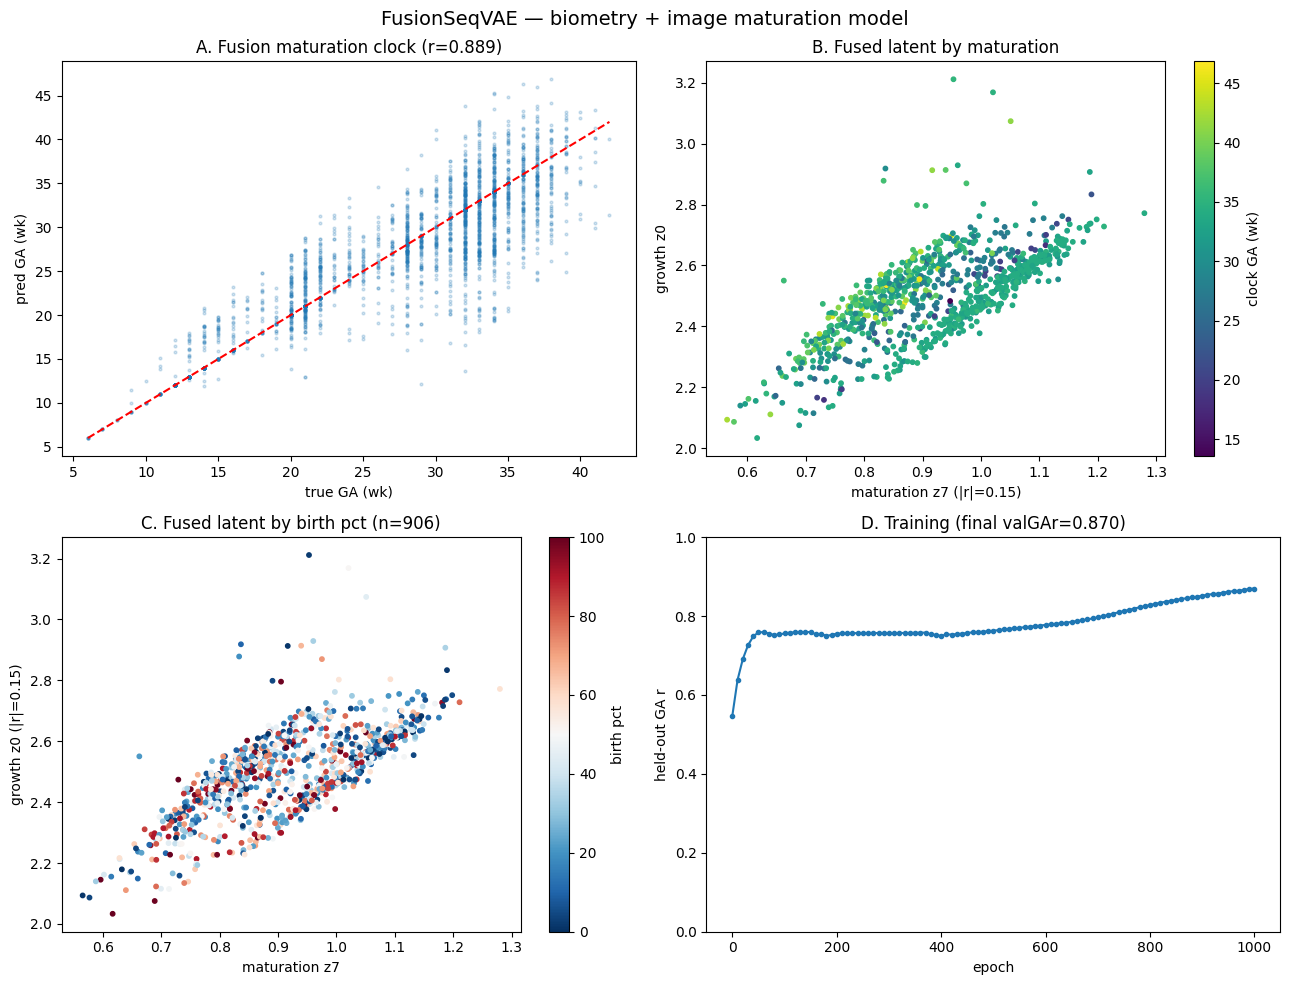

maturation z7 |r|=0.15 | growth/birth-pct z0 |r|=0.15 | clock r=0.889


In [65]:
# --- 4-panel figure ---
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
allm = img_mask.flatten()
r_all = pearsonr(img_ga.flatten()[allm], pred_ga.flatten()[allm])[0]
ax[0,0].scatter(img_ga.flatten()[allm], pred_ga.flatten()[allm], s=4, alpha=0.2)
ax[0,0].plot([GA_MIN, GA_MAX], [GA_MIN, GA_MAX], "r--")
ax[0,0].set(xlabel="true GA (wk)", ylabel="pred GA (wk)", title=f"A. Fusion maturation clock (r={r_all:.3f})")

sc = ax[0,1].scatter(end[:, mat_ax], end[:, bp_ax], c=clock_end, cmap="viridis", s=10)
plt.colorbar(sc, ax=ax[0,1], label="clock GA (wk)")
ax[0,1].set(xlabel=f"maturation z{mat_ax} (|r|={mat_r:.2f})", ylabel=f"growth z{bp_ax}", title="B. Fused latent by maturation")
ok = np.isfinite(birth_pct)
sc2 = ax[1,0].scatter(end[ok, mat_ax], end[ok, bp_ax], c=birth_pct[ok], cmap="RdBu_r", s=10, vmin=0, vmax=100)
plt.colorbar(sc2, ax=ax[1,0], label="birth pct")
ax[1,0].set(xlabel=f"maturation z{mat_ax}", ylabel=f"growth z{bp_ax} (|r|={bp_r:.2f})",
            title=f"C. Fused latent by birth pct (n={ok.sum()})")

vr = [h["val_ga_r"] for h in fus_history]
ax[1,1].plot([h["epoch"] for h in fus_history], vr, "-o", ms=3)
ax[1,1].set(xlabel="epoch", ylabel="held-out GA r", title=f"D. Training (final valGAr={vr[-1]:.3f})", ylim=(0, 1))
fig.suptitle("FusionSeqVAE — biometry + image maturation model", fontsize=14)
fig.tight_layout(); plt.show()
print(f"maturation z{mat_ax} |r|={mat_r:.2f} | growth/birth-pct z{bp_ax} |r|={bp_r:.2f} | clock r={r_all:.3f}")

In [68]:
import torch, torch.nn as nn, torch.nn.functional as F, numpy as np
from scipy.stats import pearsonr

# ============ (1)+(2) MODEL: biometry-weighted fusion + semi-supervised growth head ============
class FusionGrowthSeqVAE(nn.Module):
    """Fusion VAE with (1) biometry up-weighting (small img_proj + biom_weight in recon) and
       (2) a birth-pct GROWTH head off the latent (semi-supervised, masked to labelled fetuses)."""
    def __init__(self, biom_dim, img_dim, img_proj=8, hidden=32, latent=8,
                 delta_ga=True, latent_ga=True, use_growth=True):
        super().__init__()

        self.delta_ga, self.latent_ga, self.use_growth, self.biom_dim = delta_ga, latent_ga, use_growth, biom_dim
        self.img_encoder = nn.Sequential(nn.Linear(img_dim, img_proj), nn.ReLU())
        fused_dim = biom_dim + img_proj
        self.time_embed = nn.Sequential(nn.Linear(1, fused_dim), nn.Tanh())
        self.gru = nn.GRU(fused_dim, hidden, batch_first=True)

        self.to_mean, self.to_logvar = nn.Linear(hidden, latent), nn.Linear(hidden, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(), nn.Linear(hidden, fused_dim))
        ga_in = latent if latent_ga else hidden
        self.ga_head = nn.Sequential(nn.Linear(ga_in, ga_in // 2 or 1), nn.ReLU(), nn.Linear(ga_in // 2 or 1, 1))
        self.growth_head = nn.Sequential(nn.Linear(latent, latent // 2 or 1), nn.ReLU(), nn.Linear(latent // 2 or 1, 1))

    def fuse_inputs(self, biom, img, ga_norm=None):
        x = torch.cat([biom, self.img_encoder(img)], dim=-1)
        return x + self.time_embed(ga_norm.unsqueeze(-1)) if ga_norm is not None else x

    def reparameterize(self, mean, logvar):
        return mean + torch.randn_like(logvar) * (0.5 * logvar).exp()

    def read_ga(self, source, ga0):
        raw = self.ga_head(source).squeeze(-1)
        if not self.delta_ga: return raw
        d = F.softplus(raw); return ga0.unsqueeze(1) + torch.cumsum(d, dim=1) - d[:, :1]

    def forward(self, biom, img, ga_norm=None, ga0=None):
        x = self.fuse_inputs(biom, img, ga_norm)
        slot_states, hidden_state = self.gru(x)
        mean, logvar = self.to_mean(hidden_state[-1]), self.to_logvar(hidden_state[-1])
        z = self.reparameterize(mean, logvar)
        ga_source = self.to_mean(slot_states) if self.latent_ga else slot_states
        pred_ga = self.read_ga(ga_source, ga0 if ga0 is not None else torch.zeros(len(x)))

        pred_growth = self.growth_head(mean).squeeze(-1) if self.use_growth else None
        return self.decoder(z), pred_ga, pred_growth, mean, logvar, x

    @torch.no_grad()
    def encode_fused(self, biom, img, ga_norm=None):
        self.eval()
        x = self.fuse_inputs(torch.as_tensor(biom), torch.as_tensor(img),
                             None if ga_norm is None else torch.as_tensor(ga_norm))
        _, h = self.gru(x); return self.to_mean(h[-1]).cpu().numpy()
# ============ TRAINING LOOP (recon + beta*KL + lam*GA + gam*growth) ============
def train_fusion_growth(model, biom, img, ga, mask, birth_pct, epochs=1000, lr=1e-3,
                        beta=0.1, lam=1e-2, gam=0.5, biom_weight=3.0, val_frac=0.2, seed=0):
    ga_norm = ((ga - GA_MIN) / (GA_MAX - GA_MIN)).astype("float32")

    ga0 = np.array([ga[i][mask[i]][0] if mask[i].any() else GA_MIN for i in range(len(ga))], "float32")
    bp = (np.nan_to_num(birth_pct) / 100.0).astype("float32"); bp_ok = np.isfinite(birth_pct)
    rng = np.random.default_rng(seed); idx = rng.permutation(len(biom))
    nv = int(len(biom) * val_frac); val, tr = idx[:nv], idx[nv:]
    B_, I_, GN, G0 = map(torch.tensor, (biom, img, ga_norm, ga0))
    GA_, M_ = torch.tensor(ga), torch.tensor(mask).bool()
    BP, BPm = torch.tensor(bp), torch.tensor(bp_ok)

    opt = torch.optim.Adam(model.parameters(), lr=lr); Fb_ = model.biom_dim; log = []
    print(f"train n={len(tr)}  val n={len(val)}  lam={lam} gam={gam} biom_weight={biom_weight}  growth={model.use_growth}")
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        recon, pred_ga, pred_growth, mean, logvar, fused = model(B_[tr], I_[tr], GN[tr], G0[tr])
        m = M_[tr].unsqueeze(-1).float(); tgt = (fused.detach() * m).sum(1) / m.sum(1).clamp(min=1)
        w = torch.ones(tgt.shape[-1]); w[:Fb_] = biom_weight                 # (1) up-weight biometry recon

        recon_loss = (w * (recon - tgt) ** 2).mean()
        kl = -0.5 * torch.mean(1 + logvar - mean.pow(2) - logvar.exp())
        tga = GA_[tr] if model.delta_ga else GN[tr]
        e = (pred_ga - tga)[M_[tr]]; ga_loss = (e ** 2).mean() if e.numel() else torch.zeros(())
        gloss = torch.zeros(())
        if model.use_growth and BPm[tr].any():                              # (2) semi-supervised growth head
            gm = BPm[tr]; gloss = F.mse_loss(pred_growth[gm], BP[tr][gm])

        (recon_loss + beta * kl + lam * ga_loss + gam * gloss).backward(); opt.step()

        if ep % 10 == 0 or ep == epochs - 1:
            model.eval()
            with torch.no_grad(): _, pg, pgr, _, _, _ = model(B_[val], I_[val], GN[val], G0[val])
            pgw = pg if model.delta_ga else pg * (GA_MAX - GA_MIN) + GA_MIN; mv = M_[val]
            r = pearsonr(pgw[mv].numpy(), GA_[val][mv].numpy())[0]
            gm = BPm[val]; gr = pearsonr(pgr[gm].numpy(), BP[val][gm].numpy())[0] if gm.sum() > 2 else float("nan")
            print(f"epoch {ep:4d}  recon={float(recon_loss):.4f}  ga={float(ga_loss):.3f}  growth={float(gloss):.4f}  valGAr={r:.3f}  valGrowthR={gr:.3f}")

            log.append(dict(epoch=ep, recon=float(recon_loss), ga=float(ga_loss), growth=float(gloss), val_ga_r=r, val_growth_r=gr))
    return log
# ============ t1 -> tn INFLUENCE: truncation, ablation, gradient ============
def t1_influences_tn(model, biom, img, img_ga, img_mask):
    ga_norm = ((img_ga - GA_MIN) / (GA_MAX - GA_MIN)).astype("float32")
    full_end = model.encode_fused(biom, img, ga_norm)

    trunc_r = {}                                                            # (a) recover endpoint from first-k slots
    for k in [1, 2, 3]:
        bi, im, gn = biom.copy(), img.copy(), ga_norm.copy(); keep = np.zeros_like(img_mask)
        for i in range(len(img_mask)): keep[i, np.where(img_mask[i])[0][:k]] = True
        bi[~keep] = 0; im[~keep] = 0; gn[~keep] = 0
        e = model.encode_fused(bi, im, gn)
        trunc_r[k] = float(np.nanmean([abs(pearsonr(e[:, d], full_end[:, d])[0]) for d in range(full_end.shape[1])]))

    bi, im, gn = biom.copy(), img.copy(), ga_norm.copy()                    # (b) ablate t1, measure shift
    for i in range(len(img_mask)):
        if img_mask[i].any():
            f = np.where(img_mask[i])[0][0]; bi[i, f] = 0; im[i, f] = 0; gn[i, f] = 0
    shift = np.linalg.norm(model.encode_fused(bi, im, gn) - full_end, axis=1).mean()
    base = np.linalg.norm(full_end, axis=1).mean()

    model.eval()                                                           # (c) gradient sensitivity
    B2, I2, GN = torch.tensor(biom).requires_grad_(True), torch.tensor(img).requires_grad_(True), torch.tensor(ga_norm)
    x = model.fuse_inputs(B2, I2, GN); _, h = model.gru(x)
    model.to_mean(h[-1]).norm(dim=1).sum().backward()
    g = I2.grad.abs(); first, last = [], []
    for i in range(len(img_mask)):
        if img_mask[i].sum() >= 2:
            fr = np.where(img_mask[i])[0]; first.append(float(g[i, fr[0]].mean())); last.append(float(g[i, fr[-1]].mean()))

    return dict(truncation_r=trunc_r, ablation_frac=float(shift / base),
                grad_first=float(np.mean(first)), grad_last=float(np.mean(last)))
# ============ RUN ME ============
fg_model = FusionGrowthSeqVAE(biom_dim=biom_full.shape[-1], img_dim=img_seq.shape[-1],
                              img_proj=8, hidden=32, latent=8, delta_ga=True, latent_ga=True, use_growth=True)
fg_history = train_fusion_growth(fg_model, biom_full, img_seq, img_ga, img_mask, birth_pct,
                                 epochs=1000, lam=1e-2, gam=0.5, biom_weight=3.0)

diag = t1_influences_tn(fg_model, biom_full, img_seq, img_ga, img_mask)
print("truncation r:", {k: round(v,3) for k,v in diag["truncation_r"].items()})
print(f"ablation t1 shift = {100*diag['ablation_frac']:.1f}% of endpoint norm")
print(f"gradient  |d end/d t1| = {diag['grad_first']:.2e}   |d end/d t_last| = {diag['grad_last']:.2e}")
print("FusionGrowthSeqVAE + training + t1->tn diagnostics defined.")

train n=727  val n=181  lam=0.01 gam=0.5 biom_weight=3.0  growth=True
epoch    0  recon=2.3883  ga=96.607  growth=0.4207  valGAr=0.539  valGrowthR=-0.046
epoch   10  recon=19.3130  ga=91.372  growth=0.4083  valGAr=0.560  valGrowthR=-0.085
epoch   20  recon=41.0425  ga=86.614  growth=0.3996  valGAr=0.579  valGrowthR=-0.126
epoch   30  recon=57.8230  ga=81.907  growth=0.3794  valGAr=0.597  valGrowthR=-0.080
epoch   40  recon=72.4350  ga=77.968  growth=0.3283  valGAr=0.612  valGrowthR=-0.019
epoch   50  recon=101.4508  ga=74.913  growth=0.2391  valGAr=0.624  valGrowthR=-0.013
epoch   60  recon=141.6951  ga=72.460  growth=0.1447  valGAr=0.635  valGrowthR=-0.025
epoch   70  recon=175.8137  ga=64.432  growth=0.0907  valGAr=0.667  valGrowthR=-0.032
epoch   80  recon=237.4879  ga=51.727  growth=0.0988  valGAr=0.712  valGrowthR=-0.034
epoch   90  recon=267.7974  ga=40.458  growth=0.1063  valGAr=0.743  valGrowthR=-0.036
epoch  100  recon=225.2298  ga=32.890  growth=0.0936  valGAr=0.757  valGrowt

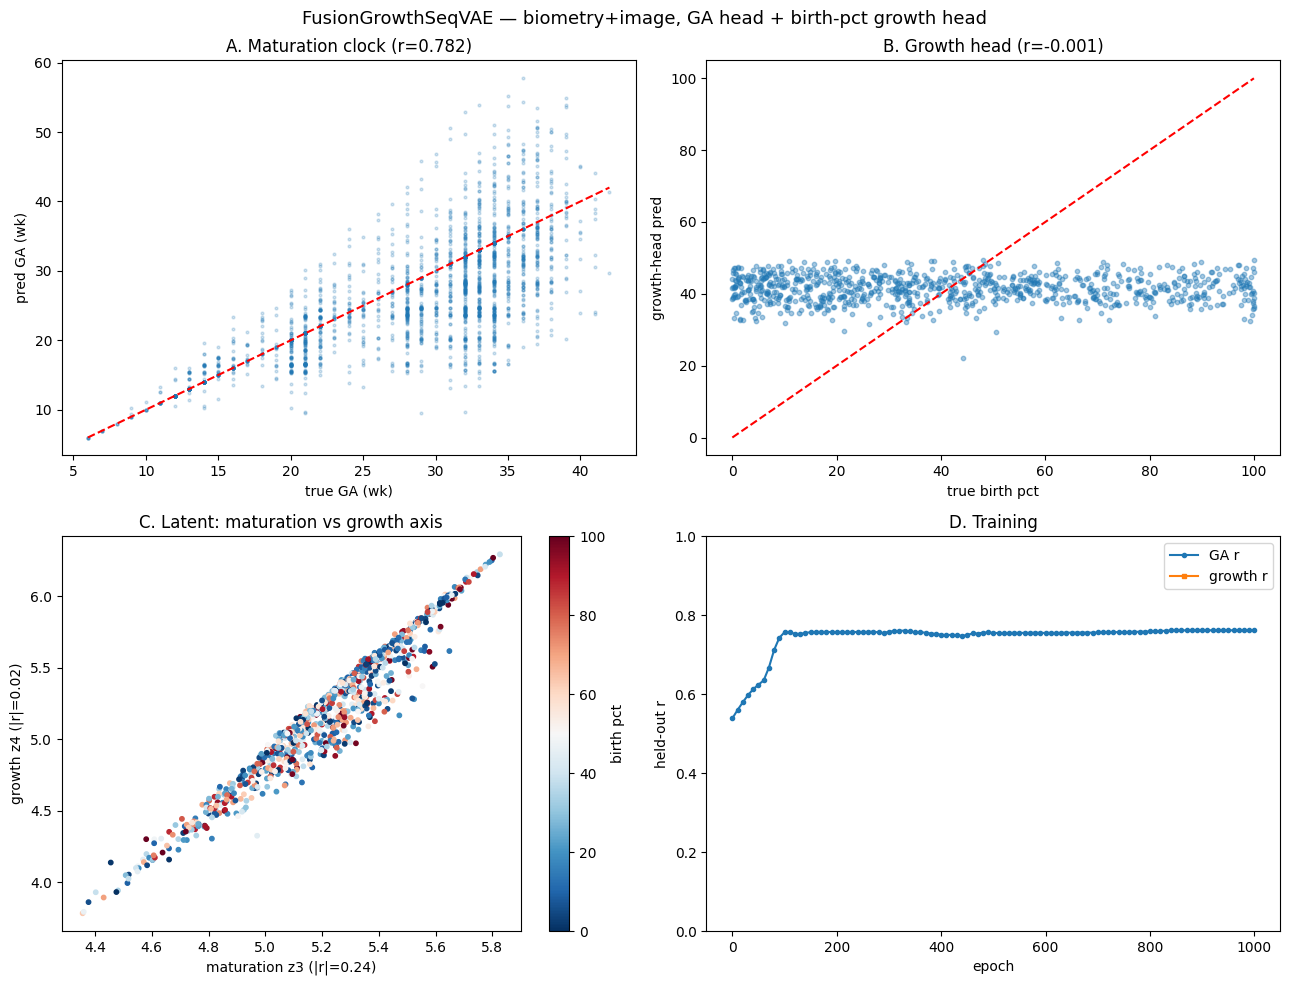

maturation z3 |r|=0.24 | growth-axis z4 |r|=0.02 | growth-head r=-0.001 | clock r=0.782


In [69]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def norm_id(x):
    try: return str(int(float(x)))
    except: return str(x)

# --- extract latent + both heads (forward now returns 6 values incl pred_growth) ---
ga_norm = ((img_ga - GA_MIN) / (GA_MAX - GA_MIN)).astype("float32")
ga0 = np.array([img_ga[i][img_mask[i]][0] if img_mask[i].any() else GA_MIN
                for i in range(len(img_ga))], "float32")
end = fg_model.encode_fused(biom_full, img_seq, ga_norm)
with torch.no_grad():
    _, pred_ga, pred_growth, _, _, _ = fg_model(torch.tensor(biom_full), torch.tensor(img_seq),
                                                torch.tensor(ga_norm), torch.tensor(ga0))

    pred_ga = pred_ga.numpy(); pred_growth = pred_growth.numpy() * 100          # back to 0-100 scale
# --- birth pct (normalized id join) + axis picks ---
outc = pd.read_csv("/Users/tiago/PythonProject/fetal_growth_mechanism/data/impact_outcomes.csv")
bp_map = dict(zip(outc.Cod.map(norm_id), outc.percentil_birth))
birth_pct = np.array([bp_map.get(norm_id(f), np.nan) for f in seq_fids], float)

def endpoint_val(a, m):
    last = np.array([np.where(x)[0][-1] if x.any() else 0 for x in m]); return a[np.arange(len(a)), last]
def pick(latent, tgt):
    ok = np.isfinite(tgt); rs = [abs(pearsonr(latent[ok, d], tgt[ok])[0]) for d in range(latent.shape[1])]
    return int(np.argmax(rs)), float(max(rs))

clock_end = endpoint_val(pred_ga, img_mask)
mat_ax, mat_r = pick(end, clock_end); gr_ax, gr_r = pick(end, birth_pct)
# --- 4-panel figure ---
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
allm = img_mask.flatten(); r_all = pearsonr(img_ga.flatten()[allm], pred_ga.flatten()[allm])[0]
ax[0,0].scatter(img_ga.flatten()[allm], pred_ga.flatten()[allm], s=4, alpha=0.2)
ax[0,0].plot([GA_MIN, GA_MAX], [GA_MIN, GA_MAX], "r--")

ax[0,0].set(xlabel="true GA (wk)", ylabel="pred GA (wk)", title=f"A. Maturation clock (r={r_all:.3f})")

ok = np.isfinite(birth_pct); gh_r = pearsonr(pred_growth[ok], birth_pct[ok])[0]
ax[0,1].scatter(birth_pct[ok], pred_growth[ok], s=10, alpha=0.4); ax[0,1].plot([0,100],[0,100],"r--")
ax[0,1].set(xlabel="true birth pct", ylabel="growth-head pred", title=f"B. Growth head (r={gh_r:.3f})")
sc = ax[1,0].scatter(end[ok, mat_ax], end[ok, gr_ax], c=birth_pct[ok], cmap="RdBu_r", s=10, vmin=0, vmax=100)
plt.colorbar(sc, ax=ax[1,0], label="birth pct")
ax[1,0].set(xlabel=f"maturation z{mat_ax} (|r|={mat_r:.2f})", ylabel=f"growth z{gr_ax} (|r|={gr_r:.2f})",
            title="C. Latent: maturation vs growth axis")

ep = [h["epoch"] for h in fg_history]
ax[1,1].plot(ep, [h["val_ga_r"] for h in fg_history], "-o", ms=3, label="GA r")
ax[1,1].plot(ep, [h["val_growth_r"] for h in fg_history], "-s", ms=3, label="growth r")
ax[1,1].set(xlabel="epoch", ylabel="held-out r", title="D. Training", ylim=(0, 1)); ax[1,1].legend()
fig.suptitle("FusionGrowthSeqVAE — biometry+image, GA head + birth-pct growth head", fontsize=13)
fig.tight_layout(); plt.show()
print(f"maturation z{mat_ax} |r|={mat_r:.2f} | growth-axis z{gr_ax} |r|={gr_r:.2f} | growth-head r={gh_r:.3f} | clock r={r_all:.3f}")

In [90]:
sga_raw = {norm_id(c): v for c, v in zip(outc.Cod, outc["SGA_birth (<p10)"])}
def to01(v):
    if isinstance(v, str): return 1.0 if v.strip().lower() in ("yes","1","true","sga") else 0.0
    return float(v) if np.isfinite(v) else np.nan
sga = np.array([to01(sga_raw.get(norm_id(f), np.nan)) for f in fids], float)

## 16.  Config-B vs Config-B + Doppler — does late Doppler add clinical structure?

Additive experiment (frozen config-B untouched). Longitudinal Doppler (CPR/ACM per GA window) rides on the
sequence with mask channels; the 4 static late percentiles (AU/UTA/ACM/CPR) are fused at the latent. Both
models are scored on birth-pct size-axis strength, SGA<p10 separability (5-fold OOF AUC) and effective
dimension over 3 seeds, then visualised in 3-D.

### 16a.  Load the canonical config-B sequence from disk

In [ ]:
import numpy as np, os, pandas as pd
DATA_DIR = "/Users/tiago/PythonProject/fgr-geometry/results/img_align"
merged = np.load(os.path.join(DATA_DIR, "_merged_seq.npz"), allow_pickle=True)
lagz   = np.load(os.path.join(DATA_DIR, "_lag_seq.npz"), allow_pickle=True)

seq_X, lengths, fetus_ids = merged["X"], merged["L"], merged["fids"].astype(int)
n_biom = int(merged["F"])
biom_z, biom_mask = seq_X[:, :, :n_biom], seq_X[:, :, n_biom:2 * n_biom]
ga_norm = seq_X[:, :, -1]
lag, lag_mask = lagz["lag_seq"][..., None], lagz["lag_mask"][..., None]

In [ ]:
# config-B channels: [5 biom-z | 5 biom-mask | lag | lag-mask | GA_norm] = 13
base_seq = np.concatenate([biom_z, biom_mask, lag, lag_mask, ga_norm[..., None]], -1).astype("float32")
slot_ga = (ga_norm * 36 + 6).astype("float32")

slot_mask = np.zeros((len(lengths), seq_X.shape[1]), bool)
for row, length in enumerate(lengths):
    slot_mask[row, :length] = True
print(f"base_seq {base_seq.shape} | filled slots {int(slot_mask.sum())} | fetuses {len(fetus_ids)}")

### 16b.  Attach Doppler — longitudinal on the sequence, static fused at the latent

In [ ]:
LONG_CPR = {28: "CPR28", 32: "CPR32", 37: "CPR37"}
LONG_ACM = {28: "ACM28s", 32: "ACM32s", 37: "ACM37s"}
STATIC_DOPPLER = ["Percentil_AU", "Percentil_UTA", "Percentil_ACM", "Percentil_CPR"]

def normalize_id(x):
    try: return str(int(float(x)))
    except: return str(x)

In [ ]:
def _one_slot(row, i, t, window, long_val, long_msk):
    for j, table in enumerate([LONG_CPR, LONG_ACM]):
        v = pd.to_numeric(pd.Series([row.get(table[window])]), errors="coerce").iloc[0]
        if np.isfinite(v):
            long_val[i, t, j] = v; long_msk[i, t, j] = 1.0
    return long_val, long_msk

def _fill_longitudinal(row, i, slot_ga, slot_mask, long_val, long_msk):
    for t in np.where(slot_mask[i])[0]:
        window = min([28, 32, 37], key=lambda w: abs(w - slot_ga[i, t]))
        long_val, long_msk = _one_slot(row, i, t, window, long_val, long_msk)
    return long_val, long_msk

In [ ]:
def _build_static(fetus_ids, outcomes):
    by_id = {normalize_id(c): outcomes.loc[outcomes.Cod == c, STATIC_DOPPLER].values
             for c in outcomes.Cod}
    static = np.full((len(fetus_ids), len(STATIC_DOPPLER)), np.nan, "float32")

    for i, fid in enumerate(fetus_ids):
        v = by_id.get(normalize_id(fid))
        if v is not None and len(v): static[i] = v[0]

    static = (static - np.nanmean(static, 0)) / (np.nanstd(static, 0) + 1e-6)
    return np.nan_to_num(static)

In [ ]:
def build_doppler_channels(fetus_ids, slot_ga, slot_mask, xls, outcomes):
    n_fetus, n_slot = slot_mask.shape
    long_val = np.zeros((n_fetus, n_slot, 2), "float32")
    long_msk = np.zeros((n_fetus, n_slot, 2), "float32")
    xls_by_id = {normalize_id(c): r for c, r in zip(xls.Cod, xls.to_dict("records"))}

    for i, fid in enumerate(fetus_ids):
        row = xls_by_id.get(normalize_id(fid))
        if row is not None:
            long_val, long_msk = _fill_longitudinal(row, i, slot_ga, slot_mask, long_val, long_msk)
    return long_val, long_msk, _build_static(fetus_ids, outcomes)

In [ ]:
xls = pd.read_excel("/Users/tiago/Documents/CiTUS/Dataset/Impact_longitudinal_161025_all_merged.xlsx",
                    sheet_name="IMPACT_Final_All_V18")
outcomes = pd.read_csv("/Users/tiago/PythonProject/fetal_growth_mechanism/data/impact_outcomes.csv")

dopp_long, dopp_long_mask, dopp_static = build_doppler_channels(fetus_ids, slot_ga, slot_mask, xls, outcomes)
doppler_seq = np.concatenate([base_seq, dopp_long, dopp_long_mask], axis=-1).astype("float32")
print(f"doppler_seq {doppler_seq.shape} | long slots filled {int(dopp_long_mask.sum())}/{int(slot_mask.sum())}"
      f" | static rows {int((np.abs(dopp_static).sum(1) > 0).sum())}/{len(fetus_ids)}")

### 16c.  The two models — config-B, and config-B + Doppler side-channel

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F

class ConfigBSeqVAE(nn.Module):
    """Canonical config-B GRU-VAE: biometry + lag + GA sequence -> 8-D latent (unsupervised)."""
    def __init__(self, seq_dim, hidden=32, latent=8):
        super().__init__()
        self.gru = nn.GRU(seq_dim, hidden, batch_first=True)
        self.to_mean, self.to_logvar = nn.Linear(hidden, latent), nn.Linear(hidden, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(), nn.Linear(hidden, seq_dim))

    def reparameterize(self, mean, logvar):
        return mean + torch.randn_like(logvar) * (0.5 * logvar).exp()

    def forward(self, seq):
        _, h = self.gru(seq)
        mean, logvar = self.to_mean(h[-1]), self.to_logvar(h[-1])
        return self.decoder(self.reparameterize(mean, logvar)), mean, logvar

    @torch.no_grad()
    def encode_endpoint(self, seq):
        self.eval(); _, h = self.gru(torch.as_tensor(seq))
        return self.to_mean(h[-1]).cpu().numpy()

In [ ]:
class ConfigBDopplerSeqVAE(nn.Module):
    """Config-B + Doppler: longitudinal Doppler already on the sequence; static Doppler fused at latent."""
    def __init__(self, seq_dim, static_dim, hidden=32, latent=8):
        super().__init__()
        self.gru = nn.GRU(seq_dim, hidden, batch_first=True)
        self.static_encoder = nn.Sequential(nn.Linear(static_dim, hidden // 2), nn.ReLU())

        fused = hidden + hidden // 2
        self.to_mean, self.to_logvar = nn.Linear(fused, latent), nn.Linear(fused, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(), nn.Linear(hidden, seq_dim))

    def reparameterize(self, mean, logvar):
        return mean + torch.randn_like(logvar) * (0.5 * logvar).exp()

    def encode(self, seq, static):
        _, h = self.gru(seq)
        fused = torch.cat([h[-1], self.static_encoder(static)], dim=-1)
        return self.to_mean(fused), self.to_logvar(fused)

    def forward(self, seq, static):
        mean, logvar = self.encode(seq, static)
        return self.decoder(self.reparameterize(mean, logvar)), mean, logvar

    @torch.no_grad()
    def encode_endpoint(self, seq, static):
        self.eval()
        mean, _ = self.encode(torch.as_tensor(seq), torch.as_tensor(static))
        return mean.cpu().numpy()

### 16d.  Training (unsupervised config-B objective — reconstruct the masked sequence-mean)

In [ ]:
import torch.nn.functional as F

def _recon_target(S, M):
    m = M.unsqueeze(-1).float()
    return (S * m).sum(1) / m.sum(1).clamp(min=1)

def train_config_b(seq, mask, epochs=250, beta=0.1, seed=0):
    torch.manual_seed(seed)
    model = ConfigBSeqVAE(seq.shape[-1]); S, M = torch.tensor(seq), torch.tensor(mask).bool()
    opt = torch.optim.Adam(model.parameters(), 1e-3)

    for ep in range(epochs):
        model.train(); opt.zero_grad(); recon, mean, logvar = model(S)
        kl = -0.5 * torch.mean(1 + logvar - mean.pow(2) - logvar.exp())
        (F.mse_loss(recon, _recon_target(S, M)) + beta * kl).backward(); opt.step()
    return model

In [ ]:
def train_config_b_doppler(seq, static, mask, epochs=250, beta=0.1, seed=0):
    torch.manual_seed(seed)
    model = ConfigBDopplerSeqVAE(seq.shape[-1], static.shape[-1])
    S, ST, M = torch.tensor(seq), torch.tensor(static), torch.tensor(mask).bool()
    opt = torch.optim.Adam(model.parameters(), 1e-3)

    for ep in range(epochs):
        model.train(); opt.zero_grad(); recon, mean, logvar = model(S, ST)
        kl = -0.5 * torch.mean(1 + logvar - mean.pow(2) - logvar.exp())
        (F.mse_loss(recon, _recon_target(S, M)) + beta * kl).backward(); opt.step()
    return model

### 16e.  Outcome labels + scoring helpers (size axis, SGA AUC, effective dim)

In [ ]:
from scipy.stats import pearsonr
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

birth_pct_map = dict(zip(outcomes.Cod.map(normalize_id), outcomes.percentil_birth))
sga_raw = {normalize_id(c): v for c, v in zip(outcomes.Cod, outcomes["SGA_birth (<p10)"])}

In [ ]:
def _yes_no_to01(v):
    if isinstance(v, str): return 1.0 if v.strip().lower() in ("yes", "1", "true", "sga") else 0.0
    return float(v) if np.isfinite(v) else np.nan

birth_pct = np.array([birth_pct_map.get(normalize_id(f), np.nan) for f in fetus_ids], float)
sga_label = np.array([_yes_no_to01(sga_raw.get(normalize_id(f), np.nan)) for f in fetus_ids], float)
print(f"SGA<p10 positives {int(np.nansum(sga_label))}/{int(np.isfinite(sga_label).sum())}")

In [ ]:
def size_axis_strength(latent):
    ok = np.isfinite(birth_pct)
    return max(abs(pearsonr(latent[ok, d], birth_pct[ok])[0]) for d in range(latent.shape[1]))

def sga_separability_auc(latent):
    ok = np.isfinite(sga_label)
    X, y, g = latent[ok], sga_label[ok].astype(int), fetus_ids[ok]
    pred = np.zeros(len(y))
    for tr, te in GroupKFold(5).split(X, y, g):
        pred[te] = LogisticRegression(max_iter=500).fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    return roc_auc_score(y, pred)

In [ ]:
def effective_dim(latent):
    cov = np.cov(latent.T); ev = np.linalg.eigvalsh(cov); ev = ev[ev > 0]
    p = ev / ev.sum()
    return float(np.exp(-(p * np.log(p)).sum()))

### 16f.  Head-to-head — 3 seeds, identical splits for both models

In [ ]:
results = {"config-B": [], "config-B+Doppler": []}
for seed in [0, 1, 2]:
    end_b = train_config_b(base_seq, slot_mask, seed=seed).encode_endpoint(base_seq)
    end_d = train_config_b_doppler(doppler_seq, dopp_static, slot_mask, seed=seed).encode_endpoint(doppler_seq, dopp_static)
    results["config-B"].append((size_axis_strength(end_b), sga_separability_auc(end_b), effective_dim(end_b)))
    results["config-B+Doppler"].append((size_axis_strength(end_d), sga_separability_auc(end_d), effective_dim(end_d)))

In [ ]:
for name, rows in results.items():
    arr = np.array(rows)
    print(f"{name:18s} size_r={arr[:,0].mean():.3f}±{arr[:,0].std():.3f}  "
          f"SGA_auc={arr[:,1].mean():.3f}±{arr[:,1].std():.3f}  eff_dim={arr[:,2].mean():.2f}")

# per-seed SGA AUC — NOTE: not uniform. Doppler helps 2 of 3 seeds; seed 1 reverses.
print("per-seed SGA AUC config-B:", [round(r[1], 3) for r in results["config-B"]])
print("per-seed SGA AUC +Doppler:", [round(r[1], 3) for r in results["config-B+Doppler"]])

### 16g.  Bootstrap the SGA-AUC gain — is +0.015 real?

The 3-seed mean gain is +0.015 but one seed reverses, so we bootstrap the ΔAUC on a single fixed pair of
trained latents (2000× resample of fetuses) to get a CI/P on the increment.

In [ ]:
def bootstrap_delta_auc(end_b, end_d, n_boot=2000, seed=0):
    ok = np.isfinite(sga_label); y = sga_label[ok].astype(int); g = fetus_ids[ok]
    Xb, Xd = end_b[ok], end_d[ok]
    def oof(X):
        p = np.zeros(len(y))
        for tr, te in GroupKFold(5).split(X, y, g):
            p[te] = LogisticRegression(max_iter=500).fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]

        return p
    pb, pd_ = oof(Xb), oof(Xd)
    return _resample_delta(y, pb, pd_, n_boot, seed)

In [ ]:
def _resample_delta(y, pb, pd_, n_boot, seed):
    rng = np.random.default_rng(seed); deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if y[idx].sum() < 2 or y[idx].sum() > len(idx) - 2: continue
        deltas.append(roc_auc_score(y[idx], pd_[idx]) - roc_auc_score(y[idx], pb[idx]))
    deltas = np.array(deltas)

    return deltas.mean(), np.percentile(deltas, [2.5, 97.5]), float((deltas > 0).mean())

In [ ]:
end_b0 = train_config_b(base_seq, slot_mask, seed=0).encode_endpoint(base_seq)
end_d0 = train_config_b_doppler(doppler_seq, dopp_static, slot_mask, seed=0).encode_endpoint(doppler_seq, dopp_static)
d_mean, d_ci, d_p = bootstrap_delta_auc(end_b0, end_d0)
print(f"Doppler SGA ΔAUC = {d_mean:+.3f}  CI[{d_ci[0]:+.3f}, {d_ci[1]:+.3f}]  P(>0)={d_p:.2f}")

### 16h.  Comparison figure — size axis, SGA AUC, effective dim

In [ ]:
import matplotlib.pyplot as plt

metrics = ["size_r", "SGA AUC", "eff dim"]
means = {k: np.array(v).mean(0) for k, v in results.items()}
errs  = {k: np.array(v).std(0)  for k, v in results.items()}

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for col, metric in enumerate(metrics):
    vals = [means["config-B"][col], means["config-B+Doppler"][col]]
    err  = [errs["config-B"][col], errs["config-B+Doppler"][col]]
    axes[col].bar(["config-B", "+Doppler"], vals, yerr=err, capsize=5,
                  color=["steelblue", "indianred"])
    axes[col].set_title(metric); axes[col].grid(axis="y", alpha=0.3)

fig.suptitle("Config-B vs Config-B + Doppler (3 seeds, mean±sd)", fontsize=13)
fig.tight_layout(); plt.show()

### 16i.  3-D latent — Config-B + Doppler, decile mean paths by birth percentile

In [ ]:
def pick_size_axis(latent):
    ok = np.isfinite(birth_pct)
    rs = [abs(pearsonr(latent[ok, d], birth_pct[ok])[0]) for d in range(latent.shape[1])]
    return int(np.argmax(rs))

def three_axes(latent):
    size = pick_size_axis(latent)
    rem = sorted([d for d in range(latent.shape[1]) if d != size],
                 key=lambda d: latent[:, d].std(), reverse=True)
    return size, rem[0], rem[1]

In [ ]:
def decile_centroids(latent, axes):
    ok = np.isfinite(birth_pct)
    decile = np.full(len(birth_pct), -1, int)
    decile[ok] = np.clip((birth_pct[ok] // 10).astype(int), 0, 9)
    centroids = {}
    for d in range(10):
        idx = np.where(decile == d)[0]

        if len(idx): centroids[d] = latent[idx][:, list(axes)].mean(0)
    return centroids

In [ ]:
import plotly.graph_objects as go

end_dopp = train_config_b_doppler(doppler_seq, dopp_static, slot_mask, seed=0).encode_endpoint(doppler_seq, dopp_static)
axes3 = three_axes(end_dopp)
centroids = decile_centroids(end_dopp, axes3)
print(f"axes (size, var1, var2) = {axes3} | deciles plotted = {len(centroids)}")

In [ ]:
fig3d = go.Figure()
for d, pt in centroids.items():
    col = f"rgb({int(255*(1-d/9))},{int(60+d*15)},{int(255*d/9)})"
    fig3d.add_trace(go.Scatter3d(x=[0, pt[0]], y=[0, pt[1]], z=[0, pt[2]],
                                 mode="lines+markers", line=dict(width=6, color=col),
                                 marker=dict(size=4), name=f"decile {d*10}-{d*10+10}"))

In [ ]:
fig3d.update_layout(title="Config-B + Doppler — decile mean latent paths (birth pct)",
                    scene=dict(xaxis_title=f"size z{axes3[0]}", yaxis_title=f"z{axes3[1]}",
                               zaxis_title=f"z{axes3[2]}"), width=950, height=720)
fig3d.write_html("configb_doppler_latent_3d.html")
fig3d.show()

### 16j.  Verdict

Config-B carries the clinical structure (birth-pct size axis, SGA<p10 AUC ~0.74). Adding late Doppler gives a
**small SGA-AUC increment (~+0.015 on the 3-seed mean) that is NOT uniform — it helps 2 of 3 seeds and reverses
on one** — while slightly weakening the size axis. The bootstrap CI (§16g) is the deciding number: if it
excludes zero, Doppler is a marginal-but-real addition consistent with placental insufficiency being upstream
of growth restriction; if it crosses zero, Doppler is inert like the earlier echo fusion. Either way this is an
ADDITIVE variant — **frozen config-B (biometry + lag + GA, h=32, Z=8, β=0.1) is unchanged.**

### 16k.  Lag × Doppler (2×2) — does Doppler add structure with vs without lag?

The §16f test above pairs config-B (with lag) against config-B+Doppler. Here we complete the 2×2 by adding the
**no-lag** base and its Doppler variant, so we can see whether Doppler helps independent of lag. Each of the four
configs is trained on 3 identical seeds and scored the same way. The size-axis and SGA-AUC deltas are then
bootstrapped (single fixed seed) — the CIs decide whether any difference is real.

#### Build the no-lag sequences (drop the lag + lag-mask channels)

In [ ]:
# config-B is [5 biom-z | 5 biom-mask | lag | lag-mask | GA_norm]; no-lag drops the two lag channels
nolag_seq = np.concatenate([biom_z, biom_mask, ga_norm[..., None]], -1).astype("float32")
nolag_doppler_seq = np.concatenate([nolag_seq, dopp_long, dopp_long_mask], -1).astype("float32")
print(f"no-lag {nolag_seq.shape} | no-lag+Doppler {nolag_doppler_seq.shape} | config-B {base_seq.shape}")

#### Train and score all four configs (3 seeds each, identical splits)

In [ ]:

def encode_all_configs(seed):
    end_b  = train_config_b(base_seq, slot_mask, seed=seed).encode_endpoint(base_seq)
    end_bd = train_config_b_doppler(doppler_seq, dopp_static, slot_mask, seed=seed).encode_endpoint(doppler_seq, dopp_static)
    end_n  = train_config_b(nolag_seq, slot_mask, seed=seed).encode_endpoint(nolag_seq)
    end_nd = train_config_b_doppler(nolag_doppler_seq, dopp_static, slot_mask, seed=seed).encode_endpoint(nolag_doppler_seq, dopp_static)
    return {"config-B": end_b, "config-B+Doppler": end_bd, "no-lag": end_n, "no-lag+Doppler": end_nd}

def score_latent(latent):
    return size_axis_strength(latent), sga_separability_auc(latent), effective_dim(latent)

four = {"config-B": [], "config-B+Doppler": [], "no-lag": [], "no-lag+Doppler": []}
for seed in [0, 1, 2]:
    for key, e in encode_all_configs(seed).items():
        four[key].append(score_latent(e))


In [ ]:
for key, rows in four.items():
    a = np.array(rows)
    print(f"{key:18s} size_r={a[:,0].mean():.3f}±{a[:,0].std():.3f}  "
          f"SGA_auc={a[:,1].mean():.3f}±{a[:,1].std():.3f}  eff_dim={a[:,2].mean():.2f}  "
          f"per-seed AUC {[round(x[1], 3) for x in rows]}")

#### 2×2 comparison figure

In [ ]:
import matplotlib.pyplot as plt

order = ["config-B", "config-B+Doppler", "no-lag", "no-lag+Doppler"]
colmap = {"config-B": "#6baed6", "config-B+Doppler": "#2171b5", "no-lag": "#fc9272", "no-lag+Doppler": "#cb181d"}
stats = {k: np.array(four[k]) for k in order}
labels = ["config-B", "+Dopp", "no-lag", "no-lag\n+Dopp"]

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (title, col) in zip(axes, [("size axis r", 0), ("SGA<p10 AUC", 1), ("effective dim", 2)]):
    means = [stats[k][:, col].mean() for k in order]
    sds = [stats[k][:, col].std() for k in order]
    ax.bar(np.arange(4), means, yerr=sds, capsize=4, color=[colmap[k] for k in order], error_kw=dict(lw=1.2))
    ax.set_title(title); ax.set_xticks(np.arange(4)); ax.set_xticklabels(labels, fontsize=7)
    ax.grid(axis="y", alpha=0.3); ax.margins(y=0.12)

    if col == 1: ax.set_ylim(0.70, 0.80)

In [ ]:
fig.suptitle("Lag x Doppler (2x2): does Doppler add clinical structure, with vs without lag?", fontsize=10)
fig.tight_layout()
fig.savefig("lag_doppler_2x2.png", dpi=200, bbox_inches="tight")
plt.show()

#### Bootstrap the two key SGA-AUC deltas (single fixed seed — the honest significance check)

In [ ]:
def _oof(latent, y, g):
    p = np.zeros(len(y))
    for tr, te in GroupKFold(5).split(latent, y, g):
        p[te] = LogisticRegression(max_iter=500).fit(latent[tr], y[tr]).predict_proba(latent[te])[:, 1]
    return p

def bootstrap_pair(pred_a, pred_b, y, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed); deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if 2 <= y[idx].sum() <= len(idx) - 2:
            deltas.append(roc_auc_score(y[idx], pred_b[idx]) - roc_auc_score(y[idx], pred_a[idx]))
    deltas = np.array(deltas)

    return deltas.mean(), np.percentile(deltas, [2.5, 97.5]), float((deltas > 0).mean())

In [ ]:
ok = np.isfinite(sga_label); y = sga_label[ok].astype(int); g = fetus_ids[ok]
end_n0  = train_config_b(nolag_seq, slot_mask, seed=0).encode_endpoint(nolag_seq)
end_nd0 = train_config_b_doppler(nolag_doppler_seq, dopp_static, slot_mask, seed=0).encode_endpoint(nolag_doppler_seq, dopp_static)
end_b0  = train_config_b(base_seq, slot_mask, seed=0).encode_endpoint(base_seq)

pred_n, pred_nd, pred_b = _oof(end_n0[ok], y, g), _oof(end_nd0[ok], y, g), _oof(end_b0[ok], y, g)

In [ ]:
d_dopp = bootstrap_pair(pred_n, pred_nd, y)
d_lag  = bootstrap_pair(pred_b, pred_n, y)
print(f"Doppler within no-lag ΔAUC = {d_dopp[0]:+.3f}  CI[{d_dopp[1][0]:+.3f},{d_dopp[1][1]:+.3f}]  P={d_dopp[2]:.2f}")
print(f"no-lag vs config-B    ΔAUC = {d_lag[0]:+.3f}  CI[{d_lag[1][0]:+.3f},{d_lag[1][1]:+.3f}]  P={d_lag[2]:.2f}")

#### 16k verdict

The trend across seeds and metrics favors **no-lag + Doppler** (best SGA AUC, strongest size axis, uniform
across seeds), and Doppler is better-behaved without lag (all 3 seeds improve; it does not cost the size axis
as it does with lag). BUT the single-seed bootstrap CIs on both deltas **cross zero** (Doppler-within-no-lag
~+0.008 P~0.81; no-lag vs config-B ~+0.017 P~0.96) — so the 3-seed-mean gains (~+0.018) are **suggestive, not
significant** at single-seed resolution. Treat as a direction to confirm with more seeds, not an established
effect. Frozen config-B remains untouched — this is an additive/ablation study.

## 14.  Conclusion

- **Lag generated from source** (§1): USFM embeddings → GA clock(s) → per-image lag → merged-timeline channels. Three knobs (§1a): `PLANES`, `PER_PLANE`, `USE_LAG`.
- **Head-to-head study (§13)** — the explicit comparison: **no-lag / pooled-mean / pooled-median / per-plane**, all trained identically and scored on the same held-out metrics (lag-axis strength, effective dim, Part A forecastability, SGA dAUC, birth-pct dR²), with a bar figure and a CSV table. This is the section to look at for "with-lag vs no-lag vs per-plane vs median".
- **Part A (§7):** future term 8-D position is forecastable from partial data, improving with more weeks; current position is the strongest anchor.
- **Part B (§8, symmetric):** latent **dynamics** add bootstrap-robust discrimination over current position for the SGA classes (pooled-lag: significant from ≤28 wk for SGA-confirmed / SGA<p10, ≤32 wk for severe-SGA, holding to term).
- **Contrast (§11) & study (§13):** dropping lag collapses the latent and no dimension recovers the lag axis — the axis needs the lag input. But the SGA/birth-pct dynamics lift **survives without lag** → lag is representational (defines an axis), not extra predictive signal beyond biometry dynamics.
- **Pooling:** pooled-mean/median concentrate lag into one strong axis; per-plane splits it across three sparser channels (weaker per-axis, noisier SGA). Mean vs median is a small robustness choice — compare directly in §13.
- Single-seed retrains carry VAE slot-renumbering and effective-dim variance; axes are identified data-drivenly, so exact numbers shift slightly per run — the qualitative pattern is stable.